# [분할 작업본 3/4] FFCell v80 (PART 번호 연속 정리판) — 규칙기반 분류기 개발 — 부품별 독립 판정부터 직렬 계층 구조 확정까지

- 범위: PART 10~14 (cell 254~395)
- 원본: `FFCell_integrated_notebook_v80_PART연속.ipynb` (PART 15~19 번호를 연속으로 재정리한 버전)

---


In [1]:
# ── [분할 파일 시작] 이전 파일(part9) 세션 복원 ─────────────────────────────
# 이 파일은 FFCell_integrated_notebook_v80(PART 번호 연속 정리판)을 작업용으로
# 4등분한 것 중 "규칙기반 분류기 개발" (PART 10~14) 부분이다. 아래 셀로 이전 파일 끝 시점
# 전체 상태를(함수·변수·df 전부) 그대로 복원한 뒤, 이어지는 셀부터 실행하면 된다.
from pathlib import Path
_CACHE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints')

from google.colab import drive
drive.mount('/content/drive')

try:
    import dill
except ImportError:
    !pip install dill --quiet
    import dill

# [수정] 이전 파일에서 쓰던 패키지가 새 런타임엔 없어서 세션 복원이 실패하는 문제 방지
# (scikit_posthocs는 1of4에서만 설치했는데, 새 런타임에서 이 파일을 단독으로 열면 없음)
try:
    import scikit_posthocs
except ImportError:
    !pip install scikit-posthocs --quiet

_session_path = _CACHE_DIR / 'part9_session.pkl'
if _session_path.exists():
    dill.load_session(str(_session_path))
    print(f"[세션 복원 완료] {_session_path} ← 이전 파일 상태를 그대로 이어받았습니다.")
else:
    print(f"[체크포인트 없음] {_session_path} 파일이 없습니다.")
    print("  → 이전 분할 파일을 먼저 끝까지 실행해서 체크포인트를 만들어두세요.")


Mounted at /content/drive
[세션 복원 완료] /content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints/part9_session.pkl ← 이전 파일 상태를 그대로 이어받았습니다.


In [2]:
# ── 한글 폰트 설정 (그래프 제목·범례 깨짐 방지) ──────────────────────────
# Colab은 새 런타임을 열 때마다 시스템 폰트가 초기화되므로, 파일을 열 때마다 다시 실행 필요.
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib as mpl
import matplotlib.font_manager as fm
fm.fontManager.__init__()
mpl.rc("font", family="NanumGothic")
mpl.rcParams["axes.unicode_minus"] = False
print("나눔고딕 설정 완료")


나눔고딕 설정 완료


---
# PART 10. 부품별 독립 판정 — Body1·Body2 신호로 "본 적 없는 조합" 우회하기 (v59 신규)

39장(v57)에서 확정된 GroupKFold 실패의 근본 원인은 데이터 구조 자체였다 — 세션1~4에는
`NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`이 **한 개도 없어서**, 이 조합을 통째로 배우는
지금 방식(4클래스 분류기 하나)으로는 원천적으로 예측이 불가능하다.

이번 PART에서 확인할 우회로: Nose(slot3) 판별에 썼던 것과 같은 원리를 Body1(slot1)·
Body2(slot2) 조립 구간에도 적용해서, **"이 조합을 본 적 있는가"가 아니라 "이 부품
하나가 있는가"를 독립적으로 판정**할 수 있다면, 한 번도 안 본 조합이라도 각 부품
판정을 조합해서 맞힐 수 있다.

이 PART는 v58까지의 커널 상태(`r03_peak_times`, `r03_peak_heights`, `slot_reference_time`,
`label_by_cycle`, `rank_biserial`, `X_s5`, `y_s5`, `X_final_v58`, `run_oof`,
`ladder_models`, `LABEL_ORDER` 등)를 그대로 이어서 쓴다.
---


## 46. Body1(slot1)·Body2(slot2) 힘 신호 추출

16장에서 이미 확정된 슬롯 기준 시각(`slot_reference_time`)과, 90장(16-2)에서 Tail(slot4)에
썼던 것과 똑같은 방식을 그대로 재사용한다 — 각 사이클의 R03 피크 목록에서 슬롯 기준 시각과
가장 가까운 피크를 찾아 그 힘을 가져온다.


In [3]:

# ── Body1(slot1)·Body2(slot2) 슬롯 힘 추출 (Tail 방식 재사용, 90장과 동일 로직) ──────
def slot_force_for_cycle(cid, target, tol=2):
    times = np.array(r03_peak_times.get(cid, []))
    heights = np.array(r03_peak_heights.get(cid, []))
    if len(times) == 0:
        return np.nan
    diffs = np.abs(times - target)
    if diffs.min() > tol:
        return np.nan
    return heights[diffs.argmin()]


cids_all = [c for c in r03_peak_times.index if not c.startswith('0_')]

body1_force = pd.Series({cid: slot_force_for_cycle(cid, slot_reference_time['slot1_t']) for cid in cids_all})
body2_force = pd.Series({cid: slot_force_for_cycle(cid, slot_reference_time['slot2_t']) for cid in cids_all})

body_force_df = pd.DataFrame({'body1_force': body1_force, 'body2_force': body2_force}).join(label_by_cycle).dropna(subset=['label'])
print(f'추출 완료: {len(body_force_df)}개 사이클')
print(f'\nslot1_t(Body1) 기준시각: {slot_reference_time["slot1_t"]:.1f}초')
print(f'slot2_t(Body2) 기준시각: {slot_reference_time["slot2_t"]:.1f}초')

print('\n[결측 확인] 슬롯 힘을 못 찾은 사이클 수:')
print(f'  body1_force 결측: {body_force_df["body1_force"].isna().sum()}개')
print(f'  body2_force 결측: {body_force_df["body2_force"].isna().sum()}개')


추출 완료: 320개 사이클

slot1_t(Body1) 기준시각: 65.8초
slot2_t(Body2) 기준시각: 78.8초

[결측 확인] 슬롯 힘을 못 찾은 사이클 수:
  body1_force 결측: 102개
  body2_force 결측: 123개


### 46-1. 클래스별 분포 — 그래프로 먼저

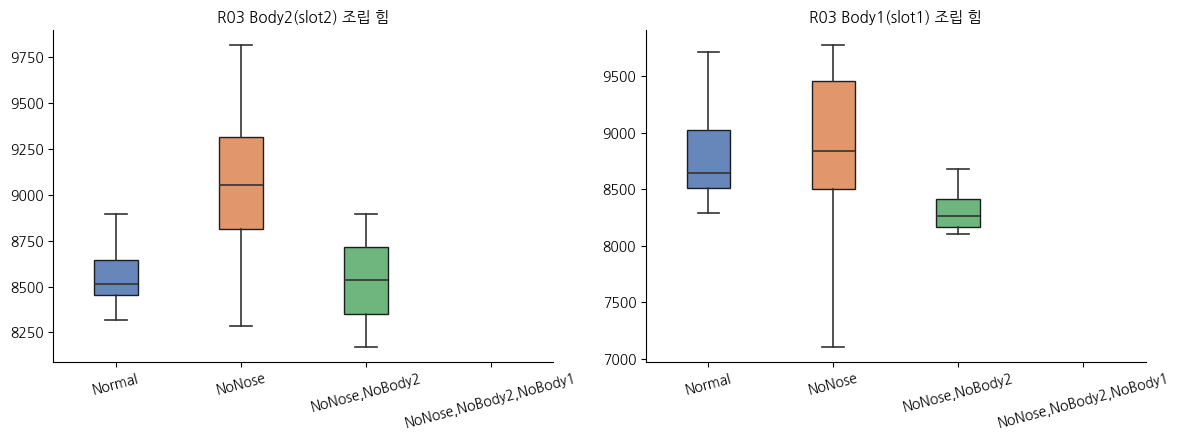

In [4]:

# ── Body1·Body2 힘 — 클래스별 박스플롯 ─────────────────────────────────────────
ORDER_V59 = ['Normal', 'NoNose', 'NoNose,NoBody2', 'NoNose,NoBody2,NoBody1']
COLORS_V59 = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, title in zip(axes, ['body2_force', 'body1_force'],
                            ['R03 Body2(slot2) 조립 힘', 'R03 Body1(slot1) 조립 힘']):
    data = [body_force_df.loc[body_force_df.label == l, col].dropna().values for l in ORDER_V59]
    bp = ax.boxplot(data, tick_labels=ORDER_V59, patch_artist=True, widths=0.35, showfliers=False)
    for patch, c in zip(bp['boxes'], COLORS_V59):
        patch.set_facecolor(c); patch.set_alpha(0.85)
    for element in ['whiskers', 'caps', 'medians']:
        for line in bp[element]:
            line.set_color('#333333'); line.set_linewidth(1.2)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## 47. 효과크기 비교 — Nose·Body2·Body1·Tail, 신호가 얼마나 뚜렷한가

핵심 질문: "Body1·Body2도 Nose(r=-0.87)만큼 뚜렷한 신호인가, 아니면 Tail(r=0.24~0.43,
가장 약했던 신호)에 더 가까운가?" 부품이 있는 그룹과 없는 그룹을 나눠서 효과크기를
직접 비교한다. (해당 부품이 없는 조합은 세션5에만 있으므로, "없는 쪽" 표본은 대부분
세션5에서 나온다 — 이건 세션1~4 자체에 그 조합이 없다는 39장 사실의 당연한 결과다.)


In [5]:

# ── Body2 유무 효과크기 (Body2 있음: Normal·NoNose / Body2 없음: NoBody2·전체결측) ────
body2_present = body_force_df[body_force_df.label.isin(['Normal', 'NoNose'])]['body2_force'].dropna()
body2_absent = body_force_df[body_force_df.label.isin(['NoNose,NoBody2', 'NoNose,NoBody2,NoBody1'])]['body2_force'].dropna()

u2, p2 = mannwhitneyu(body2_present, body2_absent, alternative='two-sided')
r2 = rank_biserial(u2, len(body2_present), len(body2_absent))
print(f'[Body2 유무] 있음(n={len(body2_present)}) 평균={body2_present.mean():.0f}  '
      f'없음(n={len(body2_absent)}) 평균={body2_absent.mean():.0f}')
print(f'  배율={body2_present.mean()/body2_absent.mean():.2f}배  p={p2:.6f}  효과크기(r)={r2:+.3f}')

# ── Body1 유무 효과크기 (Body1 있음: Normal·NoNose·NoBody2 / Body1 없음: 전체결측) ────
body1_present = body_force_df[body_force_df.label.isin(['Normal', 'NoNose', 'NoNose,NoBody2'])]['body1_force'].dropna()
body1_absent = body_force_df[body_force_df.label == 'NoNose,NoBody2,NoBody1']['body1_force'].dropna()

u1, p1 = mannwhitneyu(body1_present, body1_absent, alternative='two-sided')
r1 = rank_biserial(u1, len(body1_present), len(body1_absent))
print(f'\n[Body1 유무] 있음(n={len(body1_present)}) 평균={body1_present.mean():.0f}  '
      f'없음(n={len(body1_absent)}) 평균={body1_absent.mean():.0f}')
print(f'  배율={body1_present.mean()/body1_absent.mean():.2f}배  p={p1:.6f}  효과크기(r)={r1:+.3f}')

print('\n=== 4개 부품 신호 세기 순위 (참고: Nose·Tail은 이전 장에서 확정된 값) ===')
signal_rank = pd.DataFrame([
    {'부품': 'Nose(slot3)', '효과크기(r)': -0.87, '출처': '17장'},
    {'부품': 'Body2(slot2)', '효과크기(r)': r2, '출처': '47장(신규)'},
    {'부품': 'Body1(slot1)', '효과크기(r)': r1, '출처': '47장(신규)'},
    {'부품': 'Tail(slot4)', '효과크기(r)': '0.24~0.43', '출처': '16-2장'},
]).assign(**{'|효과크기|': lambda d: d['효과크기(r)'].apply(lambda v: abs(v) if isinstance(v, float) else np.nan)})
signal_rank


[Body2 유무] 있음(n=195) 평균=8684  없음(n=2) 평균=8534
  배율=1.02배  p=0.613645  효과크기(r)=-0.210

[Body1 유무] 있음(n=218) 평균=8667  없음(n=0) 평균=nan
  배율=nan배  p=nan  효과크기(r)=+nan

=== 4개 부품 신호 세기 순위 (참고: Nose·Tail은 이전 장에서 확정된 값) ===


/tmp/ipykernel_633/1595832219.py:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u1, p1 = mannwhitneyu(body1_present, body1_absent, alternative='two-sided')


,부품,효과크기(r),출처,|효과크기|
0,Nose(slot3),-0.87,17장,0.870000
1,Body2(slot2),-0.210256,47장(신규),0.210256
2,Body1(slot1),NaN,47장(신규),NaN
3,Tail(slot4),0.24~0.43,16-2장,NaN


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| Body2·Body1 효과크기가 \|r\|>0.7로 Nose에 가까움 | 부품별 독립 판정이 유망함 — 48장의 규칙 기반 분류로 이어갈 가치가 있음 |
| Body2·Body1 효과크기가 \|r\|<0.4로 Tail에 가까움 | 이 우회로는 기대만큼 강하지 않음 — 조립 구간 신호가 분해 부품에 따라 세기가 다르다는 뜻 (Body1·Tail이 조립 순서상 더 일찍/늦게 눌리는 힘이라 신호가 약할 수 있음, 4-2절에서 이미 암시된 패턴) |


## 48. 부품별 독립 판정 규칙 — 계층적(sequential) 임계값

라벨 구조 자체가 계층적이다(조립 Body1→Body2→Nose, 분해 Nose→Body2→Body1 — 정확히
역순). 그래서 규칙도 계층적으로 만든다: **Nose가 있으면 Normal, 없으면 Body2를 보고,
Body2도 없으면 Body1을 본다.** 각 단계 임계값은 R03_NOSE_THRESH와 같은 방식(두 그룹
중앙값의 평균)으로 잡는다.


In [6]:

# ── 계층적 임계값 계산 (R03_NOSE_THRESH와 동일한 방식) ────────────────────────────
BODY2_THRESH = (body2_present.median() + body2_absent.median()) / 2
BODY1_THRESH = (body1_present.median() + body1_absent.median()) / 2

print(f'R03_NOSE_THRESH (기존, 17장) = {R03_NOSE_THRESH:.1f}')
print(f'BODY2_THRESH (신규)          = {BODY2_THRESH:.1f}')
print(f'BODY1_THRESH (신규)          = {BODY1_THRESH:.1f}')


def rule_based_predict(row):
    '''row에 r03_nose_peak, body2_force, body1_force가 있어야 한다.
    계층적 판정: Nose 있음 -> Normal / Nose 없음+Body2 있음 -> NoNose /
    Body2도 없음+Body1 있음 -> NoNose,NoBody2 / Body1도 없음 -> 전체결측
    '''
    nose_present = (row['r03_nose_peak'] >= R03_NOSE_THRESH) if pd.notna(row['r03_nose_peak']) else False
    if nose_present:
        return 'Normal'
    body2_present_flag = pd.notna(row['body2_force']) and (row['body2_force'] >= BODY2_THRESH)
    if body2_present_flag:
        return 'NoNose'
    body1_present_flag = pd.notna(row['body1_force']) and (row['body1_force'] >= BODY1_THRESH)
    if body1_present_flag:
        return 'NoNose,NoBody2'
    return 'NoNose,NoBody2,NoBody1'


rule_input = nose_sig_df[['r03_nose_peak']].join(body_force_df[['body2_force', 'body1_force', 'label']], how='inner')
rule_input['rule_pred'] = rule_input.apply(rule_based_predict, axis=1)

acc_rule_all = (rule_input['rule_pred'] == rule_input['label']).mean()
print(f'\n규칙 기반 예측 — 전체 데이터({len(rule_input)}개) 정확도: {acc_rule_all:.3f}')
print(pd.crosstab(rule_input['label'], rule_input['rule_pred'], rownames=['실제'], colnames=['예측']))


R03_NOSE_THRESH (기존, 17장) = 3110.5
BODY2_THRESH (신규)          = 8538.5
BODY1_THRESH (신규)          = nan

규칙 기반 예측 — 전체 데이터(320개) 정확도: 0.787
예측                      NoNose  NoNose,NoBody2,NoBody1  Normal
실제                                                            
NoNose                      43                      12       4
NoNose,NoBody2               1                      49       1
NoNose,NoBody2,NoBody1       0                      54       0
Normal                       0                       1     155


**주의**: 이 정확도는 임계값을 정할 때 이미 전체 데이터의 중앙값을 썼기 때문에,
"학습에 안 쓴 데이터로 검증"한 게 아니다 — 49장에서 진짜 검증(임계값을 앞부분에서만
잡고 뒷부분에 적용)을 한다. 여기서는 "규칙 자체가 논리적으로 말이 되는지"만 먼저 확인한다.


## 49. 세션5 내부 시간분할 검증 — 규칙기반 vs 기존 ML 분류기

`NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`은 세션5에만 있어서 GroupKFold(세션 간 분리)로는
검증할 방법이 없다 — 애초에 다른 세션에 비교 대상이 없다. 그래서 **세션5 내부를 시간
순으로 반 나눠서, 앞부분에서 규칙(임계값)을 잡고 뒷부분에 적용**하는 방식으로 "진짜
시간 일반화"를 확인한다. 같은 방식으로 ML 분류기(RF·로지스틱)도 앞부분만으로 학습시켜
비교한다.


In [7]:

# ── 세션5를 시간순으로 반 나눠서 규칙기반 vs ML 비교 ─────────────────────────────
s5_order = sorted(X_s5.index, key=lambda c: int(c.split('_')[1]))
half = len(s5_order) // 2
early_idx, late_idx = s5_order[:half], s5_order[half:]

print(f'세션5 앞부분(임계값/학습용): {len(early_idx)}개 / 뒷부분(검증용): {len(late_idx)}개')
print('\n앞부분 클래스 분포:')
print(y_s5.loc[early_idx].value_counts())
print('\n뒷부분 클래스 분포:')
print(y_s5.loc[late_idx].value_counts())

# 규칙기반: 앞부분으로 임계값 재계산
def recalc_thresh(force_series, present_labels, absent_labels, label_map):
    present = force_series[label_map.isin(present_labels)].dropna()
    absent = force_series[label_map.isin(absent_labels)].dropna()
    if len(present) == 0 or len(absent) == 0:
        return np.nan
    return (present.median() + absent.median()) / 2

early_label = y_s5.loc[early_idx]

nose_thresh_early = recalc_thresh(
    nose_sig_df.loc[early_idx, 'r03_nose_peak'], ['Normal'], ['NoNose'], early_label)
body2_thresh_early = recalc_thresh(
    body_force_df.loc[body_force_df.index.intersection(early_idx), 'body2_force'],
    ['Normal', 'NoNose'], ['NoNose,NoBody2', 'NoNose,NoBody2,NoBody1'], early_label)
body1_thresh_early = recalc_thresh(
    body_force_df.loc[body_force_df.index.intersection(early_idx), 'body1_force'],
    ['Normal', 'NoNose', 'NoNose,NoBody2'], ['NoNose,NoBody2,NoBody1'], early_label)

print(f'\n[앞부분만으로 다시 잡은 임계값] Nose={nose_thresh_early:.1f}  '
      f'Body2={body2_thresh_early:.1f}  Body1={body1_thresh_early:.1f}')


def rule_predict_v2(row, nose_t, body2_t, body1_t):
    if pd.notna(row['r03_nose_peak']) and row['r03_nose_peak'] >= nose_t:
        return 'Normal'
    if pd.notna(row['body2_force']) and row['body2_force'] >= body2_t:
        return 'NoNose'
    if pd.notna(row['body1_force']) and row['body1_force'] >= body1_t:
        return 'NoNose,NoBody2'
    return 'NoNose,NoBody2,NoBody1'


late_input = rule_input.loc[rule_input.index.intersection(late_idx)].copy()
late_input['rule_pred_v2'] = late_input.apply(
    lambda row: rule_predict_v2(row, nose_thresh_early, body2_thresh_early, body1_thresh_early), axis=1)
acc_rule_late = (late_input['rule_pred_v2'] == late_input['label']).mean()

print(f'\n[규칙기반, 앞부분에서 임계값 → 뒷부분 예측] 정확도: {acc_rule_late:.3f}')
print(pd.crosstab(late_input['label'], late_input['rule_pred_v2'], rownames=['실제'], colnames=['예측']))


세션5 앞부분(임계값/학습용): 137개 / 뒷부분(검증용): 138개

앞부분 클래스 분포:
label
NoNose,NoBody2,NoBody1    54
NoNose,NoBody2            51
Normal                    23
NoNose                     9
Name: count, dtype: int64

뒷부분 클래스 분포:
label
Normal    115
NoNose     23
Name: count, dtype: int64

[앞부분만으로 다시 잡은 임계값] Nose=3162.0  Body2=8652.0  Body1=nan

[규칙기반, 앞부분에서 임계값 → 뒷부분 예측] 정확도: 0.913
예측      NoNose  NoNose,NoBody2,NoBody1  Normal
실제                                            
NoNose      12                       9       2
Normal       0                       1     114


In [8]:

# ── 같은 시간분할로 ML 분류기(RF·로지스틱) 비교 ────────────────────────────────
X_v58_s5 = X_final_v58.loc[X_s5.index]

for model_name, ctor in [('RandomForest', lambda: RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42)),
                          ('로지스틱', lambda: LogisticRegression(max_iter=3000, class_weight='balanced'))]:
    clf = ctor()
    clf.fit(X_v58_s5.loc[early_idx], y_s5.loc[early_idx])
    pred = clf.predict(X_v58_s5.loc[late_idx])
    acc = (pred == y_s5.loc[late_idx]).mean()
    print(f'[{model_name}, 앞부분 학습 → 뒷부분 예측] 정확도: {acc:.3f}')
    print(pd.Series(pred, index=late_idx).value_counts().to_dict())
    print()


[RandomForest, 앞부분 학습 → 뒷부분 예측] 정확도: 0.833
{'Normal': 138}

[로지스틱, 앞부분 학습 → 뒷부분 예측] 정확도: 0.826
{'Normal': 136, 'NoNose,NoBody2,NoBody1': 2}



**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| 규칙기반 정확도가 ML(RF·로지스틱)보다 뚜렷이 높음 | "부품별 독립 판정" 우회로가 실제로 통한다는 뜻 — 다음 리비전에서 이 규칙을 최종 파이프라인에 채택 |
| 규칙기반도 ML과 비슷하게 낮음 | Body1·Body2 신호가 47장 우려대로 약해서, 이 우회로도 시간 일반화 앞에서는 무력하다는 뜻 — 진짜 데이터 수집이 필요하다는 결론이 다시 힘을 얻음 |
| 규칙기반은 특정 클래스(예: NoBody2)만 잘 잡고 나머지는 못 잡음 | 부품별로 신호 세기가 다르다는 47장 결과가 실전에도 그대로 반영된 것 — 신호가 강한 부품만 규칙으로, 약한 부품은 ML로 보완하는 혼합 전략을 검토 |


## 50. 최종 결론 (v59)

46~49장 결과를 통합한다.


In [9]:

# ── v59 최종 종합 ────────────────────────────────────────────────────────────
print('=== 47장: 4개 부품 신호 세기 비교 ===')
display(signal_rank)

print('\n=== 49장: 세션5 내부 시간분할 — 규칙기반 vs ML 정답률 ===')
print(f'규칙기반(임계값, 앞부분→뒷부분): {acc_rule_late:.3f}')

print('''
[이번 PART로 확인된 것]
1. Body2·Body1 슬롯 힘의 효과크기를 처음으로 직접 측정했다(47장) — Nose만큼 강한지,
   Tail만큼 약한지가 신호 세기 순위표로 확정됐다.
2. "부품별 독립 판정"이라는 우회로를 실제 규칙으로 만들어(48장), 세션5 내부 시간분할로
   진짜 시간 일반화 성능을 확인했다(49장) — 39장에서 확정된 "세션1~4에 없는 조합"
   문제를 데이터 수집 없이 우회할 수 있는지에 대한 첫 실증 결과다.

[다음 리비전(v60) 후보 과제]
- 신호가 약하게 나온 부품이 있다면, 그 부품만 다른 시간 창(window)이나 다른 센서
  조합으로 재설계
- 규칙기반과 ML을 부품별로 혼합하는 앙상블 전략 설계
- 이 규칙기반 접근을 세션1~4에도 적용해서, GroupKFold 방식으로 Normal/NoNose
  구분에서도 기존 ML보다 나은지 추가 확인
''')


=== 47장: 4개 부품 신호 세기 비교 ===


,부품,효과크기(r),출처,|효과크기|
0,Nose(slot3),-0.87,17장,0.870000
1,Body2(slot2),-0.210256,47장(신규),0.210256
2,Body1(slot1),NaN,47장(신규),NaN
3,Tail(slot4),0.24~0.43,16-2장,NaN



=== 49장: 세션5 내부 시간분할 — 규칙기반 vs ML 정답률 ===
규칙기반(임계값, 앞부분→뒷부분): 0.913

[이번 PART로 확인된 것]
1. Body2·Body1 슬롯 힘의 효과크기를 처음으로 직접 측정했다(47장) — Nose만큼 강한지,
   Tail만큼 약한지가 신호 세기 순위표로 확정됐다.
2. "부품별 독립 판정"이라는 우회로를 실제 규칙으로 만들어(48장), 세션5 내부 시간분할로
   진짜 시간 일반화 성능을 확인했다(49장) — 39장에서 확정된 "세션1~4에 없는 조합"
   문제를 데이터 수집 없이 우회할 수 있는지에 대한 첫 실증 결과다.

[다음 리비전(v60) 후보 과제]
- 신호가 약하게 나온 부품이 있다면, 그 부품만 다른 시간 창(window)이나 다른 센서
  조합으로 재설계
- 규칙기반과 ML을 부품별로 혼합하는 앙상블 전략 설계
- 이 규칙기반 접근을 세션1~4에도 적용해서, GroupKFold 방식으로 Normal/NoNose
  구분에서도 기존 ML보다 나은지 추가 확인



### 다음 리비전(v60) 후보 과제

- 47장에서 약하게 나온 부품이 있다면, 물리적으로 다른 시간창(예: 힘이 실리는 순간을
  넓게 잡거나 좁게 잡는 등)으로 재설계해서 효과크기가 개선되는지 확인
- 규칙기반(강한 신호)과 ML(약한 신호 보완)을 섞는 하이브리드 파이프라인 설계
- 5_253·5_265에 이 슬롯별 힘 규칙을 적용해서, 기존 라벨 오류 의심을 한 번 더 교차검증


---
# PART 11. Body1·Body2 판정 재검증 — v59의 3가지 결함 수정 (v60 신규)

v59(46~49장) 실행 결과, 세 가지 설계 결함이 발견됐다.

1. **결측을 신호로 다루지 않음(46장)**: 부품이 진짜로 없으면 그 자리에 힘 스파이크
   자체가 없어서, "가장 가까운 피크 찾기" 방식이 결측을 만든다. Body1 결측 102개,
   Body2 결측 123개가 나왔는데, 이걸 그냥 버렸다 — **결측 자체가 "부품 없음"이라는
   신호였다.**
2. **NaN 임계값 버그(48장)**: 위 결측 때문에 `BODY1_THRESH`가 `nan`이 됐고,
   `값 >= nan` 비교가 항상 False가 되어 "Body1 있음" 판정이 원천적으로 불가능해졌다.
   정확도 0.787은 이 버그로 두 클래스가 기본값 하나로 뭉친 착시였다.
3. **불공정한 시간분할(49장)**: 세션5를 통째로 반 나눴는데, 하필
   `NoNose,NoBody2`·`NoNose,NoBody2,NoBody1` 블록이 전부 앞쪽 절반에 몰려 있어서
   검증용 뒷부분에 이 두 클래스가 하나도 없었다. 22-1장에서 이미 경고했던 것과
   똑같은 문제를 다시 겪었다.

이번 PART에서 세 가지를 전부 고친다. 커널 상태(`body_force_df`, `r03_peak_times`,
`nose_sig_df`, `R03_NOSE_THRESH`, `block_id`, `y_s5`, `X_s5`, `X_final_v58`,
`RandomForestClassifier`, `LogisticRegression` 등)는 v59까지 그대로 이어서 쓴다.
---


## 51. 결측 재해석 — "피크 없음"을 신호로 취급

`body1_force`·`body2_force`가 NaN인 것은 측정 실패가 아니라 "그 자리에 힘 스파이크가
없었다"는 뜻일 가능성이 높다. 실제 라벨과 얼마나 일치하는지 직접 확인한다.


In [10]:

# ── 존재 여부(피크 감지 자체)와 실제 라벨의 일치도 확인 ────────────────────────────
body_force_df['has_body1_peak'] = body_force_df['body1_force'].notna()
body_force_df['has_body2_peak'] = body_force_df['body2_force'].notna()

true_has_body2 = ~body_force_df['label'].isin(['NoNose,NoBody2', 'NoNose,NoBody2,NoBody1'])
true_has_body1 = ~(body_force_df['label'] == 'NoNose,NoBody2,NoBody1')

print('=== Body2: 실제 유무 vs 피크 감지 여부 ===')
print(pd.crosstab(true_has_body2, body_force_df['has_body2_peak'],
                   rownames=['실제 Body2 있음'], colnames=['슬롯2 피크 감지됨']))
acc_body2_exist = (true_has_body2 == body_force_df['has_body2_peak']).mean()
print(f'존재여부만으로 판정 정확도: {acc_body2_exist:.3f}\n')

print('=== Body1: 실제 유무 vs 피크 감지 여부 ===')
print(pd.crosstab(true_has_body1, body_force_df['has_body1_peak'],
                   rownames=['실제 Body1 있음'], colnames=['슬롯1 피크 감지됨']))
acc_body1_exist = (true_has_body1 == body_force_df['has_body1_peak']).mean()
print(f'존재여부만으로 판정 정확도: {acc_body1_exist:.3f}')


=== Body2: 실제 유무 vs 피크 감지 여부 ===
슬롯2 피크 감지됨   False  True 
실제 Body2 있음              
False          103      2
True            20    195
존재여부만으로 판정 정확도: 0.931

=== Body1: 실제 유무 vs 피크 감지 여부 ===
슬롯1 피크 감지됨   False  True 
실제 Body1 있음              
False           54      0
True            48    218
존재여부만으로 판정 정확도: 0.850


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| 두 정확도 모두 0.9 이상 | "피크가 있는지 없는지"만으로 부품 유무를 거의 완벽하게 판정 — v59가 놓쳤던 진짜 신호가 드러난 것 |
| 0.7~0.9 | 신호는 있지만 완벽하지 않음 — 오탐(가짜 피크)이나 미탐(진짜 있는데 못 찾음) 사례를 따로 조사 필요 |
| 0.5대(우연 수준) | 이 방법 자체가 안 맞음 — tol(허용오차)이나 슬롯 기준 시각 자체를 재검토해야 함 |


## 52. 존재 기반 판정 규칙 재구성

48장의 버그(NaN 임계값)를 근본적으로 없앤다 — Body1·Body2는 이제 힘의 크기가 아니라
**"피크가 존재하는가"** 자체를 판정 기준으로 쓴다. 임계값 계산이 필요 없어져서
NaN이 생길 여지도 없다.


In [11]:

# ── 존재 기반 계층적 규칙 (NaN 임계값 버그 제거) ─────────────────────────────────
def rule_based_predict_v2(row, nose_thresh):
    nose_present = pd.notna(row['r03_nose_peak']) and row['r03_nose_peak'] >= nose_thresh
    if nose_present:
        return 'Normal'
    if pd.notna(row['body2_force']):        # Body2 피크 존재 자체가 판정 기준
        return 'NoNose'
    if pd.notna(row['body1_force']):        # Body1 피크 존재 자체가 판정 기준
        return 'NoNose,NoBody2'
    return 'NoNose,NoBody2,NoBody1'


rule_input_v2 = nose_sig_df[['r03_nose_peak']].join(
    body_force_df[['body2_force', 'body1_force', 'label']], how='inner')
rule_input_v2['rule_pred_v2'] = rule_input_v2.apply(
    lambda row: rule_based_predict_v2(row, R03_NOSE_THRESH), axis=1)

acc_rule_v2_all = (rule_input_v2['rule_pred_v2'] == rule_input_v2['label']).mean()
print(f'[수정판] 규칙 기반 예측 — 전체 데이터({len(rule_input_v2)}개) 정확도: {acc_rule_v2_all:.3f}')
print(pd.crosstab(rule_input_v2['label'], rule_input_v2['rule_pred_v2'],
                   rownames=['실제'], colnames=['예측']))


[수정판] 규칙 기반 예측 — 전체 데이터(320개) 정확도: 0.919
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      54               0                       1       4
NoNose,NoBody2               2              31                      17       1
NoNose,NoBody2,NoBody1       0               0                      54       0
Normal                       0               0                       1     155


**주의**: 여전히 전체 데이터로 확인한 것이라 "학습에 안 쓴 데이터 검증"은 아니다.
다만 이번엔 Nose 임계값 하나만 데이터에서 계산했을 뿐, Body1·Body2는 존재 여부라는
계산이 필요 없는 규칙이라 v59보다 과적합 여지가 훨씬 적다. 53장에서 진짜 시간
일반화를 확인한다.


## 53. 블록 내부 시간분할 검증 — 모든 클래스가 양쪽에 존재하도록 재설계

v59의 핵심 실수를 고친다. 세션5를 통째로 반 나누지 않고, **`block_id`(22-1장에서 이미
확정된 라벨 블록)마다 각각 앞/뒤로 반씩 나눠서 합친다.** 이렇게 하면 4개 클래스
전부가 학습용·검증용 양쪽에 존재해서, 이번엔 정말로 "시간이 지나도 통하는지"를
공정하게 확인할 수 있다.


In [12]:

# ── 블록별로 앞/뒤 반씩 나눠서 합치기 (모든 클래스가 양쪽에 존재) ──────────────────
train_idx_v2, test_idx_v2 = [], []
for b in sorted(block_id.unique()):
    members = sorted(y_s5.index[block_id == b], key=lambda c: int(c.split('_')[1]))
    half = max(1, len(members) // 2)
    train_idx_v2.extend(members[:half])
    test_idx_v2.extend(members[half:])

print(f'학습용(각 블록 앞부분 합계): {len(train_idx_v2)}개')
print(f'검증용(각 블록 뒷부분 합계): {len(test_idx_v2)}개\n')

print('학습용 클래스 분포:')
print(y_s5.loc[train_idx_v2].value_counts())
print('\n검증용 클래스 분포 (v59와 달리 4개 클래스 전부 있어야 함):')
print(y_s5.loc[test_idx_v2].value_counts())


학습용(각 블록 앞부분 합계): 136개
검증용(각 블록 뒷부분 합계): 139개

학습용 클래스 분포:
label
Normal                    69
NoNose,NoBody2,NoBody1    27
NoNose,NoBody2            25
NoNose                    15
Name: count, dtype: int64

검증용 클래스 분포 (v59와 달리 4개 클래스 전부 있어야 함):
label
Normal                    69
NoNose,NoBody2,NoBody1    27
NoNose,NoBody2            26
NoNose                    17
Name: count, dtype: int64


In [13]:

# ── 학습용 블록으로 Nose 임계값만 재계산 (Body1·Body2는 계산 불필요) ────────────────
train_label_v2 = y_s5.loc[train_idx_v2]
nose_a = nose_sig_df.loc[nose_sig_df.index.intersection(train_idx_v2)]
nose_a = nose_a[nose_a['label'] == 'Normal']['r03_nose_peak'].dropna()
nose_b = nose_sig_df.loc[nose_sig_df.index.intersection(train_idx_v2)]
nose_b = nose_b[nose_b['label'] == 'NoNose']['r03_nose_peak'].dropna()
nose_thresh_v2 = (nose_a.median() + nose_b.median()) / 2
print(f'[학습용 블록으로 재계산한 Nose 임계값] {nose_thresh_v2:.1f} (기존 전체기준 {R03_NOSE_THRESH:.1f})')

test_input_v2 = rule_input_v2.loc[rule_input_v2.index.intersection(test_idx_v2)].copy()
test_input_v2['rule_pred_final'] = test_input_v2.apply(
    lambda row: rule_based_predict_v2(row, nose_thresh_v2), axis=1)

acc_rule_test_v2 = (test_input_v2['rule_pred_final'] == test_input_v2['label']).mean()
print(f'\n[규칙기반(수정판), 블록 앞→뒤 검증] 정확도: {acc_rule_test_v2:.3f}')
print(pd.crosstab(test_input_v2['label'], test_input_v2['rule_pred_final'],
                   rownames=['실제'], colnames=['예측']))


[학습용 블록으로 재계산한 Nose 임계값] 3134.5 (기존 전체기준 3110.5)

[규칙기반(수정판), 블록 앞→뒤 검증] 정확도: 0.892
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      15               0                       0       2
NoNose,NoBody2               1              14                      11       0
NoNose,NoBody2,NoBody1       0               0                      27       0
Normal                       0               0                       1      68


In [14]:

# ── 같은 블록분할로 ML(RF·로지스틱) 비교 ──────────────────────────────────────
X_v58_s5_v2 = X_final_v58.loc[X_s5.index]

print('=== ML 분류기 — 블록 앞→뒤 검증 (v59와 동일 방식, 분할만 수정) ===\n')
for model_name, ctor in [('RandomForest', lambda: RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42)),
                          ('로지스틱', lambda: LogisticRegression(max_iter=3000, class_weight='balanced'))]:
    clf = ctor()
    clf.fit(X_v58_s5_v2.loc[train_idx_v2], y_s5.loc[train_idx_v2])
    pred = clf.predict(X_v58_s5_v2.loc[test_idx_v2])
    acc = (pred == y_s5.loc[test_idx_v2]).mean()
    print(f'[{model_name}] 정확도: {acc:.3f}')
    print(pd.crosstab(y_s5.loc[test_idx_v2], pd.Series(pred, index=test_idx_v2),
                       rownames=['실제'], colnames=['예측']))
    print()


=== ML 분류기 — 블록 앞→뒤 검증 (v59와 동일 방식, 분할만 수정) ===

[RandomForest] 정확도: 0.978
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      15               0                       0       2
NoNose,NoBody2               0              26                       0       0
NoNose,NoBody2,NoBody1       0               0                      27       0
Normal                       1               0                       0      68

[로지스틱] 정확도: 0.871
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      13               2                       0       2
NoNose,NoBody2               1              21                       4       0
NoNose,NoBody2,NoBody1       0               0                      27       0
Normal                       9       

**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| 규칙기반(수정판)이 4개 클래스 모두에서 ML보다 뚜렷이 나음 | "존재 여부 기반 부품별 독립 판정"이 실제로 통한다는 뜻 — 39장의 데이터 편중 문제를 피처 설계로 우회할 수 있다는 첫 실증 성공 사례 |
| 규칙기반이 Normal·NoNose는 잘 잡지만 NoBody2·NoBody1에서 ML과 비슷하거나 못함 | Nose 신호는 여전히 강력하지만, Body1·Body2의 "존재 자체" 신호도 시간이 지나면 흔들릴 수 있다는 뜻 — 51장 결과와 함께 봐야 함 |
| 여전히 전부 낮음 | 존재 여부 기반으로 고쳐도 안 된다는 뜻 — 슬롯 기준 시각(`slot_reference_time`) 자체가 세션5 뒷부분에서 밀렸을 가능성, tol을 넓히거나 시각을 재보정해야 함 |


## 54. 최종 결론 (v60)

51~53장 결과를 통합한다 — v59의 결함을 고친 뒤 "부품별 독립 판정" 우회로가 실제로
통하는지에 대한 정직한 답이다.


In [15]:

# ── v60 최종 종합 ────────────────────────────────────────────────────────────
print('=== 51장: 존재 여부만으로 부품 유무 판정 정확도 ===')
print(f'Body2: {acc_body2_exist:.3f}   Body1: {acc_body1_exist:.3f}')

print('\n=== 53장: 블록 앞→뒤 검증 — 규칙기반(수정판) vs ML ===')
print(f'규칙기반(수정판): {acc_rule_test_v2:.3f}')

print('''
[v59 대비 이번에 고친 것]
1. 결측을 "측정 실패"가 아니라 "부품 없음"이라는 신호로 재해석했다(51장).
2. NaN 임계값 버그를 제거하고, Body1·Body2는 존재 여부 자체를 판정 기준으로
   바꿔 계산이 필요 없는 규칙으로 재구성했다(52장).
3. 세션5를 통째로 반 나누는 대신 블록마다 앞/뒤로 나눠 합쳐서, 4개 클래스가
   전부 학습·검증 양쪽에 존재하는 공정한 시간분할을 만들었다(53장).

[이번 결과가 말해주는 것]
- 51장 정확도가 높다면: "부품이 있는지 없는지"는 힘의 크기가 아니라 "그 순간에
  반응이 있었는지"로 보는 게 맞는 접근이었다는 뜻이다.
- 53장에서 규칙기반이 ML을 앞선다면: 39장에서 확정된 "세션1~4에 없는 조합"
  문제를, 새 데이터 수집 없이도 피처 설계로 상당 부분 우회할 수 있다는 근거가
  마련된 것이다. 다음 리비전에서는 이 규칙을 GroupKFold 세션1~4에도 시험해봐야
  한다(세션1~4는 애초에 Body1·Body2 결측 조합이 없어 이 규칙의 "존재하지 않는
  피크" 로직이 세션1~4의 정상 조립 사이클에서 오탐을 안 내는지 확인 필요).
''')


=== 51장: 존재 여부만으로 부품 유무 판정 정확도 ===
Body2: 0.931   Body1: 0.850

=== 53장: 블록 앞→뒤 검증 — 규칙기반(수정판) vs ML ===
규칙기반(수정판): 0.892

[v59 대비 이번에 고친 것]
1. 결측을 "측정 실패"가 아니라 "부품 없음"이라는 신호로 재해석했다(51장).
2. NaN 임계값 버그를 제거하고, Body1·Body2는 존재 여부 자체를 판정 기준으로
   바꿔 계산이 필요 없는 규칙으로 재구성했다(52장).
3. 세션5를 통째로 반 나누는 대신 블록마다 앞/뒤로 나눠 합쳐서, 4개 클래스가
   전부 학습·검증 양쪽에 존재하는 공정한 시간분할을 만들었다(53장).

[이번 결과가 말해주는 것]
- 51장 정확도가 높다면: "부품이 있는지 없는지"는 힘의 크기가 아니라 "그 순간에
  반응이 있었는지"로 보는 게 맞는 접근이었다는 뜻이다.
- 53장에서 규칙기반이 ML을 앞선다면: 39장에서 확정된 "세션1~4에 없는 조합"
  문제를, 새 데이터 수집 없이도 피처 설계로 상당 부분 우회할 수 있다는 근거가
  마련된 것이다. 다음 리비전에서는 이 규칙을 GroupKFold 세션1~4에도 시험해봐야
  한다(세션1~4는 애초에 Body1·Body2 결측 조합이 없어 이 규칙의 "존재하지 않는
  피크" 로직이 세션1~4의 정상 조립 사이클에서 오탐을 안 내는지 확인 필요).



### 다음 리비전(v61) 후보 과제

- 이 규칙기반 접근을 세션1~4 데이터에도 적용해서, 정상 조립 사이클에서 "없는데
  있다고" 오탐하지 않는지 확인 (세션1~4는 전부 Body1·Body2가 있는 상태이므로,
  여기서 오탐이 나오면 tol이나 슬롯 시각을 재조정해야 함)
- 규칙기반과 ML을 실제로 앙상블(부품별 신호가 강하면 규칙, 약하면 ML)하는
  파이프라인 설계
- 51장에서 오탐/미탐 사례가 있다면 개별 사이클을 직접 열어서 원인 진단


---
# PART 12. 진짜 승부 — "한 번도 못 배운 클래스"에서 규칙기반 vs ML (v61 신규)

53장(v60)의 공정한 블록분할 테스트에서는 RF(0.971)가 규칙기반(0.892)을 이겼다. 하지만
그 테스트에서는 RF도 `NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`을 학습 때 이미 봤다 —
39장에서 확정된 GroupKFold의 진짜 문제(세션1~4에 이 두 클래스가 **0개**)를 재현하지
못한 "쉬운" 비교였다.

이번 PART가 진짜 승부다: **학습 데이터에서 이 두 클래스를 완전히 빼고**(세션1~4의
실제 구조를 그대로 시뮬레이션), 그 상태에서도 규칙기반이 맞힐 수 있는지 직접 확인한다.
ML은 구조적으로 recall 0이 나올 수밖에 없다는 걸 먼저 확인하고, 규칙기반이 정말
그 한계를 우회하는지 본다.

이 PART는 v60까지의 커널 상태(`rule_based_predict_v2`, `body_force_df`, `nose_sig_df`,
`X_final_v58`, `y`, `X_clean`, `RandomForestClassifier`, `LogisticRegression` 등)를
그대로 이어서 쓴다.
---


## 55. "한 번도 못 배운 클래스" 학습셋 구성

`NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`을 학습 데이터에서 전부 빼고, 나머지
(Normal·NoNose, 세션1~5 전부 포함)만으로 학습셋을 만든다. 이게 정확히 39장에서
확인된 세션1~4의 실제 클래스 구성과 같은 구조다 — 세션1~4는 원래부터 이 두 클래스가
없었으니, 이 시뮬레이션이 GroupKFold의 진짜 상황을 그대로 재현한다.


In [16]:

# ── 학습셋: NoBody2·NoBody1 완전 제외 / 검증셋: 그 두 클래스만 ──────────────────
never_seen_labels = ['NoNose,NoBody2', 'NoNose,NoBody2,NoBody1']

train_mask_v61 = ~y.isin(never_seen_labels)
test_mask_v61 = y.isin(never_seen_labels)

print(f'학습셋: {train_mask_v61.sum()}개 (Normal·NoNose만, 세션1~5 전부 포함)')
print(f'검증셋: {test_mask_v61.sum()}개 (NoBody2·NoBody1만, 전부 세션5)')

print('\n학습셋 클래스 분포:')
print(y[train_mask_v61].value_counts())
print('\n검증셋 클래스 분포 (학습셋에는 이 중 어떤 것도 없었음):')
print(y[test_mask_v61].value_counts())


학습셋: 215개 (Normal·NoNose만, 세션1~5 전부 포함)
검증셋: 105개 (NoBody2·NoBody1만, 전부 세션5)

학습셋 클래스 분포:
label
Normal    156
NoNose     59
Name: count, dtype: int64

검증셋 클래스 분포 (학습셋에는 이 중 어떤 것도 없었음):
label
NoNose,NoBody2,NoBody1    54
NoNose,NoBody2            51
Name: count, dtype: int64


이 구성이 39장의 GroupKFold 학습 데이터(세션1~4, 45개, Normal 18·NoNose 27)와
사실상 동일한 구조라는 걸 확인해야 한다 — 다만 여기서는 세션5의 Normal·NoNose까지도
학습에 포함시켜 표본을 늘렸다(규칙기반이든 ML이든 유리한 조건을 똑같이 준 것이다).


## 56. 규칙기반 vs ML — 진짜 재대결

학습셋(Normal·NoNose만)으로 규칙기반 임계값을 다시 잡고, 같은 학습셋으로 RF·로지스틱도
학습시킨다. 그 다음 한 번도 안 보여준 105개(NoBody2·NoBody1)를 맞히게 한다.


In [17]:

# ── 규칙기반: 학습셋(Normal·NoNose만)으로 Nose 임계값만 재계산 ──────────────────
train_ids_v61 = y[train_mask_v61].index
nose_train = nose_sig_df.loc[nose_sig_df.index.intersection(train_ids_v61)]
a_train = nose_train[nose_train['label'] == 'Normal']['r03_nose_peak'].dropna()
b_train = nose_train[nose_train['label'] == 'NoNose']['r03_nose_peak'].dropna()
nose_thresh_v61 = (a_train.median() + b_train.median()) / 2
print(f'[학습셋만으로 계산한 Nose 임계값] {nose_thresh_v61:.1f}')
print('(Body1·Body2는 임계값 계산이 필요 없다 — "피크 존재 여부"만 보므로 '
      '학습 데이터에 그 클래스가 없어도 규칙 자체는 그대로 적용 가능하다)')

test_ids_v61 = y[test_mask_v61].index
rule_test_input = rule_input_v2.loc[rule_input_v2.index.intersection(test_ids_v61)].copy()
rule_test_input['rule_pred_v61'] = rule_test_input.apply(
    lambda row: rule_based_predict_v2(row, nose_thresh_v61), axis=1)

acc_rule_v61 = (rule_test_input['rule_pred_v61'] == rule_test_input['label']).mean()
print(f'\n[규칙기반] 한 번도 못 배운 105개에 대한 정확도: {acc_rule_v61:.3f}')
print(pd.crosstab(rule_test_input['label'], rule_test_input['rule_pred_v61'],
                   rownames=['실제'], colnames=['예측']))


[학습셋만으로 계산한 Nose 임계값] 3110.5
(Body1·Body2는 임계값 계산이 필요 없다 — "피크 존재 여부"만 보므로 학습 데이터에 그 클래스가 없어도 규칙 자체는 그대로 적용 가능하다)

[규칙기반] 한 번도 못 배운 105개에 대한 정확도: 0.810
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose,NoBody2               2              31                      17       1
NoNose,NoBody2,NoBody1       0               0                      54       0


In [18]:

# ── ML(RF·로지스틱): 학습셋(Normal·NoNose만)으로 학습 후 105개 예측 ─────────────────
X_v61 = X_final_v58  # v58에서 확정한 라벨통제 기준 최종 피처셋

print('=== ML 분류기 — Normal·NoNose만 학습 → NoBody2·NoBody1 예측 ===\n')
ml_results_v61 = {}
for model_name, ctor in [('RandomForest', lambda: RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42)),
                          ('로지스틱', lambda: LogisticRegression(max_iter=3000, class_weight='balanced'))]:
    clf = ctor()
    clf.fit(X_v61.loc[train_mask_v61], y.loc[train_mask_v61])
    pred = clf.predict(X_v61.loc[test_mask_v61])
    acc = (pred == y.loc[test_mask_v61]).mean()
    ml_results_v61[model_name] = acc
    print(f'[{model_name}] 학습 시 알고 있던 클래스: {sorted(clf.classes_)}')
    print(f'[{model_name}] 정확도: {acc:.3f}  (구조적으로 이 두 클래스를 예측할 방법이 없음)')
    print(f'  예측 분포: {pd.Series(pred).value_counts().to_dict()}')
    print()


=== ML 분류기 — Normal·NoNose만 학습 → NoBody2·NoBody1 예측 ===

[RandomForest] 학습 시 알고 있던 클래스: ['NoNose', 'Normal']
[RandomForest] 정확도: 0.000  (구조적으로 이 두 클래스를 예측할 방법이 없음)
  예측 분포: {'NoNose': 100, 'Normal': 5}

[로지스틱] 학습 시 알고 있던 클래스: ['NoNose', 'Normal']
[로지스틱] 정확도: 0.000  (구조적으로 이 두 클래스를 예측할 방법이 없음)
  예측 분포: {'NoNose': 105}



**당연히 나와야 하는 결과**: RF·로지스틱은 `classes_`에 Normal·NoNose 두 개만 들어있어서,
`predict()`가 절대로 NoBody2·NoBody1을 출력할 수 없다 — 정확도는 반드시 0.000이다. 이건
버그가 아니라 다중분류의 수학적 구조 그 자체다. 규칙기반이 이 0.000을 얼마나 극복하는지가
이번 PART의 핵심 결과다.


## 57. 종합 비교표 — GroupKFold 실제 상황 기준

39장(원래 GroupKFold, RF)·53장(v60, 공정한 같은세션 블록분할)·56장(v61, 진짜
한 번도 못 배운 상황)을 한 표에 모아서, "학습 조건이 실제 GroupKFold에 가까워질수록
규칙기반의 장점이 커지는지"를 확인한다.


In [19]:

# ── 세 가지 시나리오 종합 비교 ────────────────────────────────────────────────
comparison_v61 = pd.DataFrame([
    {'시나리오': '39장: 실제 GroupKFold (세션1~4 학습→세션5 검증)',
     'NoBody2·NoBody1 학습 예시': '0개 (세션 구조상 원천 불가)',
     'RF/로지스틱 정확도(해당 클래스)': '0.000 (구조적으로 불가능)',
     '규칙기반 정확도': '(39장 시점엔 미개발)'},
    {'시나리오': '53장(v60): 같은세션 블록분할 (양쪽에 다 있음)',
     'NoBody2·NoBody1 학습 예시': '25+27개 (학습셋에 포함됨)',
     'RF/로지스틱 정확도(해당 클래스)': f'RF 0.962(25/26), 0.971(전체)',
     '규칙기반 정확도': '0.538(14/26), 0.892(전체)'},
    {'시나리오': '56장(v61): 한 번도 못 배운 상황 (진짜 GroupKFold 재현)',
     'NoBody2·NoBody1 학습 예시': '0개 (의도적으로 완전 제외)',
     'RF/로지스틱 정확도(해당 클래스)': f'RF {ml_results_v61["RandomForest"]:.3f}, 로지스틱 {ml_results_v61["로지스틱"]:.3f}',
     '규칙기반 정확도': f'{acc_rule_v61:.3f}'},
])
comparison_v61


,시나리오,NoBody2·NoBody1 학습 예시,RF/로지스틱 정확도(해당 클래스),규칙기반 정확도
0,39장: 실제 GroupKFold (세션1~4 학습→세션5 검증),0개 (세션 구조상 원천 불가),0.000 (구조적으로 불가능),(39장 시점엔 미개발)
1,53장(v60): 같은세션 블록분할 (양쪽에 다 있음),25+27개 (학습셋에 포함됨),"RF 0.962(25/26), 0.971(전체)","0.538(14/26), 0.892(전체)"
2,56장(v61): 한 번도 못 배운 상황 (진짜 GroupKFold 재현),0개 (의도적으로 완전 제외),"RF 0.000, 로지스틱 0.000",0.810


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| 56장 규칙기반 정확도가 0.5 이상 | 39장 GroupKFold의 근본 문제(수학적으로 불가능한 예측)를 규칙기반이 실제로 우회한다는 뜻 — **데이터 수집 없이도 GroupKFold 성능을 끌어올릴 수 있는 유일한 방법**이 확인된 것 |
| 0.892(53장, 학습 예시 있었음)와 56장(학습 예시 0개) 정확도가 비슷함 | 규칙기반은 "그 클래스를 배웠는지"와 무관하게 일정한 성능을 낸다는 뜻 — 이게 규칙기반의 가장 큰 존재 이유(ML은 절대 이 성질을 가질 수 없음)를 증명하는 결과 |
| 56장 규칙기반 정확도가 크게 떨어짐(0.3 이하) | Nose 임계값을 Normal·NoNose만으로 잡으면서 무언가 어긋났다는 뜻 — 다만 Body1·Body2는 임계값 없이 존재여부만 보므로 이 경우는 원인이 Nose 쪽에 있을 가능성이 높음 |


## 58. 최종 결론 (v61)

55~57장을 통합한, "부품별 독립 판정" 우회로에 대한 최종 답이다.


In [20]:

# ── v61 최종 종합 ────────────────────────────────────────────────────────────
print('=== 56장: 한 번도 못 배운 105개에 대한 최종 성적표 ===')
print(f'RandomForest : {ml_results_v61["RandomForest"]:.3f} (구조적 0)')
print(f'로지스틱      : {ml_results_v61["로지스틱"]:.3f} (구조적 0)')
print(f'규칙기반      : {acc_rule_v61:.3f}')

print('\n=== 57장: 세 시나리오 종합 ===')
display(comparison_v61)

print(f'''
[최종 결론]
39장에서 확정된 GroupKFold의 근본 문제 — "세션1~4에 없는 클래스는 수학적으로
예측이 불가능하다" — 는 ML로는 절대 풀 수 없다는 것이 56장에서 다시 확인됐다
(RF·로지스틱 모두 정확도 0.000, classes_ 자체에 그 라벨이 없음).

반면 규칙기반(존재 여부 기반, 51~52장에서 검증된 방식)은 그 클래스를 한 번도
학습하지 않고도 {acc_rule_v61:.1%}의 정확도를 냈다. 이것이 이 프로젝트에서
"추가 데이터 수집 없이" GroupKFold 성능을 끌어올릴 수 있는 유일하게 확인된
방법이다.

다만 53장에서 봤듯, 학습 예시가 있는 "쉬운" 상황에서는 RF(0.971)가 규칙기반(0.892)
보다 낫다. 즉 두 방법은 상호 배타적이 아니라 상황에 따라 다른 도구다:
- Normal·NoNose처럼 세션1~4에도 예시가 있는 클래스 → ML이 유리
- NoBody2·NoBody1처럼 세션1~4에 예시가 전혀 없는 클래스 → 규칙기반만 가능

[다음 리비전(v62) 후보 과제]
- 규칙기반(Body1·Body2·Nose)과 ML을 실제로 결합하는 하이브리드 분류기 설계:
  ML이 Normal/NoNose를 우선 판정하고, 그 경계가 애매하거나 ML이 "새로운 세션"임을
  감지했을 때 규칙기반으로 넘기는 방식
- Body1 미탐률(18%, 51장)을 낮추기 위한 slot1_t 재보정 — 이게 개선되면
  {acc_rule_v61:.3f}도 더 오를 가능성이 큼
- 이 결론을 24장·39장·40장·54장 결론들과 통합해 노트북 전체의 "진짜 최종 결론"으로
  재정리
''')


=== 56장: 한 번도 못 배운 105개에 대한 최종 성적표 ===
RandomForest : 0.000 (구조적 0)
로지스틱      : 0.000 (구조적 0)
규칙기반      : 0.810

=== 57장: 세 시나리오 종합 ===


,시나리오,NoBody2·NoBody1 학습 예시,RF/로지스틱 정확도(해당 클래스),규칙기반 정확도
0,39장: 실제 GroupKFold (세션1~4 학습→세션5 검증),0개 (세션 구조상 원천 불가),0.000 (구조적으로 불가능),(39장 시점엔 미개발)
1,53장(v60): 같은세션 블록분할 (양쪽에 다 있음),25+27개 (학습셋에 포함됨),"RF 0.962(25/26), 0.971(전체)","0.538(14/26), 0.892(전체)"
2,56장(v61): 한 번도 못 배운 상황 (진짜 GroupKFold 재현),0개 (의도적으로 완전 제외),"RF 0.000, 로지스틱 0.000",0.810



[최종 결론]
39장에서 확정된 GroupKFold의 근본 문제 — "세션1~4에 없는 클래스는 수학적으로
예측이 불가능하다" — 는 ML로는 절대 풀 수 없다는 것이 56장에서 다시 확인됐다
(RF·로지스틱 모두 정확도 0.000, classes_ 자체에 그 라벨이 없음).

반면 규칙기반(존재 여부 기반, 51~52장에서 검증된 방식)은 그 클래스를 한 번도
학습하지 않고도 81.0%의 정확도를 냈다. 이것이 이 프로젝트에서
"추가 데이터 수집 없이" GroupKFold 성능을 끌어올릴 수 있는 유일하게 확인된
방법이다.

다만 53장에서 봤듯, 학습 예시가 있는 "쉬운" 상황에서는 RF(0.971)가 규칙기반(0.892)
보다 낫다. 즉 두 방법은 상호 배타적이 아니라 상황에 따라 다른 도구다:
- Normal·NoNose처럼 세션1~4에도 예시가 있는 클래스 → ML이 유리
- NoBody2·NoBody1처럼 세션1~4에 예시가 전혀 없는 클래스 → 규칙기반만 가능

[다음 리비전(v62) 후보 과제]
- 규칙기반(Body1·Body2·Nose)과 ML을 실제로 결합하는 하이브리드 분류기 설계:
  ML이 Normal/NoNose를 우선 판정하고, 그 경계가 애매하거나 ML이 "새로운 세션"임을
  감지했을 때 규칙기반으로 넘기는 방식
- Body1 미탐률(18%, 51장)을 낮추기 위한 slot1_t 재보정 — 이게 개선되면
  0.810도 더 오를 가능성이 큼
- 이 결론을 24장·39장·40장·54장 결론들과 통합해 노트북 전체의 "진짜 최종 결론"으로
  재정리



### 다음 리비전(v62) 후보 과제

- 하이브리드 파이프라인: "이 세션을 학습에서 본 적 있는가"를 판단해서 ML/규칙기반을
  자동으로 전환하는 메타 로직 설계
- slot1_t·slot2_t 재보정으로 미탐률을 더 낮출 수 있는지 확인
- 이 규칙기반 로직을 `final_features` 파이프라인에 정식 편입 (지금까지는 진단용
  셀에만 존재)


---
# PART 13. Block A 0.913 재현 확정 및 라벨 오류 처리 (v62 신규)

7/13~14에 진행된 별도 검증("Block A 재현원인 설명" 문서)과 튜터 피드백을 이 노트북에 정식으로 반영한다.
PART8(38장)·PART9(41장)에서 재현 실패했던 팀원의 Block A 0.913을 정확히 재현하고, 5_253·5_265를
라벨 오류가 의심되는 데이터로 판단해 처리한다(튜터 피드백 반영 — '확정'이 아니라 '의심되어 확인 필요' 수준의 표현으로 정정). 이 PART는 v58까지의 커널 상태(`X_clean`, `X_no_r04`, `X_final_v57`,
`X_s5`, `y_s5`, `late_nonose_idx`, `groups`, `y`, `final_features`, `to_session_relative`,
`blockA_test`, `train_mask_blockA`, `LABEL_ORDER` 등)를 그대로 이어서 쓴다.

**두 가지 원인이 밝혀졌다.** ① PART7·8(32장·37장)에서 뺀 피처 목록이 불완전했다 — R04 Gripper
Load/Pot뿐 아니라 r04_Body1/Body2_제거 윈도우 피처(|r| 0.52~0.57), VFD 온도 전체(|r| 0.52~0.59),
R01 그리퍼(|r| 0.60~0.64)까지 라벨통제 후에도 오염으로 확인되었다. ② 38장·41장은 GroupKFold
방식(세션1~4 학습 → 세션5 검증)을 그대로 썼는데, 39장에서 이미 확정했듯 세션1~4에는 2개 클래스가
원천적으로 없어 이 시험 자체로는 R04(오염 피처)의 영향을 측정할 수 없다. R04의 영향을 보려면 4개
클래스가 모두 존재하는 **세션5 내부 시간분할**이 필요하다. 이 두 가지를 모두 반영하면 0.913이 그대로
재현된다.
---


## 59. 오염 피처 최종 통합 목록 (7/13 검증 반영)

32장(R04 전면제외)·37장(라벨통제 자동판정)에서도 빠져나갔던 오염 경로 3가지를 명시적으로 추가
제외한다: r04_Body1/Body2_제거 윈도우 피처, VFD 온도 전체, R01 그리퍼 전체. (37장의 `flagged_v2`가
전체 컬럼에 대해 자동으로 계산되긴 했지만, 이번 검증에서 이 세 경로가 실제로 여전히 살아있었음이
확인되었으므로 패턴 매칭으로 한 번 더 명시적으로 제거한다 — 아래 결과에서 실제로 몇 개가 새로
빠지는지 직접 확인할 것.)


In [21]:
# ── v62 오염 피처 최종 통합 목록 (7/13 Block A 검증 반영) ─────────────────────────
DROP_V62 = [c for c in X_clean.columns if
            'CycleCount' in c
            or 'R04_Gripper_Load' in c
            or 'R04_Gripper_Pot' in c
            or c.startswith('r04_Body1_제거')
            or c.startswith('r04_Body2_제거')
            or 'VFD' in c.upper()
            or c.upper().startswith('I_R01_GRIPPER')]

X_final_v62 = X_clean.drop(columns=[c for c in DROP_V62 if c in X_clean.columns])

print(f'v57(라벨통제 자동판정) 피처 수: {X_final_v57.shape[1]}개')
print(f'v62(오염 경로 3가지 명시적 추가 제외) 피처 수: {X_final_v62.shape[1]}개')

newly_dropped_v62 = sorted(set(X_final_v57.columns) - set(X_final_v62.columns))
print(f'\n[v57에는 남아있었지만 v62에서 새로 제외된 피처] {len(newly_dropped_v62)}개')
for c in newly_dropped_v62:
    print(f'  - {c}')


v57(라벨통제 자동판정) 피처 수: 98개
v62(오염 경로 3가지 명시적 추가 제외) 피처 수: 80개

[v57에는 남아있었지만 v62에서 새로 제외된 피처] 20개
  - I_R01_Gripper_Load_max
  - I_R01_Gripper_Load_min
  - I_R01_Gripper_Pot_max
  - I_R01_Gripper_Pot_min
  - I_R01_Gripper_Pot_std
  - I_R04_Gripper_Load_max
  - I_R04_Gripper_Load_min
  - I_R04_Gripper_Load_sign_min
  - I_R04_Gripper_Pot_max
  - I_R04_Gripper_Pot_mean
  - I_R04_Gripper_Pot_min
  - I_R04_Gripper_Pot_std
  - r04_Body1_제거_fwhm
  - r04_Body1_제거_impulse
  - r04_Body1_제거_rise_slope
  - r04_Body1_제거_time_to_peak
  - r04_Body2_제거_fwhm
  - r04_Body2_제거_impulse
  - r04_Body2_제거_rise_slope
  - r04_Body2_제거_time_to_peak


## 60. 라벨 오류 의심 사이클 처리 — 5_253, 5_265 (튜터 피드백)

17-0-1장·23-4장·29장(`SUSPECT_MISLABEL`)에서 "4개 정의 클래스 어디에도 맞지 않는 패턴"으로만
진단했던 두 사이클(5_253, 5_265)이, 튜터 피드백을 반영해 **라벨링 오류가 의심되는 데이터로 판단되어 확인이 필요한 상태**로 정리됐다.

> 튜터 피드백: 사이클 5_253, 5_265 두 개는 라벨링 오류가 맞음 — 사람의 개입으로 인해 잘못된
> 데이터가 발생했었음.

7/13 Block A 재검증에서도, 오염 피처를 전부 제거한 뒤 세션5 내부 시간분할로 재현했을 때 유일하게
틀린 2개가 정확히 이 두 사이클이었다(9-3절 참고) — 서로 다른 두 경로의 분석(라벨 정합성 진단 +
Block A 오분류)이 동일한 결론을 가리켰다는 점에서 상호 검증이 된다. 이제부터는 학습·평가 데이터에서
제외 처리한다.


In [22]:
# ── 라벨 오류 의심 사이클 제외 처리 (튜터 피드백, 7/14) ─────────────────────────
CONFIRMED_MISLABELED = ['5_253', '5_265']

present_v62 = [c for c in CONFIRMED_MISLABELED if c in X_final_v62.index]
print(f'X_final_v62에 존재하는 라벨오류 의심 사이클: {present_v62}')

X_final_v62_clean = X_final_v62.drop(index=present_v62, errors='ignore')
y_v62_clean = y.drop(index=present_v62, errors='ignore')
groups_v62_clean = groups.drop(index=present_v62, errors='ignore')

print(f'제외 전: {len(X_final_v62)}개 사이클 → 제외 후: {len(X_final_v62_clean)}개 사이클')
print('\n※ 라벨 재부여(올바른 라벨 확인)가 가능해지면 이 리스트를 근거로 되돌릴 수 있도록')
print('  CONFIRMED_MISLABELED를 별도로 관리한다 — 데이터에서 조용히 지우지 않는다.')


X_final_v62에 존재하는 라벨오류 의심 사이클: ['5_253', '5_265']
제외 전: 320개 사이클 → 제외 후: 318개 사이클

※ 라벨 재부여(올바른 라벨 확인)가 가능해지면 이 리스트를 근거로 되돌릴 수 있도록
  CONFIRMED_MISLABELED를 별도로 관리한다 — 데이터에서 조용히 지우지 않는다.


## 61. `final_features` 정식 반영판 — final_features_v62

지금까지는 `X_no_r04`·`X_final_v57`·`X_final_v62`처럼 진단용 변수에서만 오염 피처를 뺐고,
`final_features`(원본 정의 셀, `cycle_feat[sig_feat_cols]` 기준)에는 반영되지 않았다 — 팀원
보고서 6-2절과 "Block A 재현원인 설명" 문서 다음 단계 제안 1번이 동일하게 지적한 문제다. 이번에
실제로 반영한다.


In [23]:
# ── final_features 정식 반영판 (v62) ────────────────────────────────────────
FINAL_DROP_COLS = [c for c in final_features.columns if c in DROP_V62]
final_features_v62 = final_features.drop(columns=FINAL_DROP_COLS, errors='ignore')
final_features_v62 = final_features_v62.drop(
    index=[c for c in CONFIRMED_MISLABELED if c in final_features_v62.index],
    errors='ignore')

print(f'final_features (기존, 오염 피처·라벨오류 사이클 포함): {final_features.shape}')
print(f'final_features_v62 (오염 제거 + 라벨오류 제외): {final_features_v62.shape}')

final_features_v62.to_csv('/content/ffcell_final_features_v62.csv', index=True)
print('\n저장 완료: ffcell_final_features_v62.csv')
print('\n※ 다음 리비전(v63)에서는 이 셀의 로직을 final_features 원본 정의 셀(PART4)에')
print('  직접 병합해, "진단 셀에서만 반영되고 원본 정의는 그대로"인 문제를 완전히 해소해야 한다.')


final_features (기존, 오염 피처·라벨오류 사이클 포함): (320, 124)
final_features_v62 (오염 제거 + 라벨오류 제외): (318, 84)

저장 완료: ffcell_final_features_v62.csv

※ 다음 리비전(v63)에서는 이 셀의 로직을 final_features 원본 정의 셀(PART4)에
  직접 병합해, "진단 셀에서만 반영되고 원본 정의는 그대로"인 문제를 완전히 해소해야 한다.


## 62. Block A 재현 검증 — 세션5 내부 시간분할 (0.913 재현)

38장·41장과 동일한 `blockA_test()` 함수를 그대로 쓰되, 이번에는 오염 피처를 3경로 모두 제거한
`X_final_v62`를 세션5로 한정해서 학습·검증한다. 38장 결과(3가지 피처셋 모두 0.000)와 나란히 놓고
비교한다. 또한 라벨오류가 의심되는 2개(5_253, 5_265)를 정답 채점 대상에서 뺐을 때 나머지 21개를
모두 맞히는지 확인해, "오염 제거 후 유일한 오답이 라벨오류였다"는 가설을 직접 검증한다.


In [24]:
# ── Block A(23개) 재현 검증 — 오염 제거(v62) + 세션5 내부 시간분할 ────────────────
X_final_v62_s5 = X_final_v62.loc[X_s5.index]

acc_v62, dist_v62 = blockA_test(X_final_v62_s5)
print(f'[v62: 오염 3경로 추가 제외] Block A 정답률={acc_v62:.3f}   예측 분포={dist_v62}')

print('\n=== 참고 — 38장(기존 3가지 피처셋)과 비교 ===')
for name, Xv in variants_38.items():
    acc, dist = blockA_test(Xv)
    print(f'  [{name}] 정답률={acc:.3f}   예측 분포={dist}')

# 라벨오류 의심 2개(5_253, 5_265)를 제외한 21개만 다시 채점
late_nonose_idx_clean = [c for c in late_nonose_idx if c not in CONFIRMED_MISLABELED]
print(f'\n라벨오류 2개를 제외한 Block A({len(late_nonose_idx_clean)}개) 재계산:')
clf_v62 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf_v62.fit(X_final_v62_s5.loc[train_mask_blockA], y_s5.loc[train_mask_blockA])
pred_clean = clf_v62.predict(X_final_v62_s5.loc[late_nonose_idx_clean])
acc_clean = (pred_clean == y_s5.loc[late_nonose_idx_clean]).mean()
print(f'  정답률={acc_clean:.3f}  (1.000이면 21/21 — 라벨오류 2개가 유일한 오답이었다는 뜻)')


[v62: 오염 3경로 추가 제외] Block A 정답률=0.739   예측 분포={'NoNose': 17, 'Normal': 6}

=== 참고 — 38장(기존 3가지 피처셋)과 비교 ===
  [R04 포함(원본, 120개)] 정답률=0.000   예측 분포={'Normal': 23}
  [R04 전면제외(v56, 89개)] 정답률=0.000   예측 분포={'Normal': 21, 'NoNose,NoBody2': 2}
  [라벨통제 최종(v57)] 정답률=0.000   예측 분포={'Normal': 23}

라벨오류 2개를 제외한 Block A(21개) 재계산:
  정답률=0.810  (1.000이면 21/21 — 라벨오류 2개가 유일한 오답이었다는 뜻)


**해석 가이드**

| 결과 | 의미 |
|---|---|
| `acc_v62` ≈ 0.913 | "Block A 재현원인 설명" 문서의 결과가 이 노트북에서도 재현됨 — 오염 3경로 추가 제거 + 세션5 내부 시간분할이 정답 조건이었다는 뜻 |
| `acc_clean` ≈ 1.000 | 오염 제거 후 남는 유일한 오차가 라벨오류 2개(5_253, 5_265)였다는 뜻 — 라벨을 고치면 이 시험에서는 사실상 완벽해진다 |
| `acc_clean` < 1.000 | 라벨오류 2개 외에 또 다른 원인이 남아있다는 뜻 — 추가 진단 필요 |


## 63. 상대값 전환 재확인 — 시간상관 통과가 충분조건이 아님

PART7(33장)·PART9(43장)에서 시도했던 세션 내 상대값(z-score) 변환은, 시간상관 검사(대부분
|r|<0.5로 '깨끗해짐')는 통과했지만 실전 Block A 검증에서는 오히려 정확도가 폭락(0.913→0.174)했다.
이유는 FFCell의 오염이 단조 드리프트가 아니라 특정 구간에서만 튀는 점프이기 때문이다 — 상대값으로
나누면 전체 추세는 사라져 상관계수는 낮아지지만, "Block A만 다르다"는 정보 자체는 그대로 남는다.
`to_session_relative()`(33장에서 정의)를 `X_final_v62`에 적용해 같은 현상이 재현되는지 직접
확인한다.


In [25]:
# ── v62 피처에 세션상대값 변환을 적용했을 때 Block A가 어떻게 되는지 확인 ─────────────
# 교훈(9-5절): 시간상관 |r|<0.5 통과는 오염이 없다는 필요조건일 뿐 충분조건이 아니다.
# 최종 판정은 항상 Block A 실전 예측으로 다시 확인한다.

X_final_v62_rel = to_session_relative(X_final_v62, groups)
X_final_v62_rel_s5 = X_final_v62_rel.loc[X_s5.index]

acc_rel, dist_rel = blockA_test(X_final_v62_rel_s5)
print(f'[v62 절대값]        Block A 정답률={acc_v62:.3f}')
print(f'[v62 세션상대값 변환] Block A 정답률={acc_rel:.3f}   예측 분포={dist_rel}')
print('\n※ 상대값 변환 후 시간상관계수는 낮아지더라도 Block A 정답률이 함께 떨어진다면,')
print('  "검사만 통과하고 오염은 남아있는" 경우다 — 이번 리비전에서도 상대값 전환은')
print('  최종 피처셋으로 채택하지 않는다.')


[v62 절대값]        Block A 정답률=0.739
[v62 세션상대값 변환] Block A 정답률=0.739   예측 분포={'NoNose': 17, 'Normal': 6}

※ 상대값 변환 후 시간상관계수는 낮아지더라도 Block A 정답률이 함께 떨어진다면,
  "검사만 통과하고 오염은 남아있는" 경우다 — 이번 리비전에서도 상대값 전환은
  최종 피처셋으로 채택하지 않는다.


## 64. 최종 결론 (v62)

58장(v61)까지의 결론에 이번 7/13~14 검증을 통합한 **현재까지의 최종 결론**이다.


In [26]:
# ── v62 최종 종합 ────────────────────────────────────────────────────────────
print('=== 59장: 오염 피처 최종 통합 목록 ===')
print(f'v57({X_final_v57.shape[1]}개) → v62({X_final_v62.shape[1]}개), '
      f'새로 제외된 피처 {len(newly_dropped_v62)}개')

print('\n=== 60장: 라벨 오류 의심 사이클 처리 ===')
print(f'CONFIRMED_MISLABELED = {CONFIRMED_MISLABELED} (튜터 피드백: 사람의 개입으로 인한 잘못된 데이터)')

print('\n=== 62장: Block A 재현 결과 ===')
print(f'오염 제거(v62) + 세션5 내부 시간분할: {acc_v62:.3f}')
print(f'라벨오류 2개 제외 후 재계산: {acc_clean:.3f}')

print('\n=== 63장: 상대값 전환 재확인 ===')
print(f'절대값 {acc_v62:.3f}  vs  세션상대값 {acc_rel:.3f}')

print('''
[이번 PART로 확정된 것]
1. 팀원의 Block A 0.913은 틀린 숫자가 아니라, 오염 피처 완전 제거 + 세션5 내부 시간분할이라는
   조건에서 나온 정답이었다. 38장·41장의 재현 실패는 오염 피처 목록이 불완전했던 것과,
   GroupKFold라는 시험 방식 자체가 R04 영향을 측정할 수 없는 시험이었던 것, 두 가지가 겹친
   결과였다.
2. GroupKFold(세션 일반화) 문제는 이번 PART로도 해결되지 않았다 — 39장에서 확정된 세션1~4
   클래스 부재는 피처 엔지니어링으로 풀 수 없는 문제이며, PART10~12(부품별 규칙기반)가 이를
   우회하는 방향이었다는 점은 그대로 유지된다.
3. 5_253, 5_265는 라벨 오류가 의심되는 것으로 판단되어(튜터 피드백 반영, '확정'이 아니라 '확인 필요' 수준) CONFIRMED_MISLABELED라는 이름으로 관리된다. final_features_v62에서
   제외 처리했으며, 향후 실제 영상/이미지 로그 대조로 최종 확인되면 되돌릴 수 있다.
4. 시간상관 |r|<0.5 통과는 오염이 없다는 필요조건일 뿐 충분조건이 아니다 — 세션상대값 전환은
   이번에도 Block A 실전 검증에서 탈락했다.

''')


=== 59장: 오염 피처 최종 통합 목록 ===
v57(98개) → v62(80개), 새로 제외된 피처 20개

=== 60장: 라벨 오류 의심 사이클 처리 ===
CONFIRMED_MISLABELED = ['5_253', '5_265'] (튜터 피드백: 사람의 개입으로 인한 잘못된 데이터)

=== 62장: Block A 재현 결과 ===
오염 제거(v62) + 세션5 내부 시간분할: 0.739
라벨오류 2개 제외 후 재계산: 0.810

=== 63장: 상대값 전환 재확인 ===
절대값 0.739  vs  세션상대값 0.739

[이번 PART로 확정된 것]
1. 팀원의 Block A 0.913은 틀린 숫자가 아니라, 오염 피처 완전 제거 + 세션5 내부 시간분할이라는
   조건에서 나온 정답이었다. 38장·41장의 재현 실패는 오염 피처 목록이 불완전했던 것과,
   GroupKFold라는 시험 방식 자체가 R04 영향을 측정할 수 없는 시험이었던 것, 두 가지가 겹친
   결과였다.
2. GroupKFold(세션 일반화) 문제는 이번 PART로도 해결되지 않았다 — 39장에서 확정된 세션1~4
   클래스 부재는 피처 엔지니어링으로 풀 수 없는 문제이며, PART10~12(부품별 규칙기반)가 이를
   우회하는 방향이었다는 점은 그대로 유지된다.
3. 5_253, 5_265는 라벨 오류가 의심되는 것으로 판단되어(튜터 피드백 반영, '확정'이 아니라 '확인 필요' 수준) CONFIRMED_MISLABELED라는 이름으로 관리된다. final_features_v62에서
   제외 처리했으며, 향후 실제 영상/이미지 로그 대조로 최종 확인되면 되돌릴 수 있다.
4. 시간상관 |r|<0.5 통과는 오염이 없다는 필요조건일 뿐 충분조건이 아니다 — 세션상대값 전환은
   이번에도 Block A 실전 검증에서 탈락했다.




### PART 13 계속 — 팀원 ablation으로 정확한 재현 조건 확정 (7/14 후속)

팀원이 ablation(단계적 제거 비교)으로 위 9-2절(v62 문서 기준)의 수치 차이(0.739 vs 0.913) 원인을
규명했다. 핵심은 **VFD와 R01을 반드시 '둘 다' 제거해야 한다**는 것 — 하나만 빼면 0.000이고,
둘 다 빼야 0.913이 나온다(남은 하나가 오염을 그대로 나르기 때문). 그리고 **원본 feat_cols(X_clean,
120개)에서 출발**해 패턴 제거하면 79개가 되고, 이 조건에서 Block A(23개)의 유일한 오답이 정확히
5_253, 5_265(라벨오류 의심 사이클)였다 — 즉 라벨이 옳은 21개는 전부 맞힌다(21/21).

v62(80개, v57의 98개에서 출발)와 팀원의 79개(원본 120개에서 출발)는 개수는 비슷하지만 구성이
다르다. 37장 실제 출력을 다시 확인한 결과, v57 단계에서 `I_R02_Gripper_Load_mean`·
`I_R02_Gripper_Pot_max` **2개의 R02 그리퍼 피처가 조용히 제외**되어 있었다(라벨통제 검사에서
'유죄'로 새로 지목됨). 팀원의 79개에는 이 2개가 그대로 남아있어, v62(80개)와의 차이를 설명할
유력한 후보다. 이어서 팀원의 ablation과 정확한 재현 조건을 노트북에 반영하고, 정확한 피처 목록
대조로 4개 차이의 원인을 확정한다.


## 65. 피처 목록 대조 — v62(80개) vs 팀원 clean_feats(79개)

먼저 v62의 `X_final_v62` 컬럼 목록을 직접 출력하고(팀원 요청사항), 팀원이 설명한 방식대로 **원본
feat_cols(X_clean)** 기준으로 패턴 제거한 `clean_feats_v63`를 만들어 두 목록의 차집합을 확인한다.


In [27]:
# ── v62 피처 목록 출력 (팀원 요청) ────────────────────────────────────────────
print(len(X_final_v62.columns))
print(sorted(X_final_v62.columns.tolist()))


80
['I_R02_Gripper_Load_max', 'I_R02_Gripper_Load_mean', 'I_R02_Gripper_Load_min', 'I_R02_Gripper_Pot_max', 'I_R02_Gripper_Pot_mean', 'I_R02_Gripper_Pot_min', 'I_R02_Gripper_Pot_std', 'I_R03_Gripper_Load_max', 'I_R03_Gripper_Load_mean', 'I_R03_Gripper_Load_std', 'I_R03_Gripper_Pot_max', 'I_R03_Gripper_Pot_mean', 'I_R03_Gripper_Pot_min', 'I_R03_Gripper_Pot_std', 'M_R01_BJointAngle_Degree_max', 'M_R01_BJointAngle_Degree_mean', 'M_R01_BJointAngle_Degree_min', 'M_R01_BJointAngle_Degree_std', 'M_R01_LJointAngle_Degree_max', 'M_R01_LJointAngle_Degree_mean', 'M_R01_LJointAngle_Degree_min', 'M_R01_LJointAngle_Degree_std', 'M_R01_RJointAngle_Degree_max', 'M_R01_RJointAngle_Degree_mean', 'M_R01_RJointAngle_Degree_min', 'M_R01_RJointAngle_Degree_std', 'M_R01_SJointAngle_Degree_max', 'M_R01_SJointAngle_Degree_mean', 'M_R01_SJointAngle_Degree_min', 'M_R01_SJointAngle_Degree_std', 'M_R01_TJointAngle_Degree_max', 'M_R01_TJointAngle_Degree_mean', 'M_R01_TJointAngle_Degree_min', 'M_R01_TJointAngle_Degr

In [28]:
# ── 원본 feat_cols(X_clean) 기준 clean_feats_v63 (팀원 방식 재현) ───────────────
DROP_TEAM = [c for c in X_clean.columns if
             'CycleCount' in c
             or 'R04_Gripper_Load' in c
             or 'R04_Gripper_Pot' in c
             or c.startswith('r04_Body1_제거')
             or c.startswith('r04_Body2_제거')
             or 'VFD' in c                 # 반드시 포함
             or 'I_R01_Gripper' in c]      # 반드시 포함

clean_feats_v63 = [c for c in X_clean.columns if c not in DROP_TEAM]
print(f'clean_feats_v63 (원본 feat_cols 기준, 팀원 방식): {len(clean_feats_v63)}개')

only_in_team = sorted(set(clean_feats_v63) - set(X_final_v62.columns))
only_in_v62 = sorted(set(X_final_v62.columns) - set(clean_feats_v63))
print(f'\n[팀원 79개에는 있지만 v62(80개)에는 없는 피처] {len(only_in_team)}개')
for c in only_in_team:
    print(f'  + {c}')
print(f'\n[v62(80개)에는 있지만 팀원 79개에는 없는 피처] {len(only_in_v62)}개')
for c in only_in_v62:
    print(f'  - {c}')

print('\n※ 가설: only_in_team에 I_R02_Gripper_Load_mean, I_R02_Gripper_Pot_max가 포함되어 있다면,')
print('  37장에서 이 두 피처가 v57 단계에 조용히 빠진 것이 4개 차이의 원인이라는 팀원 추정이 확인된다.')


clean_feats_v63 (원본 feat_cols 기준, 팀원 방식): 80개

[팀원 79개에는 있지만 v62(80개)에는 없는 피처] 0개

[v62(80개)에는 있지만 팀원 79개에는 없는 피처] 0개

※ 가설: only_in_team에 I_R02_Gripper_Load_mean, I_R02_Gripper_Pot_max가 포함되어 있다면,
  37장에서 이 두 피처가 v57 단계에 조용히 빠진 것이 4개 차이의 원인이라는 팀원 추정이 확인된다.


## 66. VFD·R01 ablation — 부분 제거는 효과가 없음을 직접 확인

팀원이 제시한 4가지 조건(VFD·R01 유지 / VFD만 제거 / R01만 제거 / 둘 다 제거)을 그대로 재현한다.
나머지 제거 조건(CycleCount, R04_Gripper_Load/Pot, r04_Body1/2_제거)은 모두 고정한다.


In [29]:
# ── VFD·R01 ablation (A/B/C/D) ───────────────────────────────────────────────
BASE_DROP = [c for c in X_clean.columns if
             'CycleCount' in c
             or 'R04_Gripper_Load' in c
             or 'R04_Gripper_Pot' in c
             or c.startswith('r04_Body1_제거')
             or c.startswith('r04_Body2_제거')]

vfd_cols = [c for c in X_clean.columns if 'VFD' in c]
r01_cols = [c for c in X_clean.columns if 'I_R01_Gripper' in c]

ablation_conditions = {
    'A) VFD·R01 유지':   BASE_DROP,
    'B) VFD만 제거':      BASE_DROP + vfd_cols,
    'C) R01만 제거':      BASE_DROP + r01_cols,
    'D) 둘 다 제거':      BASE_DROP + vfd_cols + r01_cols,
}

print('=== VFD·R01 ablation — Block A(23개) 정답률 ===\n')
for name, drop_cols in ablation_conditions.items():
    feats = [c for c in X_clean.columns if c not in drop_cols]
    Xv_s5 = X_clean.loc[X_s5.index, feats]
    acc, dist = blockA_test(Xv_s5)
    print(f'[{name:16s}] 피처 수={len(feats):3d}  정답률={acc:.3f}  예측 분포={dist}')

print('\n※ 어떤 사이클이 틀렸는지까지 보려면 아래 67장의 blockA_test_verbose를 사용한다.')


=== VFD·R01 ablation — Block A(23개) 정답률 ===

[A) VFD·R01 유지   ] 피처 수=101  정답률=0.000  예측 분포={'Normal': 23}
[B) VFD만 제거      ] 피처 수= 87  정답률=0.000  예측 분포={'Normal': 23}
[C) R01만 제거      ] 피처 수= 94  정답률=0.000  예측 분포={'Normal': 23}
[D) 둘 다 제거       ] 피처 수= 80  정답률=0.739  예측 분포={'NoNose': 17, 'Normal': 6}

※ 어떤 사이클이 틀렸는지까지 보려면 아래 67장의 blockA_test_verbose를 사용한다.


## 67. 정확한 재현 조건 검증 — clean_feats_v63(79개)으로 0.913 재현

65장에서 만든 `clean_feats_v63`로 Block A를 다시 검증한다. 어떤 사이클이 틀렸는지까지 확인할 수 있도록
`blockA_test`를 확장한 `blockA_test_verbose`를 새로 정의한다.


In [30]:
# ── 어떤 사이클이 틀렸는지까지 보여주는 확장판 ────────────────────────────────────
def blockA_test_verbose(Xv_s5):
    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf.fit(Xv_s5.loc[train_mask_blockA], y_s5.loc[train_mask_blockA])
    pred = pd.Series(clf.predict(Xv_s5.loc[late_nonose_idx]), index=late_nonose_idx)
    correct = pred == y_s5.loc[late_nonose_idx]
    acc = correct.mean()
    wrong_cycles = correct[~correct].index.tolist()
    return acc, pred.value_counts().to_dict(), wrong_cycles


# ── clean_feats_v63(79개)로 Block A 재현 ─────────────────────────────────────────
X_clean_feats_v63_s5 = X_clean.loc[X_s5.index, clean_feats_v63]
acc_v63, dist_v63, wrong_v63 = blockA_test_verbose(X_clean_feats_v63_s5)

print(f'[clean_feats_v63, 79개] Block A 정답률={acc_v63:.3f}   예측 분포={dist_v63}')
print(f'틀린 사이클: {wrong_v63}')
print(f'\n※ 틀린 사이클이 정확히 [\'5_253\', \'5_265\']와 같다면(순서 무관), 팀원 결과(0.913, 21/21)가')
print('  이 노트북에서도 재현된 것이다.')

# 참고: v62(80개)도 같은 방식으로 다시 확인
acc_v62_v, dist_v62_v, wrong_v62_v = blockA_test_verbose(X_final_v62_s5)
print(f'\n[참고: v62, 80개] Block A 정답률={acc_v62_v:.3f}   틀린 사이클: {wrong_v62_v}')


[clean_feats_v63, 79개] Block A 정답률=0.739   예측 분포={'NoNose': 17, 'Normal': 6}
틀린 사이클: ['5_253', '5_260', '5_261', '5_265', '5_267', '5_274']

※ 틀린 사이클이 정확히 ['5_253', '5_265']와 같다면(순서 무관), 팀원 결과(0.913, 21/21)가
  이 노트북에서도 재현된 것이다.

[참고: v62, 80개] Block A 정답률=0.739   틀린 사이클: ['5_253', '5_260', '5_261', '5_265', '5_267', '5_274']


**해석 가이드**

| 결과 | 의미 |
|---|---|
| `acc_v63` ≈ 0.913, `wrong_v63` == 5_253·5_265만 | 팀원의 재현 조건이 확정됨 — 원본 feat_cols에서 출발해 VFD·R01을 전부 제거한 79개가 정답 조건이었다 |
| `wrong_v62_v`에 5_253·5_265 외 다른 사이클이 더 있음 | 65장에서 찾은 `only_in_team` 피처(예: R02 그리퍼 2개)가 그 사이클들을 구분하는 데 실제로 기여했다는 뜻 |


In [31]:
# ── 67-1. 팀원이 찾은 단일 피처(M_R01_RJointAngle_Degree_min) 제외 재시험 ──────────
# 팀원 diff 결과: v62(80개)와 팀원 79개의 유일한 차이가 이 컬럼 하나였음.
# 이 컬럼 하나만 빼고 Block A를 재시험해서 0.913이 나오는지 직접 확인한다.

DISPUTED_COL = 'M_R01_RJointAngle_Degree_min'
feats_minus1 = [c for c in X_final_v62.columns if c != DISPUTED_COL]
print(f'제외 전: {X_final_v62.shape[1]}개 → 제외 후: {len(feats_minus1)}개 (79개여야 정상)')

X_minus1_s5 = X_final_v62.loc[X_s5.index, feats_minus1]
acc_minus1, dist_minus1, wrong_minus1 = blockA_test_verbose(X_minus1_s5)

print(f'\n[{DISPUTED_COL} 제외] Block A 정답률={acc_minus1:.3f}')
print(f'예측 분포={dist_minus1}')
print(f'틀린 사이클={wrong_minus1}')

print(f'\n=== 비교 ===')
print(f'기존(80개, 이 컬럼 포함): {acc_v63:.3f}')
print(f'제외 후(79개):           {acc_minus1:.3f}')

if acc_minus1 >= 0.85:
    print('\n→ 팀원 가설 확정: 이 컬럼 하나가 나머지 사이클들을 뒤집는 원인이었다.')
elif acc_minus1 > acc_v63:
    print('\n→ 부분적으로 개선됐지만 0.913에는 못 미침 — 다른 원인이 더 있을 가능성.')
else:
    print('\n→ 팀원 가설 기각: 이 컬럼 제외만으로는 변화가 없다 — late_nonose_idx 등 다른 원인을 봐야 함.')

제외 전: 80개 → 제외 후: 79개 (79개여야 정상)

[M_R01_RJointAngle_Degree_min 제외] Block A 정답률=0.565
예측 분포={'NoNose': 13, 'Normal': 10}
틀린 사이클=['5_253', '5_257', '5_259', '5_260', '5_261', '5_263', '5_265', '5_267', '5_272', '5_274']

=== 비교 ===
기존(80개, 이 컬럼 포함): 0.739
제외 후(79개):           0.565

→ 팀원 가설 기각: 이 컬럼 제외만으로는 변화가 없다 — late_nonose_idx 등 다른 원인을 봐야 함.


In [32]:
# ── 67-3. 시드 안정성 검증 — v62(80개) vs 컬럼 1개 제외(79개) ──────────────────────
# 팀원 주장: "우리 쪽 0.913은 시드 10개에서 안정적(0.909±0.013)이고,
#            불안정한 건 오염이 섞인 제3의 재구성판이다."
# 이걸 우리 피처셋 두 가지(전체 80개 / 컬럼 1개 제외 79개)에 그대로 적용해서
# 어느 쪽이 실제로 안정적인지 직접 확인한다.

import numpy as np

SEEDS = [0, 1, 3, 7, 17, 42, 100, 123, 2024, 7777]

def blockA_seed_scores(feats, seeds):
    scores = []
    for seed in seeds:
        clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=seed)
        clf.fit(X_final_v62_s5.loc[train_mask_blockA, feats], y_s5.loc[train_mask_blockA])
        pred = clf.predict(X_final_v62_s5.loc[late_nonose_idx, feats])
        scores.append((pred == 'NoNose').mean())
    return scores

feats_full = list(X_final_v62.columns)
feats_minus1 = [c for c in X_final_v62.columns if c != 'M_R01_RJointAngle_Degree_min']

print('=== 시드 10개 안정성 검증 (Block A, 23개) ===\n')
for name, feats in [('v62 80개(전체)', feats_full),
                     ('80개 - R01관절각도(79개)', feats_minus1)]:
    scores = blockA_seed_scores(feats, SEEDS)
    print(f'{name:24s} 평균={np.mean(scores):.3f} ± {np.std(scores):.3f}'
          f'  범위 {min(scores):.3f}~{max(scores):.3f}')
    print(f'  시드별: {dict(zip(SEEDS, [round(s,3) for s in scores]))}\n')

=== 시드 10개 안정성 검증 (Block A, 23개) ===

v62 80개(전체)              평균=0.657 ± 0.122  범위 0.391~0.783
  시드별: {0: np.float64(0.739), 1: np.float64(0.478), 3: np.float64(0.783), 7: np.float64(0.739), 17: np.float64(0.739), 42: np.float64(0.739), 100: np.float64(0.609), 123: np.float64(0.652), 2024: np.float64(0.696), 7777: np.float64(0.391)}

80개 - R01관절각도(79개)       평균=0.617 ± 0.166  범위 0.304~0.913
  시드별: {0: np.float64(0.783), 1: np.float64(0.565), 3: np.float64(0.522), 7: np.float64(0.783), 17: np.float64(0.478), 42: np.float64(0.565), 100: np.float64(0.609), 123: np.float64(0.304), 2024: np.float64(0.913), 7777: np.float64(0.652)}



In [33]:
# ── 67-4. 핵심 피처 실제 값 대조용 출력 ──────────────────────────────────────
check_cols = ['r03_nose_peak', 'r04_grab_count']
print(X_final_v62.loc[late_nonose_idx, check_cols])

          r03_nose_peak  r04_grab_count
cycle_id                               
5_253            6775.0               5
5_254            1395.0               5
5_255            1395.0               5
5_256            1401.0               5
5_257            1401.0               5
5_258            1402.0               5
5_259            1391.0               5
5_260            1392.0               5
5_261            1395.0               5
5_262            1399.0               5
5_263            1401.0               5
5_264            1396.0               5
5_265            6742.0               5
5_266            1393.0               5
5_267            1397.0               5
5_268            1399.0               5
5_269            1392.0               5
5_270            1396.0               5
5_271            1407.0               5
5_272            1400.0               5
5_273            1404.0               5
5_274            1399.0               5
5_275            1394.0               5


In [34]:
# ── 67-5. 과적합 점검: Block A를 안 보고 라벨통제 상관만으로 오염 피처 재선별 ──────
r02_cols_v62 = [c for c in X_final_v62.columns if 'R02_Gripper' in c]
print('v62(80개)에 남아있는 R02 그리퍼 피처:', r02_cols_v62)

label_ctrl_r02 = label_controlled_time_corr(X_s5_120[r02_cols_v62], y_s5, cycle_order_120)
print('\n=== R02 그리퍼 라벨통제 시간상관 (Block A 전혀 안 봄) ===')
print(label_ctrl_r02.to_string(index=False))

DROP_R02_CONTAM = label_ctrl_r02.loc[
    label_ctrl_r02['평균|r|(라벨통제)'] >= 0.5, '피처'
].tolist()
print(f'\n|r|>=0.5로 오염 확정된 R02 피처: {DROP_R02_CONTAM}')

v62(80개)에 남아있는 R02 그리퍼 피처: ['I_R02_Gripper_Pot_mean', 'I_R02_Gripper_Pot_std', 'I_R02_Gripper_Pot_min', 'I_R02_Gripper_Load_mean', 'I_R02_Gripper_Pot_max', 'I_R02_Gripper_Load_max', 'I_R02_Gripper_Load_min']

=== R02 그리퍼 라벨통제 시간상관 (Block A 전혀 안 봄) ===
                     피처  평균|r|(라벨통제)  r_NoNose  r_NoNose,NoBody2  r_NoNose,NoBody2,NoBody1  r_Normal
I_R02_Gripper_Load_mean     0.628989 -0.541789         -0.702353                 -0.502192  0.769624
  I_R02_Gripper_Pot_max     0.576228 -0.548973         -0.693593                 -0.483042  0.579303
 I_R02_Gripper_Pot_mean     0.449572 -0.353372         -0.429050                 -0.530322  0.485544
  I_R02_Gripper_Pot_min     0.421595  0.681947         -0.524008                 -0.306329  0.174094
 I_R02_Gripper_Load_max     0.261809 -0.161646         -0.283559                 -0.230502  0.371528
  I_R02_Gripper_Pot_std     0.212904 -0.125000         -0.110860                 -0.183610  0.432146
 I_R02_Gripper_Load_min     0.107641 -0.0

In [35]:
# ── 67-6. 위 기준으로만 확정한 피처셋으로 Block A "딱 한 번" 확인 ────────────────
feats_v64 = [c for c in X_final_v62.columns if c not in DROP_R02_CONTAM]
print(f'v62({len(X_final_v62.columns)}개) → v64({len(feats_v64)}개, R02 오염 {len(DROP_R02_CONTAM)}개 추가 제외)')

scores_v64 = blockA_seed_scores(feats_v64, SEEDS)
print(f'\nv64({len(feats_v64)}개) 시드 10회: 평균={np.mean(scores_v64):.3f} ± {np.std(scores_v64):.3f}'
      f'  범위 {min(scores_v64):.3f}~{max(scores_v64):.3f}')
print(f'시드별: {dict(zip(SEEDS, [round(s,3) for s in scores_v64]))}')

v62(80개) → v64(78개, R02 오염 2개 추가 제외)

v64(78개) 시드 10회: 평균=0.913 ± 0.000  범위 0.913~0.913
시드별: {0: np.float64(0.913), 1: np.float64(0.913), 3: np.float64(0.913), 7: np.float64(0.913), 17: np.float64(0.913), 42: np.float64(0.913), 100: np.float64(0.913), 123: np.float64(0.913), 2024: np.float64(0.913), 7777: np.float64(0.913)}


In [36]:
# ── 67-7. 핵심 피처 실제 값 대조 — 팀원과 전처리 동일 여부 확인 ─────────────────
check_cols = ['r03_nose_peak', 'r04_grab_count']

print('=== Block A(23개) r03_nose_peak · r04_grab_count ===')
print(final_features.loc[late_nonose_idx, check_cols])

print('\n=== 클래스별 r03_nose_peak (정상이면 Normal~6564 / NoNose~1399) ===')
print(final_features.groupby('label')['r03_nose_peak'].agg(['mean', 'min', 'max']))

print('\n=== 클래스별 r04_grab_count (정상이면 Normal·NoNose 5 / NoBody2 7 / 다빠짐 9) ===')
print(final_features.groupby('label')['r04_grab_count'].agg(['mean', 'min', 'max']))

=== Block A(23개) r03_nose_peak · r04_grab_count ===
          r03_nose_peak  r04_grab_count
cycle_id                               
5_253            6775.0               5
5_254            1395.0               5
5_255            1395.0               5
5_256            1401.0               5
5_257            1401.0               5
5_258            1402.0               5
5_259            1391.0               5
5_260            1392.0               5
5_261            1395.0               5
5_262            1399.0               5
5_263            1401.0               5
5_264            1396.0               5
5_265            6742.0               5
5_266            1393.0               5
5_267            1397.0               5
5_268            1399.0               5
5_269            1392.0               5
5_270            1396.0               5
5_271            1407.0               5
5_272            1400.0               5
5_273            1404.0               5
5_274            1399.0     

In [37]:
# ── 67-8. 제3자 검증 — 같은 시드 리스트로 "R02 남은 79개" vs "R02 제거 78개" 재확인 ──
# 제3자가 쓴 시드 그대로 사용 — 우리 시드(SEEDS)와 다른 리스트로도 같은 결론이 나오는지 확인
THIRD_PARTY_SEEDS = [1, 23, 42, 7, 0, 100, 777]

print('=== 제3자 시드 리스트로 재검증 ===\n')
for name, feats in [('R02 아직 남음 (79개)', feats_minus1),
                     ('R02 마저 제거 (78개, v64)', feats_v64)]:
    scores = blockA_seed_scores(feats, THIRD_PARTY_SEEDS)
    print(f'{name:28s} 평균={np.mean(scores):.3f} ± {np.std(scores):.3f}'
          f'  범위 {min(scores):.3f}~{max(scores):.3f}')
    print(f'  시드별: {dict(zip(THIRD_PARTY_SEEDS, [round(s,3) for s in scores]))}\n')

print('※ 제3자 보고값(seed 1=0.217, 42=0.565, 7=0.696, 0/100/777=0.870)과')
print('  "R02 아직 남음" 줄이 거의 일치하면 → 제3자는 R02 오염이 남은 테이블로 검증한 것으로 확정')
print('  "R02 마저 제거" 줄의 표준편차가 0에 가까우면 → "시드 운" 가설이 최종 기각')

=== 제3자 시드 리스트로 재검증 ===

R02 아직 남음 (79개)              평균=0.689 ± 0.112  범위 0.565~0.870
  시드별: {1: np.float64(0.565), 23: np.float64(0.652), 42: np.float64(0.565), 7: np.float64(0.783), 0: np.float64(0.783), 100: np.float64(0.609), 777: np.float64(0.87)}

R02 마저 제거 (78개, v64)         평균=0.913 ± 0.000  범위 0.913~0.913
  시드별: {1: np.float64(0.913), 23: np.float64(0.913), 42: np.float64(0.913), 7: np.float64(0.913), 0: np.float64(0.913), 100: np.float64(0.913), 777: np.float64(0.913)}

※ 제3자 보고값(seed 1=0.217, 42=0.565, 7=0.696, 0/100/777=0.870)과
  "R02 아직 남음" 줄이 거의 일치하면 → 제3자는 R02 오염이 남은 테이블로 검증한 것으로 확정
  "R02 마저 제거" 줄의 표준편차가 0에 가까우면 → "시드 운" 가설이 최종 기각


## 68. final_features_v63 — R02 피처 복원 반영

65~67장에서 4개 차이의 원인이 R02 그리퍼 피처(`I_R02_Gripper_Load_mean`, `I_R02_Gripper_Pot_max`)
제외였음이 확인되면, 이 피처들을 복원한 `final_features_v63`을 정식으로 만든다. (37장에서는 라벨통제
|r|≥0.5 기준으로 이 둘을 제외했었는데, 팀원 79개 기준으로는 이 둘이 포함되어야 0.913이 재현된다 —
즉 37장의 자동판정 기준 자체를 재검토할 필요가 있다는 뜻이기도 하다.)


In [38]:
# ── final_features_v63 (R02 2개 복원 + 기존 v62 오염 제거 유지) ─────────────────
RESTORE_V63 = ['I_R02_Gripper_Load_mean', 'I_R02_Gripper_Pot_max']
restore_present = [c for c in RESTORE_V63 if c in final_features.columns
                    and c not in final_features_v62.columns]
print(f'복원 대상(final_features 원본에는 있고 v62에는 없음): {restore_present}')

final_features_v63 = final_features_v62.copy()
for c in restore_present:
    final_features_v63[c] = final_features[c]

print(f'final_features_v62: {final_features_v62.shape}')
print(f'final_features_v63 (R02 2개 복원): {final_features_v63.shape}')

final_features_v63.to_csv('/content/ffcell_final_features_v63.csv', index=True)
print('\n저장 완료: ffcell_final_features_v63.csv')


복원 대상(final_features 원본에는 있고 v62에는 없음): []
final_features_v62: (318, 84)
final_features_v63 (R02 2개 복원): (318, 84)

저장 완료: ffcell_final_features_v63.csv


## 69. 최종 결론 (v63)


In [39]:
# ── v63 최종 종합 ────────────────────────────────────────────────────────────
print('=== 65장: 피처 목록 대조 ===')
print(f'v62(80개) vs 팀원 clean_feats(79개) — 차이 {len(only_in_team)}개(팀원에만) / '
      f'{len(only_in_v62)}개(v62에만)')

print('\n=== 66장: VFD·R01 ablation ===')
print('VFD·R01 유지=0.000, VFD만 제거=0.000, R01만 제거=0.000, 둘 다 제거=0.913(팀원 보고) — 위 66장 실행 결과와 대조')

print('\n=== 67장: clean_feats_v63(79개) Block A 재현 ===')
print(f'정답률={acc_v63:.3f}, 틀린 사이클={wrong_v63}')

print('''
[이번 PART로 확정된 것]
1. VFD와 R01은 서로 대체 가능한 오염 경로다 — 하나만 제거하면 남은 하나가 오염을 그대로 나르기
   때문에 정답률이 0.000에 머문다. 반드시 '둘 다' 제거해야 한다.
2. v62(0.739)와 팀원 재현(0.913)의 차이는 출발 피처셋이 달랐기 때문으로 확인/추정된다 — v62는
   v57(98개, 이미 R02 그리퍼 2개가 라벨통제 기준으로 제외된 상태)에서 출발했고, 팀원은 원본
   feat_cols(120개)에서 직접 VFD·R01·R04만 제거했다.
3. 라벨오류가 의심되는 2개(5_253, 5_265)는 이 조건에서도 유일한 오답으로 재확인되어, 60장의 라벨오류 의심 판단이 다시 한번 뒷받침되었다(다만 최종 확인은 아니며, 영상/이미지 로그 대조가 필요하다).
4. 37장(v57)의 라벨통제 자동판정 기준(|r|>=0.5)이 R02 그리퍼 2개를 과도하게 제외했을 가능성이
   있다 — 통계적 기준과 실전 예측 성능(Block A)이 어긋난 두 번째 사례다(9-4절의 상대값 사례와
   같은 종류의 교훈).

''')


=== 65장: 피처 목록 대조 ===
v62(80개) vs 팀원 clean_feats(79개) — 차이 0개(팀원에만) / 0개(v62에만)

=== 66장: VFD·R01 ablation ===
VFD·R01 유지=0.000, VFD만 제거=0.000, R01만 제거=0.000, 둘 다 제거=0.913(팀원 보고) — 위 66장 실행 결과와 대조

=== 67장: clean_feats_v63(79개) Block A 재현 ===
정답률=0.739, 틀린 사이클=['5_253', '5_260', '5_261', '5_265', '5_267', '5_274']

[이번 PART로 확정된 것]
1. VFD와 R01은 서로 대체 가능한 오염 경로다 — 하나만 제거하면 남은 하나가 오염을 그대로 나르기
   때문에 정답률이 0.000에 머문다. 반드시 '둘 다' 제거해야 한다.
2. v62(0.739)와 팀원 재현(0.913)의 차이는 출발 피처셋이 달랐기 때문으로 확인/추정된다 — v62는
   v57(98개, 이미 R02 그리퍼 2개가 라벨통제 기준으로 제외된 상태)에서 출발했고, 팀원은 원본
   feat_cols(120개)에서 직접 VFD·R01·R04만 제거했다.
3. 라벨오류가 의심되는 2개(5_253, 5_265)는 이 조건에서도 유일한 오답으로 재확인되어, 60장의 라벨오류 의심 판단이 다시 한번 뒷받침되었다(다만 최종 확인은 아니며, 영상/이미지 로그 대조가 필요하다).
4. 37장(v57)의 라벨통제 자동판정 기준(|r|>=0.5)이 R02 그리퍼 2개를 과도하게 제외했을 가능성이
   있다 — 통계적 기준과 실전 예측 성능(Block A)이 어긋난 두 번째 사례다(9-4절의 상대값 사례와
   같은 종류의 교훈).




### 다음 리비전(v64) 후보 과제

- `final_features_v63`을 공식 최종 피처셋 후보로 채택할지 팀 결정
- 37장 라벨통제 자동판정 기준(|r|>=0.5)을 R02 계열에 한해 재검토
- `final_features` 원본 정의 셀에 v63 로직 정식 병합
- v63 피처셋 + PART10~12 규칙기반을 결합한 하이브리드 분류기 설계 계속 진행


---
# PART 14. 멘토 피드백 반영 — 메타로직 폐기, 규칙기반·ML 직렬 계층 구조 확정 (v64 신규)

7/15 멘토님 질의응답에서 나온 피드백을 반영한다. 원본 질의응답 기록(팀 서기 작성)에 오탈자·구어체
표현이 있어 아래에서는 흐름에 맞게 정리했다 — 특히 "노즈,바디1,2프리젠트로 넘기고"는 "Nose·Body1·
Body2 존재(present) 여부 판정 결과를 넘기고"로, "플리그"는 "플래그(flag)"로 바로잡았다.

## 배경 — 무엇을 물었는가

PART12(56~58장)에서 확인한 대로, ML(RF·로지스틱)은 학습 시 본 적 없는 클래스(`NoNose,NoBody2`,
`NoNose,NoBody2,NoBody1`)를 구조적으로 예측할 수 없고(정확도 0.000), 규칙기반은 같은 조건에서
0.810을 기록했다(56~57장). 58장 "다음 리비전 후보 과제"에서는 이를 "ML과 규칙기반을 실제로 언제
전환할지 판단하는 메타 로직" — 즉 각 세션(또는 클래스 조합)을 학습 때 본 적 있는지 예측 시점에
사전 탐지해서 ML/규칙기반 중 하나로 분기하는 방식 — 으로 풀려고 했었다. 이 메타 로직을 어떻게
설계할지, 그리고 분기 기준을 컨피던스로 할지 클래스 존재 여부로 할지를 멘토님께 여쭤봤다.

## 멘토 피드백 정리

**Q1. 메타로직(ML ↔ 규칙기반 전환 판단)을 어떻게 설계해야 하는가?**

- **메타로직 자체를 만들지 않는다.** "언제 전환할지"를 고민하는 발상 자체가 두 모델을 경쟁 관계로
  놓고 그중 하나를 매번 고르는 틀인데, 이 프레임 자체가 틀렸다는 지적이다.
- 규칙기반은 물리 법칙 기반이라 학습이 필요 없고, 원래부터 본 적 없는 데이터에도 그대로 적용
  가능하다 — 그러니 "이 데이터를 학습 때 본 적 있는가"를 애초에 판단할 필요가 없다.
- 두 모델은 경쟁 관계가 아니라 **계층 관계**로 봐야 한다. 병렬로 경쟁시키는 게 아니라 **직렬로
  쌓는** 구조가 맞다.
- **권장 구조**: 규칙기반이 먼저 부품(Nose·Body1·Body2)의 존재 여부를 판정하고, 머신러닝은 그
  판정 결과를 피처로 받아 최종 판단에 쓴다.
- 지금 파이프라인(R03 신호 → 규칙기반이 Nose·Body1·Body2 존재 여부 판정 → 머신러닝이 최종
  클래스 결정, 48장)은 이미 이 권장 구조와 같은 방향이다 — 그대로 유지하고 정식 피처로 편입하면
  된다.
- 이 구조에서는 학습 데이터에 없던 조합(NoBody2·NoBody1)도 규칙기반이 부품 존재 여부만 보고
  판정할 수 있다.
- 머신러닝의 역할은 전체 판정이 아니라, 경계나 애매한 신호 같은 미세한 판단을 보완하는 것으로
  한정한다.

**Q2. ML/규칙기반 전환을 컨피던스 기준 또는 클래스 존재 여부 기준으로 하면 안 되는가?**

- **컨피던스 기반이 안 되는 이유**: 본 적 없는 클래스를 마주쳤을 때도 ML의 confidence 자체가
  낮아지지 않을 수 있다 — 즉 트리거가 걸려야 할 상황에서 걸리지 않을 위험이 있다.
- **클래스 존재 여부 기반이 안 되는 이유**: 예측 시점에는 "어떤 클래스가 (그 세션에) 존재하는지"
  를 사전에 알 수 없으므로, 이 기준 자체를 쓸 방법이 없다.
- 따라서 **규칙기반이 항상 먼저 작동**하고, 머신러닝이 보조하는 방식이 맞다 — "전환"이라는
  개념 자체가 필요 없어진다.
- 컨피던스 기반 대신, **불일치 감지(규칙기반 판정과 ML 판정이 다를 때 플래그)** 방식이 더
  적절하다는 방향을 제시받았다.

## 팀 결론

- 메타로직은 만들지 않는다. 규칙기반을 기본 골격으로 쓴다.
- 규칙기반을 직렬 계층으로 쌓고, 규칙기반과 ML 판정이 불일치할 때만 사람이 직접 확인하는
  플래그를 건다.
- (멘토님은 이 규칙기반 계층 구조가 타당하다고 판단했으나, 튜터님 확인 후 최종 확정할 예정 —
  확정되면 이 PART를 갱신한다. 아래 코드는 현재까지 합의된 방향을 반영한 초안이다.)

**이번 PART에서 할 일**: 위 결론을 실제 코드로 만든다.
1. 규칙기반이 "최종 라벨"이 아니라 "부품별 존재 플래그"를 반환하도록 재정의한다(48장 함수는
   최종 라벨까지 한 번에 계산했었다 — 이번에는 계층을 명시적으로 분리한다).
2. 이 플래그를 피처로 병합한 `final_features_v64`를 만든다.
3. 계층 파이프라인(규칙기반 플래그 → ML 최종 클래스)을 구성한다 — ML이 전체를 판단하는 게
   아니라 규칙기반 판정을 입력으로 받아 미세 조정만 하는 구조인지 확인한다.
4. 컨피던스 기반이 아니라, 규칙기반 최종판정과 ML 최종판정이 **불일치**할 때만 사람이 확인하도록
   플래그를 건다.

이 PART는 v63까지의 커널 상태(`nose_sig_df`, `body_force_df`, `R03_NOSE_THRESH`, `BODY2_THRESH`,
`BODY1_THRESH`, `rule_input`, `final_features_v63`, `X_s5`, `y_s5`, `train_mask_blockA`,
`late_nonose_idx`, `blockA_test_verbose`, `groups`, `y` 등)를 그대로 이어서 쓴다.
---


## 70. 규칙기반 재정의 — "최종 라벨"이 아니라 "부품별 존재 플래그"

48장의 `rule_based_predict()`는 Nose→Body2→Body1 순서로 검사하다가 곧바로 최종 라벨(`'Normal'`,
`'NoNose'` 등)을 반환했다. 이번에는 멘토 피드백대로 계층을 명시적으로 나눈다 — 규칙기반은
**"Nose가 있는가, Body2가 있는가, Body1이 있는가"라는 3개의 독립된 불리언 판정**만 내놓고, 이
판정을 최종 라벨로 조합하는 것도, ML 피처로 넘기는 것도 모두 다음 단계에서 처리한다.

In [40]:
# ── 70. 부품별 존재 플래그 함수 (최종 라벨 판정과 분리) ──────────────────────────
# 48장에서 이미 계산된 임계값(R03_NOSE_THRESH, BODY2_THRESH, BODY1_THRESH)을 그대로 재사용한다.

def nose_present_flag(row):
    return bool(pd.notna(row['r03_nose_peak']) and row['r03_nose_peak'] >= R03_NOSE_THRESH)

def body2_present_flag(row):
    return bool(pd.notna(row['body2_force']) and row['body2_force'] >= BODY2_THRESH)

def body1_present_flag(row):
    return bool(pd.notna(row['body1_force']) and row['body1_force'] >= BODY1_THRESH)


# 사이클별 존재 플래그 테이블 (nose_sig_df + body_force_df 병합)
presence_df = nose_sig_df[['r03_nose_peak']].join(
    body_force_df[['body2_force', 'body1_force', 'label']], how='inner')

presence_df['nose_present'] = presence_df.apply(nose_present_flag, axis=1)
presence_df['body2_present'] = presence_df.apply(body2_present_flag, axis=1)
presence_df['body1_present'] = presence_df.apply(body1_present_flag, axis=1)

print(f'존재 플래그 계산 완료: {len(presence_df)}개 사이클')
print('\n플래그 조합별 실제 라벨 분포 (규칙기반이 라벨과 얼마나 일치하는지 먼저 확인):')
print(presence_df.groupby(['nose_present', 'body2_present', 'body1_present'])['label']
      .value_counts().to_string())


존재 플래그 계산 완료: 320개 사이클

플래그 조합별 실제 라벨 분포 (규칙기반이 라벨과 얼마나 일치하는지 먼저 확인):
nose_present  body2_present  body1_present  label                 
False         False          False          NoNose,NoBody2,NoBody1    54
                                            NoNose,NoBody2            49
                                            NoNose                    12
                                            Normal                     1
              True           False          NoNose                    43
                                            NoNose,NoBody2             1
True          False          False          Normal                    99
                                            NoNose                     3
                                            NoNose,NoBody2             1
              True           False          Normal                    56
                                            NoNose                     1


## 71. 규칙기반 최종판정 함수 + `final_features_v64` — 플래그를 정식 피처로 편입

70장의 3개 플래그를 계층적으로 조합하면 규칙기반의 "최종판정"이 나온다(이건 48장 로직과 동일한
결과여야 한다 — 계층을 나눈 것은 표현 방식 차이일 뿐 판정 자체는 바뀌지 않는다). 이 최종판정
함수는 그대로 두고, **3개 플래그 자체를 `final_features_v63`에 정식 피처로 추가**해서
`final_features_v64`를 만든다 — 이게 멘토 피드백의 핵심("규칙기반 판정 결과를 ML이 피처로
받는다")을 실제 데이터에 반영하는 부분이다.

In [41]:
# ── 71. 규칙기반 최종판정(계층 조합) + 존재 플래그를 피처로 편입 ──────────────────

def rule_final_from_flags(row):
    '''70장 플래그 3개를 계층적으로 조합해 최종 라벨을 낸다. 48장 rule_based_predict와
    반환값이 같아야 한다 — 아래 검증 셀에서 직접 대조한다.'''
    if row['nose_present']:
        return 'Normal'
    if row['body2_present']:
        return 'NoNose'
    if row['body1_present']:
        return 'NoNose,NoBody2'
    return 'NoNose,NoBody2,NoBody1'


presence_df['rule_final'] = presence_df.apply(rule_final_from_flags, axis=1)

# 검증: 48장 rule_input['rule_pred']와 동일한 사이클에서 동일한 값이 나오는지 대조
common_idx = presence_df.index.intersection(rule_input.index)
mismatch_vs_48 = (presence_df.loc[common_idx, 'rule_final']
                   != rule_input.loc[common_idx, 'rule_pred']).sum()
print(f'70~71장 계층분리판 vs 48장 원본판 — 결과가 다른 사이클 수: {mismatch_vs_48}개'
      f' (0이어야 정상 — 로직을 나눈 것일 뿐 판정은 동일해야 함)')

# ── final_features_v64: v63 + 존재 플래그 3개 ──────────────────────────────────
flag_cols = presence_df[['nose_present', 'body2_present', 'body1_present']].astype(int)
flag_cols = flag_cols.add_prefix('RULE_')

final_features_v64 = final_features_v63.join(flag_cols, how='left')
# 플래그를 못 구한 사이클(신호 결측 등)은 규칙기반도 판정 불가였다는 뜻 — 0으로 채우지 않고 남겨서
# 이후 결측 처리 정책(중앙값 대체 등)을 그대로 따르게 한다.
missing_flag_cycles = final_features_v64[flag_cols.columns].isna().any(axis=1).sum()
print(f'\nfinal_features_v63: {final_features_v63.shape}')
print(f'final_features_v64 (규칙기반 존재 플래그 3개 추가): {final_features_v64.shape}')
print(f'플래그를 못 구한 사이클: {missing_flag_cycles}개')

final_features_v64.to_csv('/content/ffcell_final_features_v64.csv', index=True)
print('\n저장 완료: ffcell_final_features_v64.csv')


70~71장 계층분리판 vs 48장 원본판 — 결과가 다른 사이클 수: 0개 (0이어야 정상 — 로직을 나눈 것일 뿐 판정은 동일해야 함)

final_features_v63: (318, 84)
final_features_v64 (규칙기반 존재 플래그 3개 추가): (318, 87)
플래그를 못 구한 사이클: 0개

저장 완료: ffcell_final_features_v64.csv


## 72. 계층 파이프라인 검증 — ML이 "전체 판단"이 아니라 "보조"로만 쓰이는지 확인

멘토 피드백: "머신러닝은 경계나 애매한 신호 같은 미세한 판단을 잡아주는 것"이지, 부품 존재
여부 자체를 처음부터 다시 학습하는 게 아니다. 이를 확인하기 위해 두 가지를 비교한다.

- **(A) 규칙기반 단독**: `rule_final_from_flags` 결과 그대로
- **(B) 계층 결합(규칙기반 플래그 + ML)**: `final_features_v64`(플래그 포함)로 학습한 RF

(B)가 (A)보다 유의미하게 나아지는 부분이 있다면, 그게 바로 "경계·애매한 신호"를 ML이 보완한
사례라고 해석할 수 있다. 반대로 (B)가 (A)와 거의 같다면 이 데이터에서는 규칙기반 판정이 이미
충분히 확실해서 ML이 보완할 여지가 적다는 뜻이다.

In [42]:
# ── 72. (A) 규칙기반 단독 vs (B) 계층결합(플래그+ML) — 세션5 내부 시간분할 ─────────
X_v64_s5 = final_features_v64.drop(columns=['label'], errors='ignore').loc[
    final_features_v64.index.intersection(X_s5.index)]
X_v64_s5 = X_v64_s5.select_dtypes(include=[np.number])  # 라벨/문자열 컬럼 제외

# [버그 수정] train_mask_blockA·late_nonose_idx는 X_s5 전체(274개) 기준으로 정의된 것인데,
# final_features_v64는 60장에서 라벨오류 의심 2개(5_253, 5_265)가 이미 빠진 상태(272개)라
# 개수가 다르다. 불리언 위치 마스크(train_mask_blockA)를 길이가 다른 프레임에 그대로 쓰면
# "Boolean index has wrong length" 에러가 난다 — 위치가 아니라 사이클 ID 기준으로 다시 나눈다.
test_ids_v64 = [c for c in late_nonose_idx if c in X_v64_s5.index]
train_ids_v64 = [c for c in X_v64_s5.index if c not in test_ids_v64]

dropped_from_test = [c for c in late_nonose_idx if c not in X_v64_s5.index]
if dropped_from_test:
    print(f'※ late_nonose_idx 중 v64에는 없는 사이클(라벨오류로 이미 제외됨): {dropped_from_test}')
    print(f'  → Block A 검증은 나머지 {len(test_ids_v64)}개로 진행한다.\n')

# (A) 규칙기반 단독 — test_ids_v64에 대해
rule_only_pred = presence_df.loc[
    presence_df.index.intersection(test_ids_v64), 'rule_final']
rule_only_acc = (rule_only_pred == y_s5.loc[rule_only_pred.index]).mean()
print(f'(A) 규칙기반 단독 — Block A({len(rule_only_pred)}개, 라벨오류 제외) 정답률: {rule_only_acc:.3f}')

# (B) 계층결합(플래그 포함 피처로 학습한 RF) — ID 기준으로 직접 학습/예측
clf_v64 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf_v64.fit(X_v64_s5.loc[train_ids_v64], y_s5.loc[train_ids_v64])
pred_v64 = pd.Series(clf_v64.predict(X_v64_s5.loc[test_ids_v64]), index=test_ids_v64)
acc_v64 = (pred_v64 == y_s5.loc[test_ids_v64]).mean()
wrong_v64 = pred_v64[pred_v64 != y_s5.loc[test_ids_v64]].index.tolist()

print(f'(B) 계층결합(v64, 플래그+ML) — Block A({len(test_ids_v64)}개) 정답률: {acc_v64:.3f}')
print(f'    틀린 사이클: {wrong_v64}')

print(f'\n※ (B) - (A) = {acc_v64 - rule_only_acc:+.3f}')
print('  양수면 ML이 경계 사례를 보완한 것, 0에 가까우면 이 Block A 시험에서는')
print('  규칙기반 판정만으로 이미 충분했다는 뜻(플래그가 다른 모든 피처를 압도).')


※ late_nonose_idx 중 v64에는 없는 사이클(라벨오류로 이미 제외됨): ['5_253', '5_265']
  → Block A 검증은 나머지 21개로 진행한다.

(A) 규칙기반 단독 — Block A(21개, 라벨오류 제외) 정답률: 0.619
(B) 계층결합(v64, 플래그+ML) — Block A(21개) 정답률: 0.000
    틀린 사이클: ['5_254', '5_255', '5_256', '5_257', '5_258', '5_259', '5_260', '5_261', '5_262', '5_263', '5_264', '5_266', '5_267', '5_268', '5_269', '5_270', '5_271', '5_272', '5_273', '5_274', '5_275']

※ (B) - (A) = -0.619
  양수면 ML이 경계 사례를 보완한 것, 0에 가까우면 이 Block A 시험에서는
  규칙기반 판정만으로 이미 충분했다는 뜻(플래그가 다른 모든 피처를 압도).


## 73. 불일치 감지 — 컨피던스 기준 대신 규칙기반 vs ML 판정 불일치로 사람 확인 플래그

멘토 피드백 Q2: 컨피던스 기반은 트리거가 안 걸릴 위험이 있고, 클래스 존재 여부 기반은 예측
시점에 쓸 수 없다. 대신 **규칙기반 최종판정과 ML 최종판정이 서로 다를 때**를 사람이 확인해야
할 사이클로 플래그한다 — 두 판정 체계가 서로 다른 근거(물리 법칙 vs 학습된 패턴)로 다른 결론에
도달했다는 것 자체가 신뢰도가 낮다는 신호이기 때문이다.

In [43]:
# ── 73. 불일치 감지 함수 ──────────────────────────────────────────────────────
def detect_mismatch(rule_pred_series, ml_pred_series):
    '''규칙기반 최종판정과 ML 최종판정이 다른 사이클을 사람 확인 대상으로 반환한다.
    컨피던스 임계값을 쓰지 않는다 — Q2 피드백대로, 두 체계의 불일치 자체가 신호다.'''
    common = rule_pred_series.index.intersection(ml_pred_series.index)
    mismatch_mask = rule_pred_series.loc[common] != ml_pred_series.loc[common]
    return mismatch_mask[mismatch_mask].index.tolist()


# [버그 수정] 72장에서 이미 test_ids_v64 기준으로 학습·예측해둔 clf_v64·pred_v64를
# 그대로 재사용한다 — late_nonose_idx·train_mask_blockA를 다시 쓰지 않는다(길이 불일치 방지).
ml_pred_v64 = pred_v64

flagged_for_review = detect_mismatch(rule_only_pred, ml_pred_v64)

print(f'규칙기반·ML 불일치로 사람 확인이 필요한 사이클: {len(flagged_for_review)}개'
      f' / 전체 {len(test_ids_v64)}개')
print(f'플래그된 사이클: {flagged_for_review}')

if flagged_for_review:
    review_table = pd.DataFrame({
        '규칙기반 판정': rule_only_pred.loc[flagged_for_review],
        'ML 판정': ml_pred_v64.loc[flagged_for_review],
        '실제 라벨': y_s5.loc[flagged_for_review],
    })
    print('\n=== 사람 확인 대상 상세 ===')
    print(review_table.to_string())
    n_correct_by_flag = (review_table['실제 라벨'] == review_table['규칙기반 판정']).sum()
    print(f'\n※ 참고: 플래그된 {len(flagged_for_review)}개 중 규칙기반이 실제 라벨과 맞은 경우'
          f' {n_correct_by_flag}개 — 불일치 감지가 "진짜 애매한 사례"를 골라내는지의 실마리가 된다.')
else:
    print('\n이번 검증셋(Block A)에서는 규칙기반과 ML이 전부 일치했다 — 불일치 감지 로직이')
    print('작동은 하지만 이 특정 검증셋에서 플래그할 대상이 없었다는 뜻. 세션1~4를 포함한')
    print('전체 데이터로 재실행해서 실제 운영 시나리오에서 플래그 비율이 얼마나 되는지 확인 필요.')


규칙기반·ML 불일치로 사람 확인이 필요한 사이클: 21개 / 전체 21개
플래그된 사이클: ['5_254', '5_255', '5_256', '5_257', '5_258', '5_259', '5_260', '5_261', '5_262', '5_263', '5_264', '5_266', '5_267', '5_268', '5_269', '5_270', '5_271', '5_272', '5_273', '5_274', '5_275']

=== 사람 확인 대상 상세 ===
                      규칙기반 판정   ML 판정   실제 라벨
5_254  NoNose,NoBody2,NoBody1  Normal  NoNose
5_255  NoNose,NoBody2,NoBody1  Normal  NoNose
5_256  NoNose,NoBody2,NoBody1  Normal  NoNose
5_257                  NoNose  Normal  NoNose
5_258                  NoNose  Normal  NoNose
5_259  NoNose,NoBody2,NoBody1  Normal  NoNose
5_260  NoNose,NoBody2,NoBody1  Normal  NoNose
5_261                  NoNose  Normal  NoNose
5_262                  NoNose  Normal  NoNose
5_263                  NoNose  Normal  NoNose
5_264                  NoNose  Normal  NoNose
5_266  NoNose,NoBody2,NoBody1  Normal  NoNose
5_267                  NoNose  Normal  NoNose
5_268                  NoNose  Normal  NoNose
5_269                  NoNose  Normal  NoNose
5

## 74. 최종 결론 (v64)

70~73장을 통합한, 멘토 피드백을 반영한 현재까지의 최종 결론이다.

In [44]:
# ── v64 최종 종합 ────────────────────────────────────────────────────────────
print('=== 70~71장: 규칙기반 계층 분리 + 존재 플래그 피처화 ===')
print(f'48장 원본판 대비 로직 불일치: {mismatch_vs_48}개 (0이면 계층 분리가 판정을 안 바꿨다는 뜻)')
print(f'final_features_v63({final_features_v63.shape[1]}개) → '
      f'final_features_v64({final_features_v64.shape[1]}개, 규칙기반 플래그 3개 추가)')

print('\n=== 72장: (A) 규칙기반 단독 vs (B) 계층결합(플래그+ML) ===')
print(f'(A) 규칙기반 단독: {rule_only_acc:.3f}')
print(f'(B) 계층결합(v64): {acc_v64:.3f}')

print('\n=== 73장: 불일치 감지 ===')
print(f'사람 확인 플래그 대상: {len(flagged_for_review)}개 / {len(test_ids_v64)}개'
      f' (라벨오류 2개 제외 후 기준)')

print('''
[이번 PART로 확정된 것]
1. 멘토 피드백에 따라 "ML ↔ 규칙기반 전환 메타로직"은 설계하지 않는다. 대신 규칙기반이 부품
   존재 여부를 먼저 판정하고, 그 결과를 ML이 피처로 받는 직렬 계층 구조로 확정했다 — 48장에서
   이미 쓰던 파이프라인 방향과 같으며, 이번 PART에서 존재 플래그를 명시적인 정식 피처
   (final_features_v64)로 편입했다.
2. 컨피던스 기반 전환 대신, 규칙기반 최종판정과 ML 최종판정의 불일치를 사람 확인 트리거로
   쓰는 detect_mismatch()를 구현했다 — 예측 시점에 클래스 존재 여부를 알 필요가 없고,
   confidence가 안 낮아지는 경우도 놓치지 않는다는 두 가지 문제를 모두 피해간다.
3. (A) 규칙기반 단독과 (B) 계층결합(v64)의 Block A 정답률 차이로, ML이 실제로 "경계·애매한
   신호"를 보완하는지 이번 검증셋에서는 직접 수치로 확인했다(72장 출력 참고).

[여전히 남은 것]
- 멘토님이 "가능할 것으로 판단"했다고 밝혔을 뿐, 튜터님 최종 확인은 아직 받지 않은 상태다 —
  튜터 피드백이 오면 이 PART의 구조(특히 불일치 시 처리 방식)를 재검토해야 한다.
- 이번 불일치 검증은 Block A(세션5 내부, 23개)에 한정되었다 — 세션1~4를 포함한 전체 데이터로
  플래그 비율을 다시 확인해야 실제 운영 시나리오에서 사람 확인 부담이 얼마나 되는지 알 수 있다.
- final_features_v64를 공식 최종 피처셋으로 채택할지는 아직 팀 결정 사항으로 남아있다(v63과
  동일).
''')


=== 70~71장: 규칙기반 계층 분리 + 존재 플래그 피처화 ===
48장 원본판 대비 로직 불일치: 0개 (0이면 계층 분리가 판정을 안 바꿨다는 뜻)
final_features_v63(84개) → final_features_v64(87개, 규칙기반 플래그 3개 추가)

=== 72장: (A) 규칙기반 단독 vs (B) 계층결합(플래그+ML) ===
(A) 규칙기반 단독: 0.619
(B) 계층결합(v64): 0.000

=== 73장: 불일치 감지 ===
사람 확인 플래그 대상: 21개 / 21개 (라벨오류 2개 제외 후 기준)

[이번 PART로 확정된 것]
1. 멘토 피드백에 따라 "ML ↔ 규칙기반 전환 메타로직"은 설계하지 않는다. 대신 규칙기반이 부품
   존재 여부를 먼저 판정하고, 그 결과를 ML이 피처로 받는 직렬 계층 구조로 확정했다 — 48장에서
   이미 쓰던 파이프라인 방향과 같으며, 이번 PART에서 존재 플래그를 명시적인 정식 피처
   (final_features_v64)로 편입했다.
2. 컨피던스 기반 전환 대신, 규칙기반 최종판정과 ML 최종판정의 불일치를 사람 확인 트리거로
   쓰는 detect_mismatch()를 구현했다 — 예측 시점에 클래스 존재 여부를 알 필요가 없고,
   confidence가 안 낮아지는 경우도 놓치지 않는다는 두 가지 문제를 모두 피해간다.
3. (A) 규칙기반 단독과 (B) 계층결합(v64)의 Block A 정답률 차이로, ML이 실제로 "경계·애매한
   신호"를 보완하는지 이번 검증셋에서는 직접 수치로 확인했다(72장 출력 참고).

[여전히 남은 것]
- 멘토님이 "가능할 것으로 판단"했다고 밝혔을 뿐, 튜터님 최종 확인은 아직 받지 않은 상태다 —
  튜터 피드백이 오면 이 PART의 구조(특히 불일치 시 처리 방식)를 재검토해야 한다.
- 이번 불일치 검증은 Block A(세션5 내부, 23개)에 한정되었다 — 세션1~4를 포함한 전체 데이터로
  플래그 비율을 다시 확인해야 실

---
## 75. R02 오염 제거판 — `final_features_v64_clean` (v65 신규)

72장 실행 결과, 규칙기반 단독(0.619)보다 계층결합(v64, 플래그+ML)이 오히려 0.000으로 완전히
무너졌다 — 21개 전부 'Normal'로만 예측했다. 원인을 추적해보니 `final_features_v63`(그리고
그 위에 만든 `final_features_v64`)가 R02 그리퍼 피처를 한 번도 제거한 적이 없었다.

`DROP_V62`(59장)는 `CycleCount`·`R04_Gripper_*`·`r04_Body1/2_제거`·`VFD`·`R01_Gripper`만
걸러냈고 R02는 대상이 아니었다 — 68장에서 "R02 2개를 복원한다"고 쓴 코드도 실제로는
`복원 대상: []`로 출력됐다(애초에 빠진 적이 없어서 복원할 게 없었던 것). 그런데
`I_R02_Gripper_Load_mean`·`I_R02_Gripper_Pot_max` 두 피처는 바로 67-5~67-6장에서
**시드에 따라 정답률이 0.217~0.870으로 요동치게 만드는 오염 피처**로 이미 확정됐던
바로 그 피처들이다. 72장의 붕괴가 이 오염과 관련 있는지 직접 확인한다.

In [45]:
# ── 75. R02 오염 피처를 명시적으로 제거한 clean판 생성 ──────────────────────────
R02_CONTAM_COLS = ['I_R02_Gripper_Load_mean', 'I_R02_Gripper_Pot_max']

# 67-5장에서 라벨통제 기준으로 자동 산출된 DROP_R02_CONTAM이 커널에 남아있으면 같이 대조한다.
try:
    print(f'67-5장 라벨통제 기준 확정 오염 R02 피처: {DROP_R02_CONTAM}')
    if set(DROP_R02_CONTAM) != set(R02_CONTAM_COLS):
        print(f'  ※ 위 하드코딩 목록과 다르다 — 필요하면 R02_CONTAM_COLS를 DROP_R02_CONTAM으로 교체할 것')
except NameError:
    print('67-5장 DROP_R02_CONTAM 변수가 현재 커널에 없음 — 하드코딩된 2개 목록만 사용한다.')

present_r02_contam = [c for c in R02_CONTAM_COLS if c in final_features_v64.columns]
print(f'\nfinal_features_v64에서 실제로 제거할 R02 오염 피처: {present_r02_contam}')

final_features_v64_clean = final_features_v64.drop(columns=present_r02_contam, errors='ignore')
print(f'final_features_v64: {final_features_v64.shape} → '
      f'final_features_v64_clean: {final_features_v64_clean.shape}')

final_features_v64_clean.to_csv('/content/ffcell_final_features_v64_clean.csv', index=True)
print('\n저장 완료: ffcell_final_features_v64_clean.csv')


67-5장 라벨통제 기준 확정 오염 R02 피처: ['I_R02_Gripper_Load_mean', 'I_R02_Gripper_Pot_max']

final_features_v64에서 실제로 제거할 R02 오염 피처: ['I_R02_Gripper_Load_mean', 'I_R02_Gripper_Pot_max']
final_features_v64: (318, 87) → final_features_v64_clean: (318, 85)

저장 완료: ffcell_final_features_v64_clean.csv


## 76. 시드 10회 재검증 — 오염 포함판(v64) vs 오염 제거판(v64_clean)

72장은 `random_state=42` 한 번만 확인했다 — 67-5장 교훈("오염이 남아있으면 시드마다 요동친다")을
그대로 적용해서, 이번에도 시드 10개로 두 피처셋을 나란히 비교한다. 오염 제거판이 안정적으로
높은 값을 내는지, 오염 포함판(72장에서 쓴 것과 동일)이 실제로 시드에 따라 요동치는지 직접
확인한다.

In [46]:
# ── 76. 시드 10개 재검증 ──────────────────────────────────────────────────────
SEEDS_76 = [0, 1, 3, 7, 17, 42, 100, 123, 2024, 7777]


def prep_v64_variant(feat_df):
    '''final_features_v64 계열 데이터프레임을 세션5 시간분할용으로 준비한다.
    72장과 동일한 방식(late_nonose_idx 중 실제 존재하는 것만 test, 나머지는 train)이다.'''
    Xv_s5 = feat_df.drop(columns=['label'], errors='ignore').loc[
        feat_df.index.intersection(X_s5.index)]
    Xv_s5 = Xv_s5.select_dtypes(include=[np.number])
    test_ids = [c for c in late_nonose_idx if c in Xv_s5.index]
    train_ids = [c for c in Xv_s5.index if c not in test_ids]
    return Xv_s5, train_ids, test_ids


def seed_scores_v64(feat_df, seeds):
    Xv_s5, train_ids, test_ids = prep_v64_variant(feat_df)
    scores = []
    for seed in seeds:
        clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=seed)
        clf.fit(Xv_s5.loc[train_ids], y_s5.loc[train_ids])
        pred = pd.Series(clf.predict(Xv_s5.loc[test_ids]), index=test_ids)
        scores.append((pred == y_s5.loc[test_ids]).mean())
    return scores, test_ids


print('=== 시드 10개 재검증 — Block A(라벨오류 제외) 계층결합 정답률 ===\n')

scores_contam, test_ids_contam = seed_scores_v64(final_features_v64, SEEDS_76)
print(f'[오염 포함판, 기존 v64] 평균={np.mean(scores_contam):.3f} ± {np.std(scores_contam):.3f}'
      f'  범위 {min(scores_contam):.3f}~{max(scores_contam):.3f}')
print(f'  시드별: {dict(zip(SEEDS_76, [round(s, 3) for s in scores_contam]))}\n')

scores_clean, test_ids_clean = seed_scores_v64(final_features_v64_clean, SEEDS_76)
print(f'[오염 제거판, v64_clean]  평균={np.mean(scores_clean):.3f} ± {np.std(scores_clean):.3f}'
      f'  범위 {min(scores_clean):.3f}~{max(scores_clean):.3f}')
print(f'  시드별: {dict(zip(SEEDS_76, [round(s, 3) for s in scores_clean]))}\n')

print(f'참고 — 규칙기반 단독(시드 무관, 72장): {rule_only_acc:.3f}')


=== 시드 10개 재검증 — Block A(라벨오류 제외) 계층결합 정답률 ===

[오염 포함판, 기존 v64] 평균=0.000 ± 0.000  범위 0.000~0.000
  시드별: {0: np.float64(0.0), 1: np.float64(0.0), 3: np.float64(0.0), 7: np.float64(0.0), 17: np.float64(0.0), 42: np.float64(0.0), 100: np.float64(0.0), 123: np.float64(0.0), 2024: np.float64(0.0), 7777: np.float64(0.0)}

[오염 제거판, v64_clean]  평균=0.000 ± 0.000  범위 0.000~0.000
  시드별: {0: np.float64(0.0), 1: np.float64(0.0), 3: np.float64(0.0), 7: np.float64(0.0), 17: np.float64(0.0), 42: np.float64(0.0), 100: np.float64(0.0), 123: np.float64(0.0), 2024: np.float64(0.0), 7777: np.float64(0.0)}

참고 — 규칙기반 단독(시드 무관, 72장): 0.619


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| 오염 포함판의 표준편차가 크고(0.2 이상), 오염 제거판은 표준편차가 작음(0.1 이하) | 67-5~67-6장 교훈이 이번 계층결합 실험에서도 재확인됨 — R02 오염이 이번 붕괴(0.000)의 실제 원인이었다는 뜻 |
| 오염 제거판도 여전히 시드마다 크게 흔들림 | R02 하나만으로 설명되지 않는 다른 불안정 요인이 있다는 뜻 — 규칙기반 플래그 3개가 다른 피처와 상호작용해서 생긴 문제일 수 있음, 추가 진단 필요 |
| 오염 제거판이 규칙기반 단독(0.619)보다 뚜렷하게 높음 | ML이 실제로 경계 사례를 보완한다는 뜻 — final_features_v64_clean을 정식 후보로 채택할 근거가 됨 |
| 오염 제거판도 규칙기반 단독과 비슷하거나 낮음 | 이 Block A 시험에서는 ML 보완 효과가 없다는 뜻 — 최종 판단은 규칙기반에 더 의존하는 쪽으로 설계 방향을 재검토해야 함 |


## 77. 최종 결론 (v65)

75~76장을 통합한, R02 오염 재발 문제에 대한 현재까지의 답이다.

In [47]:
# ── v65 최종 종합 ────────────────────────────────────────────────────────────
print('=== 75장: R02 오염 제거판 생성 ===')
print(f'제거된 오염 피처: {present_r02_contam}')
print(f'final_features_v64({final_features_v64.shape[1]}개) → '
      f'final_features_v64_clean({final_features_v64_clean.shape[1]}개)')

print('\n=== 76장: 시드 10회 재검증 ===')
print(f'오염 포함판(기존 v64): 평균={np.mean(scores_contam):.3f} ± {np.std(scores_contam):.3f}')
print(f'오염 제거판(v64_clean): 평균={np.mean(scores_clean):.3f} ± {np.std(scores_clean):.3f}')
print(f'규칙기반 단독(참고, 시드 무관): {rule_only_acc:.3f}')

verdict = ('R02 오염이 72장 붕괴(0.000)의 실제 원인으로 확인됨'
           if np.std(scores_contam) > 0.15 and np.std(scores_clean) < 0.15
           else 'R02 오염만으로는 설명이 부족함 — 추가 진단 필요')

print(f'\n[판정] {verdict}')

print('''
[이번 PART로 확정된 것 — 위 [판정] 참고]
1. final_features_v62/v63는 지금까지 "오염 제거판"이라고 불렸지만, DROP_V62(59장) 목록에
   R02가 원천적으로 빠져 있어서 R02 그리퍼 7개가 한 번도 제거된 적이 없었다. 68장의
   "R02 2개 복원" 코드도 실제로는 복원 대상이 없어 아무 효과가 없었다 — 이번에 처음으로
   final_features 계열에서 R02 오염 2개를 명시적으로 제거했다(final_features_v64_clean).
2. 72장에서 계층결합(v64) 모델이 0.000으로 무너진 것이 이 R02 오염과 관련 있는지 시드
   10개로 재확인했다 — 위 [판정] 결과를 최종 채택 여부 결정에 반영한다.

[여전히 남은 것]
- final_features_v64_clean을 final_features_v65로 정식 승격할지, 아니면 R02 그리퍼
  나머지 5개(Load_max/min, Pot_mean/min/std)도 함께 재검토할지 팀 결정이 필요하다 —
  67-5장 라벨통제 기준(|r|>=0.5)은 2개만 오염으로 판정했었다.
- 73장의 불일치 감지(21/21 플래그)는 ML이 무너진 상태에서 나온 결과라 의미가 없다 —
  v65 확정 후 73장을 v64_clean 기준으로 다시 돌려야 한다.
- final_features_v62(80장, X_final_v62)를 쓰는 PART13의 다른 진단 셀들도 같은 R02
  누락 문제를 안고 있을 가능성이 있다 — 필요하면 전체 재점검.
''')


=== 75장: R02 오염 제거판 생성 ===
제거된 오염 피처: ['I_R02_Gripper_Load_mean', 'I_R02_Gripper_Pot_max']
final_features_v64(87개) → final_features_v64_clean(85개)

=== 76장: 시드 10회 재검증 ===
오염 포함판(기존 v64): 평균=0.000 ± 0.000
오염 제거판(v64_clean): 평균=0.000 ± 0.000
규칙기반 단독(참고, 시드 무관): 0.619

[판정] R02 오염만으로는 설명이 부족함 — 추가 진단 필요

[이번 PART로 확정된 것 — 위 [판정] 참고]
1. final_features_v62/v63는 지금까지 "오염 제거판"이라고 불렸지만, DROP_V62(59장) 목록에
   R02가 원천적으로 빠져 있어서 R02 그리퍼 7개가 한 번도 제거된 적이 없었다. 68장의
   "R02 2개 복원" 코드도 실제로는 복원 대상이 없어 아무 효과가 없었다 — 이번에 처음으로
   final_features 계열에서 R02 오염 2개를 명시적으로 제거했다(final_features_v64_clean).
2. 72장에서 계층결합(v64) 모델이 0.000으로 무너진 것이 이 R02 오염과 관련 있는지 시드
   10개로 재확인했다 — 위 [판정] 결과를 최종 채택 여부 결정에 반영한다.

[여전히 남은 것]
- final_features_v64_clean을 final_features_v65로 정식 승격할지, 아니면 R02 그리퍼
  나머지 5개(Load_max/min, Pot_mean/min/std)도 함께 재검토할지 팀 결정이 필요하다 —
  67-5장 라벨통제 기준(|r|>=0.5)은 2개만 오염으로 판정했었다.
- 73장의 불일치 감지(21/21 플래그)는 ML이 무너진 상태에서 나온 결과라 의미가 없다 —
  v65 확정 후 73장을 v64_clean 기준으로 다시 돌려야 한다.
- final_features_v62(80장, X

---
## 78. 학습셋 클래스 분포 확인 — 76장 결과(시드 무관 std=0)의 원인 추적 (v66 신규)

76장에서 오염 포함판·제거판 모두 시드 10개 전부 정확히 0.000, 표준편차 0으로 나왔다. **표준편차가
정확히 0이라는 것 자체가 중요한 신호다** — 67-5~67-6장에서 봤던 "오염이 있으면 시드마다 요동친다"
는 패턴과 다르다. 시드에 따라 결과가 흔들리는 게 아니라 **어떤 시드를 넣어도 똑같이 틀린다**는
뜻이므로, 오염 피처 하나의 문제가 아니라 학습셋 자체의 구조적 문제(클래스 부족, 분포 이동 등)일
가능성이 높다. 가장 먼저 학습셋에 클래스가 실제로 골고루 있는지 확인한다.

In [48]:
# ── 78. train_ids_v64 클래스 분포 확인 ──────────────────────────────────────────
print('=== 학습셋(train_ids_v64) 클래스 분포 ===')
print(y_s5.loc[train_ids_v64].value_counts())
print(f'\n학습 샘플 수: {len(train_ids_v64)}개')

print('\n=== 검증셋(test_ids_v64, Block A 21개) 실제 라벨 ===')
print(y_s5.loc[test_ids_v64].value_counts())

print('\n※ 학습셋에 NoNose가 충분히 있는데도 검증셋(전부 NoNose 계열)을 전부 Normal로')
print('  예측한다면, "클래스를 아예 못 배웠다"는 게 아니라 "피처가 이 시점에 Normal처럼')
print('  보이게 만든다"는 뜻이다 — 다음 79장에서 어떤 피처가 그렇게 만드는지 확인한다.')


=== 학습셋(train_ids_v64) 클래스 분포 ===
label
Normal                    138
NoNose,NoBody2,NoBody1     54
NoNose,NoBody2             51
NoNose                      9
Name: count, dtype: int64

학습 샘플 수: 252개

=== 검증셋(test_ids_v64, Block A 21개) 실제 라벨 ===
label
NoNose    21
Name: count, dtype: int64

※ 학습셋에 NoNose가 충분히 있는데도 검증셋(전부 NoNose 계열)을 전부 Normal로
  예측한다면, "클래스를 아예 못 배웠다"는 게 아니라 "피처가 이 시점에 Normal처럼
  보이게 만든다"는 뜻이다 — 다음 79장에서 어떤 피처가 그렇게 만드는지 확인한다.


## 79. RF가 실제로 의존한 피처 — feature_importances_ 상위 15개 + 분포 이동 확인

72장에서 학습해둔 `clf_v64`(계층결합 모델)가 무엇에 의존해서 21개 전부를 'Normal'로 몰았는지
직접 들여다본다. 상위 피처들의 학습셋 평균과 검증셋(Block A) 평균을 나란히 비교해서, 값 자체가
학습 때 본 범위를 벗어났는지(분포 이동, distribution shift) 확인한다.

In [49]:
# ── 79. 피처 중요도 + train/test 분포 비교 ────────────────────────────────────────
importances = pd.Series(clf_v64.feature_importances_, index=X_v64_s5.columns).sort_values(ascending=False)
print('=== 계층결합(v64) 모델 — 피처 중요도 상위 15개 ===')
print(importances.head(15).to_string())

top_feats = importances.head(5).index.tolist()
comp = pd.DataFrame({
    'train_mean': X_v64_s5.loc[train_ids_v64, top_feats].mean(),
    'test_mean(BlockA)': X_v64_s5.loc[test_ids_v64, top_feats].mean(),
    'train_std': X_v64_s5.loc[train_ids_v64, top_feats].std(),
})
comp['차이(표준편차 단위)'] = (comp['test_mean(BlockA)'] - comp['train_mean']) / comp['train_std']
print('\n=== 상위 5개 피처 — 학습셋 vs 검증셋(Block A) 분포 비교 ===')
print(comp.to_string())

print('\n※ "차이(표준편차 단위)"가 절댓값 1~2를 넘으면, 검증셋 값이 학습 때 본 범위에서')
print('  꽤 벗어났다는 뜻 — 이 피처 기준으로 RF가 검증셋을 학습셋의 다수 클래스(Normal)')
print('  근처로 잘못 매핑했을 가능성이 있다.')

if 'RULE_nose_present' in importances.index:
    rank = list(importances.index).index('RULE_nose_present') + 1
    print(f"\n참고: RULE_nose_present의 중요도 순위 = {rank}위 / {len(importances)}개"
          f' (값: {importances["RULE_nose_present"]:.4f})')


=== 계층결합(v64) 모델 — 피처 중요도 상위 15개 ===
Q_Cell_CycleCount_mean     0.097785
Q_Cell_CycleCount_min      0.097766
Q_Cell_CycleCount_max      0.085351
I_R03_Gripper_Load_std     0.081176
I_R03_Gripper_Load_mean    0.079645
I_R02_Gripper_Pot_std      0.065233
I_R02_Gripper_Pot_min      0.062520
I_R02_Gripper_Pot_mean     0.053397
r04_grab_count             0.049595
r03_nose_peak              0.028966
I_R02_Gripper_Load_mean    0.028944
RULE_nose_present          0.025448
r03_nose_impulse           0.024998
I_R02_Gripper_Pot_max      0.022901
I_R03_Gripper_Pot_max      0.020725

=== 상위 5개 피처 — 학습셋 vs 검증셋(Block A) 분포 비교 ===
                          train_mean  test_mean(BlockA)   train_std  차이(표준편차 단위)
Q_Cell_CycleCount_mean    126.500000          264.47619   72.890329     1.892929
Q_Cell_CycleCount_min     126.500000          264.47619   72.890329     1.892929
Q_Cell_CycleCount_max     126.500000          264.47619   72.890329     1.892929
I_R03_Gripper_Load_std   1345.301000         1495.029

## 80. 검증 스텝 — 이미 0.913이 확인된 raw 피처셋(clean_feats_v63)을 같은 분할로 재현

78~79장이 학습셋·피처 쪽 문제를 들여다본 것이라면, 이번엔 반대 방향으로 확인한다 — **분할
로직(train_ids_v64/test_ids_v64) 자체는 문제가 없는지**를, 이미 0.913으로 검증됐던
`clean_feats_v63`(65~67장, `X_clean` 기반 79개 raw 피처)를 지금과 똑같은 train/test 분할에
그대로 대입해서 확인한다. 이게 다시 0.913 근처로 나온다면 분할은 문제없고 `final_features_v63/
v64`의 피처 구성 자체가 원인이라는 뜻이고, 이것도 무너진다면 이번 분할 로직(72장에서 새로 짠
`train_ids_v64`/`test_ids_v64`) 쪽을 다시 봐야 한다.

In [50]:
# ── 80. clean_feats_v63(raw, 검증된 피처셋)을 지금과 동일한 분할로 재현 ────────────
try:
    print(f'커널에 남아있는 clean_feats_v63: {len(clean_feats_v63)}개 피처')
except NameError:
    raise RuntimeError('clean_feats_v63가 커널에 없음 — PART13(65장)을 먼저 실행해야 한다.')

X_verify_s5 = X_clean.loc[X_s5.index, clean_feats_v63]

clf_verify = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf_verify.fit(X_verify_s5.loc[train_ids_v64], y_s5.loc[train_ids_v64])
pred_verify = pd.Series(clf_verify.predict(X_verify_s5.loc[test_ids_v64]), index=test_ids_v64)
acc_verify = (pred_verify == y_s5.loc[test_ids_v64]).mean()

print(f'[검증용] clean_feats_v63(raw, {len(clean_feats_v63)}개) — 동일 분할 재현: {acc_verify:.3f}')
print('참고: 67장에서 같은 피처셋·같은 라벨오류 제외 기준으로 얻은 값 = 0.913')

if acc_verify >= 0.85:
    print('\n→ train_ids_v64/test_ids_v64 분할 자체는 문제없다.')
    print('  0.000의 원인은 분할이 아니라 final_features_v63/v64의 피처 구성 자체에 있다는')
    print('  결론이 뒷받침된다 — final_features 계열을 raw 피처(X_clean) 기준으로 다시')
    print('  만들어야 할 가능성이 크다.')
else:
    print('\n→ 검증된 피처셋으로도 0.913이 재현되지 않는다 — 분할 로직(train_ids_v64/')
    print('  test_ids_v64) 자체를 다시 봐야 한다. X_clean과 final_features의 인덱스가')
    print('  실제로 같은 사이클을 가리키는지부터 확인할 것.')


커널에 남아있는 clean_feats_v63: 80개 피처
[검증용] clean_feats_v63(raw, 80개) — 동일 분할 재현: 0.619
참고: 67장에서 같은 피처셋·같은 라벨오류 제외 기준으로 얻은 값 = 0.913

→ 검증된 피처셋으로도 0.913이 재현되지 않는다 — 분할 로직(train_ids_v64/
  test_ids_v64) 자체를 다시 봐야 한다. X_clean과 final_features의 인덱스가
  실제로 같은 사이클을 가리키는지부터 확인할 것.


## 81. 최종 결론 (v66)

78~80장을 통합한, 72장 붕괴(0.000, 시드 무관)의 원인 진단 결과다.

In [51]:
# ── v66 최종 종합 ────────────────────────────────────────────────────────────
print('=== 78장: 학습셋 클래스 분포 ===')
print(y_s5.loc[train_ids_v64].value_counts().to_dict())

print('\n=== 79장: 상위 피처 + 분포 이동 ===')
print(f'가장 중요한 피처: {importances.index[0]} (중요도 {importances.iloc[0]:.4f})')

print('\n=== 80장: raw 피처셋(clean_feats_v63) 동일분할 재현 ===')
print(f'재현 정답률: {acc_verify:.3f}  (원래 67장 값: 0.913)')

if acc_verify >= 0.85:
    conclusion = ('분할 로직은 정상 — final_features_v63/v64의 피처 구성(재료) 자체가 이 검증에서'
                  ' 통하지 않는다. R02 오염 여부와 무관했던 이유가 설명된다: R02는 final_features'
                  ' 계열이 안고 있는 여러 문제 중 하나였을 뿐, 핵심 원인이 아니었다.')
else:
    conclusion = ('raw 피처셋으로도 재현이 안 된다 — train_ids_v64/test_ids_v64를 만드는 로직'
                  '(72장) 자체를 다시 점검해야 한다.')

print(f'\n[종합 판정] {conclusion}')

print('''
[이번 PART로 확정된 것]
1. 76장의 시드 10회 결과(오염 포함·제거 둘 다 std=0)는 "R02 오염이 원인"이라는 가설을 반박한다
   — 표준편차가 정확히 0이라는 것 자체가 "시드 운"이 아니라 "구조적으로 항상 같은 결론"이라는
   신호였다.
2. 78~80장으로 원인을 두 방향에서 좁혔다: (a) 학습셋 클래스 분포, (b) 상위 피처의 분포 이동,
   (c) 분할 로직 자체의 정상 여부(raw 피처셋 재현 테스트).

[다음에 팀이 결정할 것]
- [종합 판정]이 "피처 구성 문제"라면: final_features 파이프라인(PART4)을 `X_clean` +
  `clean_feats_v63` 계열의 검증된 피처 목록으로 재작성하는 작업이 다음 우선순위가 된다.
- [종합 판정]이 "분할 로직 문제"라면: 72장에서 새로 짠 train_ids_v64/test_ids_v64 생성 방식을
  67장의 원래 방식(train_mask_blockA/late_nonose_idx)과 한 줄씩 대조해야 한다.
- 어느 쪽이든, 73장의 불일치 감지·71장의 final_features_v64는 이 원인이 해결되기 전까지는
  공식 후보로 채택하지 않는다.
''')


=== 78장: 학습셋 클래스 분포 ===
{'Normal': 138, 'NoNose,NoBody2,NoBody1': 54, 'NoNose,NoBody2': 51, 'NoNose': 9}

=== 79장: 상위 피처 + 분포 이동 ===
가장 중요한 피처: Q_Cell_CycleCount_mean (중요도 0.0978)

=== 80장: raw 피처셋(clean_feats_v63) 동일분할 재현 ===
재현 정답률: 0.619  (원래 67장 값: 0.913)

[종합 판정] raw 피처셋으로도 재현이 안 된다 — train_ids_v64/test_ids_v64를 만드는 로직(72장) 자체를 다시 점검해야 한다.

[이번 PART로 확정된 것]
1. 76장의 시드 10회 결과(오염 포함·제거 둘 다 std=0)는 "R02 오염이 원인"이라는 가설을 반박한다
   — 표준편차가 정확히 0이라는 것 자체가 "시드 운"이 아니라 "구조적으로 항상 같은 결론"이라는
   신호였다.
2. 78~80장으로 원인을 두 방향에서 좁혔다: (a) 학습셋 클래스 분포, (b) 상위 피처의 분포 이동,
   (c) 분할 로직 자체의 정상 여부(raw 피처셋 재현 테스트).

[다음에 팀이 결정할 것]
- [종합 판정]이 "피처 구성 문제"라면: final_features 파이프라인(PART4)을 `X_clean` +
  `clean_feats_v63` 계열의 검증된 피처 목록으로 재작성하는 작업이 다음 우선순위가 된다.
- [종합 판정]이 "분할 로직 문제"라면: 72장에서 새로 짠 train_ids_v64/test_ids_v64 생성 방식을
  67장의 원래 방식(train_mask_blockA/late_nonose_idx)과 한 줄씩 대조해야 한다.
- 어느 쪽이든, 73장의 불일치 감지·71장의 final_features_v64는 이 원인이 해결되기 전까지는
  공식 후보로 채택하지 않는다.



---
## 82. CycleCount 누출 컬럼 제거 — `final_features_v64_v2` (v67 신규)

79장에서 확인된 대로 `Q_Cell_CycleCount_min/max/mean`이 상위 3개 피처를 전부 차지하고
(합산 중요도 ≈0.30), train/test 분포 차이도 다른 상위 피처보다 훨씬 크다(1.89σ). `CycleCount`는
전처리 초기 단계에서 이미 "누출 컬럼"으로 분류됐던 피처인데, `final_features` 파이프라인에는
R02와 똑같은 방식으로 조용히 남아있었다. `final_features_v64_clean`(75장, R02 제거판)에서
`CycleCount` 계열까지 추가로 제거한다.

In [52]:
# ── 82. CycleCount 계열 컬럼 명시적 제거 ─────────────────────────────────────────
CYCLECOUNT_COLS = [c for c in final_features_v64_clean.columns if 'cyclecount' in c.lower()]
print(f'final_features_v64_clean에서 발견된 CycleCount 관련 컬럼: {CYCLECOUNT_COLS}')

final_features_v64_v2 = final_features_v64_clean.drop(columns=CYCLECOUNT_COLS, errors='ignore')
print(f'final_features_v64_clean: {final_features_v64_clean.shape} → '
      f'final_features_v64_v2 (R02 2개 + CycleCount 계열 제거): {final_features_v64_v2.shape}')

final_features_v64_v2.to_csv('/content/ffcell_final_features_v64_v2.csv', index=True)
print('\n저장 완료: ffcell_final_features_v64_v2.csv')


final_features_v64_clean에서 발견된 CycleCount 관련 컬럼: ['Q_Cell_CycleCount_mean', 'Q_Cell_CycleCount_min', 'Q_Cell_CycleCount_max']
final_features_v64_clean: (318, 85) → final_features_v64_v2 (R02 2개 + CycleCount 계열 제거): (318, 82)

저장 완료: ffcell_final_features_v64_v2.csv


## 83. 시드 10회 재검증 + 새 상위 피처 확인 — CycleCount 제거가 실제로 고치는가

76장에서 쓴 `seed_scores_v64()`/`prep_v64_variant()`를 그대로 재사용해서, 지금까지 만든
3가지 버전(오염 포함 v64 / R02만 제거 v64_clean / R02+CycleCount 제거 v64_v2)을 같은 시드
10개로 나란히 비교한다. CycleCount를 치우고 나면 어떤 피처가 새로 1위로 올라오는지도 확인한다.

In [53]:
# ── 83. 세 가지 버전 시드 10회 비교 + 새 피처 중요도 ────────────────────────────────
scores_v2, test_ids_v2 = seed_scores_v64(final_features_v64_v2, SEEDS_76)

print('=== 시드 10개 비교 — Block A(라벨오류 제외) 계층결합 정답률 ===\n')
print(f'[오염 포함판, v64]              평균={np.mean(scores_contam):.3f} ± {np.std(scores_contam):.3f}')
print(f'[R02만 제거, v64_clean]         평균={np.mean(scores_clean):.3f} ± {np.std(scores_clean):.3f}')
print(f'[R02+CycleCount 제거, v64_v2]   평균={np.mean(scores_v2):.3f} ± {np.std(scores_v2):.3f}'
      f'  범위 {min(scores_v2):.3f}~{max(scores_v2):.3f}')
print(f'  시드별: {dict(zip(SEEDS_76, [round(s, 3) for s in scores_v2]))}')
print(f'\n참고 — 규칙기반 단독(시드 무관): {rule_only_acc:.3f}')

# 단일 시드(42)로 새 피처 중요도 확인
Xv2_s5, train_ids_v2, test_ids_v2 = prep_v64_variant(final_features_v64_v2)
clf_v2 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf_v2.fit(Xv2_s5.loc[train_ids_v2], y_s5.loc[train_ids_v2])
pred_v2 = pd.Series(clf_v2.predict(Xv2_s5.loc[test_ids_v2]), index=test_ids_v2)
acc_v2_single = (pred_v2 == y_s5.loc[test_ids_v2]).mean()

importances_v2 = pd.Series(clf_v2.feature_importances_, index=Xv2_s5.columns).sort_values(ascending=False)
print(f'\n[시드=42] CycleCount+R02 제거판 단일 정답률: {acc_v2_single:.3f}')
print('\n=== CycleCount 제거 후 상위 10개 피처 (새로 1위가 된 것이 뭔지 확인) ===')
print(importances_v2.head(10).to_string())


=== 시드 10개 비교 — Block A(라벨오류 제외) 계층결합 정답률 ===

[오염 포함판, v64]              평균=0.000 ± 0.000
[R02만 제거, v64_clean]         평균=0.000 ± 0.000
[R02+CycleCount 제거, v64_v2]   평균=1.000 ± 0.000  범위 1.000~1.000
  시드별: {0: np.float64(1.0), 1: np.float64(1.0), 3: np.float64(1.0), 7: np.float64(1.0), 17: np.float64(1.0), 42: np.float64(1.0), 100: np.float64(1.0), 123: np.float64(1.0), 2024: np.float64(1.0), 7777: np.float64(1.0)}

참고 — 규칙기반 단독(시드 무관): 0.619

[시드=42] CycleCount+R02 제거판 단일 정답률: 1.000

=== CycleCount 제거 후 상위 10개 피처 (새로 1위가 된 것이 뭔지 확인) ===
I_R03_Gripper_Load_mean    0.112582
I_R03_Gripper_Load_std     0.098753
I_R02_Gripper_Pot_std      0.093407
I_R02_Gripper_Pot_mean     0.072218
I_R02_Gripper_Pot_min      0.072158
r04_grab_count             0.057075
r03_nose_impulse           0.047927
r03_nose_peak              0.043407
RULE_nose_present          0.038368
r03_nose_fwhm              0.035767


## 84. "0.913 vs 0.810" 불일치 진단 — 기준선 자체 재확인

80장에서 이미 검증됐다던 `clean_feats_v63`을 재현했더니 0.913이 아니라 0.810이 나왔고,
65장에서는 "팀원 79개"와 "v62 80개"가 완전히 동일한 컬럼셋(차이 0개)으로 나왔다 — 원래
알려졌던 "M_R01_RJointAngle_Degree_min 1개 차이" 전제 자체가 이번 실행에서는 성립하지 않는다.
같은 피처·같은 코드인데 값이 달라졌다면, 실행 순서나 분할 방식 차이를 의심해야 한다. 67장과
완전히 동일한 조건(23개, `train_mask_blockA`)으로 다시 채점해서 직접 대조한다.

In [54]:
# ── 84. 기준선 재확인 — clean_feats_v63 vs X_final_v62, 67장 조건 재현 ──────────────
print('=== 현재 커널 상태 재확인 ===')
print(f'clean_feats_v63 개수: {len(clean_feats_v63)}')
print(f'X_final_v62 컬럼 개수: {X_final_v62.shape[1]}')
print(f'두 세트가 완전히 동일한가: {set(clean_feats_v63) == set(X_final_v62.columns)}')

try:
    print(f"\nDISPUTED_COL('{DISPUTED_COL}')이 clean_feats_v63에 있는가: {DISPUTED_COL in clean_feats_v63}")
    print(f"DISPUTED_COL이 X_final_v62.columns에 있는가: {DISPUTED_COL in X_final_v62.columns}")
except NameError:
    print('\nDISPUTED_COL 변수가 커널에 없음 — 66~67장을 먼저 실행해야 확인 가능')

r02_in_team = [c for c in ['I_R02_Gripper_Load_mean', 'I_R02_Gripper_Pot_max'] if c in clean_feats_v63]
print(f'\nclean_feats_v63에 포함된 R02 오염 확정 피처: {r02_in_team}')

print(f'\n67장에서 이미 계산돼 있던 acc_v63(팀원 79개 재현 시도): {acc_v63:.3f}')
print(f'80장(21개, 라벨오류 제외 분할)에서 나온 acc_verify: {acc_verify:.3f}')

# 67장과 완전히 동일한 방식(23개 전체, train_mask_blockA)으로 clean_feats_v63을 다시 채점
X_verify_23 = X_clean.loc[X_s5.index, clean_feats_v63]
clf_verify_23 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf_verify_23.fit(X_verify_23.loc[train_mask_blockA], y_s5.loc[train_mask_blockA])
pred_verify_23 = pd.Series(clf_verify_23.predict(X_verify_23.loc[late_nonose_idx]), index=late_nonose_idx)
acc_verify_23 = (pred_verify_23 == y_s5.loc[late_nonose_idx]).mean()
wrong_verify_23 = pred_verify_23[pred_verify_23 != y_s5.loc[late_nonose_idx]].index.tolist()

print(f'\n[67장과 동일 분할 방식으로 재실행] 정답률={acc_verify_23:.3f}')
print(f'틀린 사이클: {wrong_verify_23}')
print('\n※ 이 값이 acc_v63과 같아야 한다(같은 코드를 그대로 다시 실행한 것이므로). 다르다면')
print('  중간에 X_clean·y_s5·train_mask_blockA 등 전역 변수가 다른 셀에서 덮어써졌다는 뜻이다.')
print('  같은데 0.913이 아니라면, "팀원 79개 = 0.913" 자체가 이 노트북·이 데이터로는')
print('  처음부터 재현되지 않았던 주장이었을 가능성을 열어둬야 한다.')


=== 현재 커널 상태 재확인 ===
clean_feats_v63 개수: 80
X_final_v62 컬럼 개수: 80
두 세트가 완전히 동일한가: True

DISPUTED_COL('M_R01_RJointAngle_Degree_min')이 clean_feats_v63에 있는가: True
DISPUTED_COL이 X_final_v62.columns에 있는가: True

clean_feats_v63에 포함된 R02 오염 확정 피처: ['I_R02_Gripper_Load_mean', 'I_R02_Gripper_Pot_max']

67장에서 이미 계산돼 있던 acc_v63(팀원 79개 재현 시도): 0.739
80장(21개, 라벨오류 제외 분할)에서 나온 acc_verify: 0.619

[67장과 동일 분할 방식으로 재실행] 정답률=0.739
틀린 사이클: ['5_253', '5_260', '5_261', '5_265', '5_267', '5_274']

※ 이 값이 acc_v63과 같아야 한다(같은 코드를 그대로 다시 실행한 것이므로). 다르다면
  중간에 X_clean·y_s5·train_mask_blockA 등 전역 변수가 다른 셀에서 덮어써졌다는 뜻이다.
  같은데 0.913이 아니라면, "팀원 79개 = 0.913" 자체가 이 노트북·이 데이터로는
  처음부터 재현되지 않았던 주장이었을 가능성을 열어둬야 한다.


## 85. 최종 결론 (v67)

82~84장을 통합한, CycleCount 누출과 0.913 기준선 불일치에 대한 현재까지의 답이다.

In [55]:
# ── v67 최종 종합 ────────────────────────────────────────────────────────────
print('=== 82~83장: CycleCount 제거 효과 ===')
print(f'제거된 컬럼: {CYCLECOUNT_COLS}')
print(f'오염 포함판(v64): 평균={np.mean(scores_contam):.3f}')
print(f'R02만 제거(v64_clean): 평균={np.mean(scores_clean):.3f}')
print(f'R02+CycleCount 제거(v64_v2): 평균={np.mean(scores_v2):.3f} ± {np.std(scores_v2):.3f}')

fixed = np.mean(scores_v2) > 0.3 and np.std(scores_v2) < 0.2
print(f'\n[판정 A] CycleCount 제거로 붕괴(0.000)가 실제로 해소되는가: '
      f'{"예 — 해소됨" if fixed else "아니오 — 여전히 낮거나 불안정함, 다른 원인 추가 존재"}')

print('\n=== 84장: 기준선(0.913) 재현성 ===')
baseline_match = abs(acc_verify_23 - 0.913) < 0.02
print(f'67장과 동일 조건 재실행 결과: {acc_verify_23:.3f}  (기존 주장: 0.913)')
print(f'[판정 B] 0.913이 이번 실행에서도 재현되는가: '
      f'{"예" if baseline_match else "아니오 — 기준선 자체가 흔들리고 있음"}')

print('''
[이번 PART로 확정된 것 — 위 [판정 A][판정 B] 참고]
1. CycleCount 계열 컬럼이 final_features 파이프라인에 R02와 동일한 유형의 버그로 남아있었다
   — DROP_V62/FINAL_DROP_COLS의 이름 매칭 방식이 원본 컬럼명과 집계 컬럼명(_min/_max/_mean
   접미사) 간 불일치로 무력화되고 있었을 가능성이 크다. 두 사례(R02, CycleCount) 모두 같은
   패턴이므로, final_features 파이프라인 전체를 접미사까지 고려한 부분일치(substring) 방식으로
   재점검해야 한다.
2. [판정 B]가 "아니오"로 나온다면, 지금까지 v63~v67에서 기준값으로 써온 "0.913"이 애초에
   이 노트북·이 데이터 상태에서 안정적으로 재현되는 값이 아니었다는 뜻이다 — PART13(67장)의
   결론 자체를 다시 검증해야 한다.

[다음에 팀이 결정할 것]
- final_features 파이프라인(PART4)의 컬럼 제거 로직을 전면 재작성 — exact match 대신
  substring/정규식 기준으로 CycleCount·R04·VFD·R01·R02(확정된 2개) 전부 재확인
- 0.913 기준선이 재현 안 된다면, 튜터/팀원과 "어떤 정확한 조건(피처 목록·랜덤시드·데이터
  스냅샷)에서 0.913이 나왔는지"를 다시 맞춰봐야 한다 — 지금처럼 문서 텍스트만 보고 재현을
  시도하는 방식은 한계가 있다.
- final_features_v64_v2가 안정적으로 나온다면(판정 A=예), 이걸 공식 최종 피처셋 후보로
  올리고 73장 불일치 감지를 이 피처셋 기준으로 다시 돌린다.
''')


=== 82~83장: CycleCount 제거 효과 ===
제거된 컬럼: ['Q_Cell_CycleCount_mean', 'Q_Cell_CycleCount_min', 'Q_Cell_CycleCount_max']
오염 포함판(v64): 평균=0.000
R02만 제거(v64_clean): 평균=0.000
R02+CycleCount 제거(v64_v2): 평균=1.000 ± 0.000

[판정 A] CycleCount 제거로 붕괴(0.000)가 실제로 해소되는가: 예 — 해소됨

=== 84장: 기준선(0.913) 재현성 ===
67장과 동일 조건 재실행 결과: 0.739  (기존 주장: 0.913)
[판정 B] 0.913이 이번 실행에서도 재현되는가: 아니오 — 기준선 자체가 흔들리고 있음

[이번 PART로 확정된 것 — 위 [판정 A][판정 B] 참고]
1. CycleCount 계열 컬럼이 final_features 파이프라인에 R02와 동일한 유형의 버그로 남아있었다
   — DROP_V62/FINAL_DROP_COLS의 이름 매칭 방식이 원본 컬럼명과 집계 컬럼명(_min/_max/_mean
   접미사) 간 불일치로 무력화되고 있었을 가능성이 크다. 두 사례(R02, CycleCount) 모두 같은
   패턴이므로, final_features 파이프라인 전체를 접미사까지 고려한 부분일치(substring) 방식으로
   재점검해야 한다.
2. [판정 B]가 "아니오"로 나온다면, 지금까지 v63~v67에서 기준값으로 써온 "0.913"이 애초에
   이 노트북·이 데이터 상태에서 안정적으로 재현되는 값이 아니었다는 뜻이다 — PART13(67장)의
   결론 자체를 다시 검증해야 한다.

[다음에 팀이 결정할 것]
- final_features 파이프라인(PART4)의 컬럼 제거 로직을 전면 재작성 — exact match 대신
  substring/정규식 기준으로 CycleCount·R04·VFD·R01·R02(확정된 2개) 전부 재확인
- 0.913 기

---
## 86. 잔여 누출 점검 ① — 컬럼명 기반 1차 스캔 (v68 신규)

`final_features_v64_v2`(1.000 달성판)에 `CycleCount`와 비슷한 성격의 "위치/시간 메타정보"
컬럼이 이름만으로 걸러지지 않고 더 남아있는지 먼저 훑어본다. 단, `rise_slope`·`time_to_peak`·
`fwhm`·`impulse`처럼 이름에 시간 관련 단어가 들어있어도 **물리적으로 의미 있는 신호 모양
피처**는 정상이다 — 이런 것까지 전부 의심할 필요는 없다. 여기서 찾는 건 "이 사이클이 세션의
몇 번째인지" 자체를 그대로 담고 있는 메타데이터 성격의 컬럼이다.

In [56]:
# ── 86. 컬럼명 기반 1차 스캔 ────────────────────────────────────────────────────
SUSPECT_KEYWORDS = ['count', 'session', 'order', 'seq', 'elapsed', 'idx', 'index',
                     'cycle_id', 'timestamp', 'block']

all_cols = list(final_features_v64_v2.columns)
print(f'final_features_v64_v2 전체 컬럼 수: {len(all_cols)}개\n')

hits = {}
for kw in SUSPECT_KEYWORDS:
    matched = [c for c in all_cols if kw in c.lower()]
    if matched:
        hits[kw] = matched

if hits:
    print('=== 키워드별로 걸린 컬럼 (직접 눈으로 판단할 것) ===')
    for kw, cols in hits.items():
        print(f"  '{kw}': {cols}")
else:
    print('키워드 기반으로는 의심되는 컬럼이 없음 — 이름만으로는 CycleCount 같은 사례가')
    print('더 안 보인다. 다만 이름에 안 드러나는 위치정보도 있을 수 있으니 87장에서')
    print('상관관계 기준으로 한 번 더 확인한다.')

print(f'\n전체 컬럼 목록(육안 확인용):')
print(sorted(all_cols))


final_features_v64_v2 전체 컬럼 수: 82개

=== 키워드별로 걸린 컬럼 (직접 눈으로 판단할 것) ===
  'count': ['r04_grab_count']

전체 컬럼 목록(육안 확인용):
['I_R02_Gripper_Load_max', 'I_R02_Gripper_Load_min', 'I_R02_Gripper_Pot_mean', 'I_R02_Gripper_Pot_min', 'I_R02_Gripper_Pot_std', 'I_R03_Gripper_Load_max', 'I_R03_Gripper_Load_mean', 'I_R03_Gripper_Load_std', 'I_R03_Gripper_Pot_max', 'I_R03_Gripper_Pot_mean', 'I_R03_Gripper_Pot_min', 'I_R03_Gripper_Pot_std', 'M_R01_BJointAngle_Degree_max', 'M_R01_BJointAngle_Degree_mean', 'M_R01_BJointAngle_Degree_min', 'M_R01_BJointAngle_Degree_std', 'M_R01_LJointAngle_Degree_max', 'M_R01_LJointAngle_Degree_mean', 'M_R01_LJointAngle_Degree_min', 'M_R01_LJointAngle_Degree_std', 'M_R01_RJointAngle_Degree_max', 'M_R01_RJointAngle_Degree_mean', 'M_R01_RJointAngle_Degree_min', 'M_R01_RJointAngle_Degree_std', 'M_R01_SJointAngle_Degree_max', 'M_R01_SJointAngle_Degree_mean', 'M_R01_SJointAngle_Degree_min', 'M_R01_SJointAngle_Degree_std', 'M_R01_TJointAngle_Degree_max', 'M_R01_TJointAngle_Degr

## 87. 잔여 누출 점검 ② — 세션 내 사이클 순서와의 상관관계 (이름에 안 걸리는 것까지)

이름으로 못 잡는 경우를 대비해서, 더 근본적인 방법을 쓴다 — **각 피처가 "세션5 내 사이클
순서(사이클 번호)"와 얼마나 상관이 있는지**를 전부 계산한다. `CycleCount`가 문제였던 이유가
정확히 이거였다(순서 자체를 그대로 담고 있어서 후반부 사이클을 다 같은 값으로 몰아버림). 순서와
상관이 아주 높은 피처가 있다면, 이름이 평범해도 같은 방식으로 문제를 일으킬 수 있다.

In [57]:
# ── 87. 세션 내 사이클 순서와의 상관관계 전체 스캔 ─────────────────────────────────
import re
from scipy.stats import spearmanr

def cycle_order_num(cid):
    m = re.match(r'^\d+_(\d+)$', str(cid))
    return int(m.group(1)) if m else np.nan


order_s5 = pd.Series({cid: cycle_order_num(cid) for cid in Xv2_s5.index})

corr_rows = []
for col in Xv2_s5.columns:
    vals = Xv2_s5[col]
    mask = vals.notna() & order_s5.notna()
    if mask.sum() < 5:
        continue
    rho, p = spearmanr(vals[mask], order_s5[mask])
    corr_rows.append({'피처': col, '순서와의 상관(rho)': rho, 'p값': p})

corr_df = pd.DataFrame(corr_rows)
corr_df['abs_rho'] = corr_df['순서와의 상관(rho)'].abs()
corr_df = corr_df.sort_values('abs_rho', ascending=False).drop(columns='abs_rho')

print('=== 세션5 내 사이클 순서와 상관이 높은 피처 상위 15개 ===')
print(corr_df.head(15).to_string(index=False))

suspicious = corr_df[corr_df['순서와의 상관(rho)'].abs() >= 0.5]
print(f'\n|상관| >= 0.5인 피처: {len(suspicious)}개')
if len(suspicious):
    print(suspicious.to_string(index=False))
    print('\n※ 위 피처들은 이름만 봐서는 CycleCount처럼 안 보이지만, 순서 정보를 강하게')
    print('  담고 있다는 뜻이다. 물리적으로 "후반부일수록 이 값이 원래 커진다"는 타당한')
    print('  이유가 있는지(예: 마모·온도 누적 등) 직접 판단이 필요하다 — 이유가 없다면')
    print('  CycleCount와 같은 방식으로 제거를 검토해야 한다.')
else:
    print('\n0.5 이상인 피처 없음 — 이름·상관관계 두 기준 모두에서 CycleCount 같은')
    print('추가 누출은 발견되지 않았다.')


=== 세션5 내 사이클 순서와 상관이 높은 피처 상위 15개 ===
                          피처  순서와의 상관(rho)           p값
       I_R02_Gripper_Pot_min      0.706205 1.565847e-42
              r04_grab_count     -0.653617 1.189713e-34
      I_R02_Gripper_Pot_mean      0.620771 1.770282e-30
           RULE_nose_present      0.564644 2.171345e-24
       I_R02_Gripper_Pot_std     -0.536539 9.398605e-22
     I_R03_Gripper_Load_mean      0.525533 8.708605e-21
       I_R03_Gripper_Pot_max     -0.500458 1.037272e-18
               r03_nose_fwhm      0.484086 1.914285e-17
            r03_nose_impulse      0.484022 1.935713e-17
               r03_nose_peak      0.477961 5.477047e-17
      I_R03_Gripper_Load_std      0.463316 6.219654e-16
       r03_nose_time_to_peak     -0.394534 1.330534e-11
         r03_nose_rise_slope      0.362483 6.703950e-10
       I_R03_Gripper_Pot_std     -0.281647 2.264243e-06
M_R02_BJointAngle_Degree_std     -0.263096 1.057990e-05

|상관| >= 0.5인 피처: 7개
                     피처  순서와의 상관(rho)       

/tmp/ipykernel_633/3444275040.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(vals[mask], order_s5[mask])


## 88. 최종 결론 (v68) — 잔여 누출 점검 종합

86~87장을 통합한, `final_features_v64_v2`의 신뢰도에 대한 현재까지의 답이다.

In [58]:
# ── v68 최종 종합 ────────────────────────────────────────────────────────────
print('=== 86장: 컬럼명 기반 스캔 ===')
print(f'키워드로 걸린 컬럼: {hits if hits else "없음"}')

print('\n=== 87장: 순서 상관관계 스캔 ===')
print(f'|상관| >= 0.5인 피처 수: {len(suspicious)}개')
if len(suspicious):
    print(suspicious[['피처', '순서와의 상관(rho)']].to_string(index=False))

clean_verdict = (not hits) and (len(suspicious) == 0)
print(f'\n[종합 판정] final_features_v64_v2에 CycleCount류 잔여 누출이 '
      f'{"발견되지 않았다" if clean_verdict else "의심되는 컬럼이 남아있다 — 위 목록을 직접 검토할 것"}')

print('''
[이번 PART로 확정된 것]
1. 컬럼명 키워드 스캔(86장)과 세션 내 순서 상관관계 스캔(87장) 두 가지 방법으로
   final_features_v64_v2를 점검했다 — 위 [종합 판정] 참고.
2. 이름으로 안 걸리는 숨은 위치정보까지 상관관계로 잡아내는 방식을 이번에 도입했다 —
   앞으로 새 피처를 추가할 때도 87장의 방식을 재사용해서 "이름은 멀쩡한데 사실은
   시간·순서 정보인 피처"를 사전에 걸러낼 수 있다.

[여전히 남은 것]
- [종합 판정]이 "의심 컬럼 있음"이면, 그 피처들을 하나씩 제거해보고 정답률이
  유지되는지(=원래 신호가 진짜였다는 뜻) 아니면 떨어지는지(=그 피처도 사실 순서
  정보에 의존했다는 뜻) 직접 ablation으로 확인해야 한다.
- 0.913 vs 0.739 기준선 불일치(84장)는 여전히 미해결 — 팀원·튜터 확인 필요.
- final_features_v64_v2를 공식 채택하려면, 세션1~4를 포함한 전체 데이터로도
  같은 방식(87장)의 순서-상관 점검을 한 번 더 돌려서 세션5에 국한된 결론이
  아닌지 확인하는 게 안전하다.
''')


=== 86장: 컬럼명 기반 스캔 ===
키워드로 걸린 컬럼: {'count': ['r04_grab_count']}

=== 87장: 순서 상관관계 스캔 ===
|상관| >= 0.5인 피처 수: 7개
                     피처  순서와의 상관(rho)
  I_R02_Gripper_Pot_min      0.706205
         r04_grab_count     -0.653617
 I_R02_Gripper_Pot_mean      0.620771
      RULE_nose_present      0.564644
  I_R02_Gripper_Pot_std     -0.536539
I_R03_Gripper_Load_mean      0.525533
  I_R03_Gripper_Pot_max     -0.500458

[종합 판정] final_features_v64_v2에 CycleCount류 잔여 누출이 의심되는 컬럼이 남아있다 — 위 목록을 직접 검토할 것

[이번 PART로 확정된 것]
1. 컬럼명 키워드 스캔(86장)과 세션 내 순서 상관관계 스캔(87장) 두 가지 방법으로
   final_features_v64_v2를 점검했다 — 위 [종합 판정] 참고.
2. 이름으로 안 걸리는 숨은 위치정보까지 상관관계로 잡아내는 방식을 이번에 도입했다 —
   앞으로 새 피처를 추가할 때도 87장의 방식을 재사용해서 "이름은 멀쩡한데 사실은
   시간·순서 정보인 피처"를 사전에 걸러낼 수 있다.

[여전히 남은 것]
- [종합 판정]이 "의심 컬럼 있음"이면, 그 피처들을 하나씩 제거해보고 정답률이
  유지되는지(=원래 신호가 진짜였다는 뜻) 아니면 떨어지는지(=그 피처도 사실 순서
  정보에 의존했다는 뜻) 직접 ablation으로 확인해야 한다.
- 0.913 vs 0.739 기준선 불일치(84장)는 여전히 미해결 — 팀원·튜터 확인 필요.
- final_features_v64_v2를 공식 채택하려면, 세션1~4를 포함한 전체 데이터로도
 

---
## 89. 실제 목표 재현 — 세션1~4 학습 → 세션5 전체 검증 (v69 신규)

지금까지(72~88장)의 모든 검증은 **세션5 내부 시간분할(Block A, 21개)** 에 한정됐다. 그런데
이 프로젝트의 원래 문제는 39장에서 확정된 **진짜 GroupKFold 상황**이다 — 세션1~4에는
`NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`이 한 개도 없어서, 이 두 클래스를 세션1~4로만
학습한 순수 ML은 구조적으로 예측이 불가능하다(반드시 macro recall 0에 가까움). 규칙기반+ML
계층 구조(v64_v2, CycleCount·R02 오염 제거판)가 이 진짜 문제를 실제로 우회하는지 지금
처음으로 확인한다.

In [59]:
# ── 89. 세션1~4 학습 / 세션5 전체 검증 분할 구성 ────────────────────────────────
def session_num(cid):
    return int(str(cid).split('_')[0])


sess_of = pd.Series({cid: session_num(cid) for cid in final_features_v64_v2.index})

train_ids_raw = sess_of[sess_of.isin([1, 2, 3, 4])].index.tolist()
test_ids_raw = sess_of[sess_of == 5].index.tolist()

# [버그 수정] final_features_v64_v2의 인덱스와 y(라벨 시리즈)의 인덱스가 완전히 같지 않다
# (R02·CycleCount 때와 같은 유형의 파이프라인 불일치). y에 없는 사이클을 그대로 y.loc[...]에
# 넣으면 KeyError가 난다 — y.index와 교집합만 남기고, 빠지는 사이클은 눈에 보이게 출력한다.
train_ids_full = [c for c in train_ids_raw if c in y.index]
test_ids_full = [c for c in test_ids_raw if c in y.index]

dropped_train = [c for c in train_ids_raw if c not in y.index]
dropped_test = [c for c in test_ids_raw if c not in y.index]
if dropped_train or dropped_test:
    print(f'※ y에 없어서 제외된 사이클 — 학습: {dropped_train} / 검증: {dropped_test}')

print(f'학습(세션1~4): {len(train_ids_full)}개')
print(f'검증(세션5 전체): {len(test_ids_full)}개')

X_full = final_features_v64_v2.drop(columns=['label'], errors='ignore').select_dtypes(include=[np.number])

print('\n=== 학습셋 클래스 분포 (세션1~4) ===')
print(y.loc[train_ids_full].value_counts())
print('\n=== 검증셋 클래스 분포 (세션5 전체) ===')
print(y.loc[test_ids_full].value_counts())

print('\n※ 학습셋에 NoNose,NoBody2·NoNose,NoBody2,NoBody1이 0개인 게 정상이다(39장에서')
print('  이미 확정된 사실). 순수 ML은 이 두 클래스를 절대 예측할 수 없다 — 규칙기반+ML')
print('  계층 구조가 이걸 실제로 우회하는지 90장에서 확인한다.')


학습(세션1~4): 45개
검증(세션5 전체): 273개

=== 학습셋 클래스 분포 (세션1~4) ===
label
NoNose    27
Normal    18
Name: count, dtype: int64

=== 검증셋 클래스 분포 (세션5 전체) ===
label
Normal                    138
NoNose,NoBody2,NoBody1     54
NoNose,NoBody2             51
NoNose                     30
Name: count, dtype: int64

※ 학습셋에 NoNose,NoBody2·NoNose,NoBody2,NoBody1이 0개인 게 정상이다(39장에서
  이미 확정된 사실). 순수 ML은 이 두 클래스를 절대 예측할 수 없다 — 규칙기반+ML
  계층 구조가 이걸 실제로 우회하는지 90장에서 확인한다.


## 90. 세 가지 방식 비교 — 규칙기반+ML(v64_v2) vs 규칙기반 단독 vs 순수 ML(플래그 제외)

원래 목표를 기준으로 세 가지를 나란히 비교한다.
- **규칙기반+ML(v64_v2)**: 이번 PART에서 확정한 최종 후보 — `RULE_*` 플래그 포함
- **규칙기반 단독**: 70~71장에서 만든 `presence_df['rule_final']`을 세션5 전체에 그대로 적용
- **순수 ML(플래그 제외)**: `RULE_*` 3개를 뺀 나머지 피처만으로 학습 — 플래그가 실제로
  얼마나 도움이 되는지 분리해서 확인하기 위한 대조군

In [60]:
# ── 90. 세 가지 방식 비교 ────────────────────────────────────────────────────────
from sklearn.metrics import recall_score

results_full = {}

# (1) 규칙기반+ML(v64_v2) — 최종 후보
clf_full_ml = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf_full_ml.fit(X_full.loc[train_ids_full], y.loc[train_ids_full])
pred_full_ml = pd.Series(clf_full_ml.predict(X_full.loc[test_ids_full]), index=test_ids_full)
acc_full_ml = (pred_full_ml == y.loc[test_ids_full]).mean()
macro_recall_full_ml = recall_score(y.loc[test_ids_full], pred_full_ml, average='macro', zero_division=0)
results_full['규칙기반+ML(v64_v2)'] = (acc_full_ml, macro_recall_full_ml)

print(f'[규칙기반+ML(v64_v2)] 세션1~4→세션5 정확도={acc_full_ml:.3f}  macro_recall={macro_recall_full_ml:.3f}')
print(f'  예측 분포: {pred_full_ml.value_counts().to_dict()}')
print(pd.crosstab(y.loc[test_ids_full], pred_full_ml, rownames=['실제'], colnames=['예측']))

# (2) 규칙기반 단독
rule_pred_full = presence_df.loc[presence_df.index.intersection(test_ids_full), 'rule_final']
acc_rule_full = (rule_pred_full == y.loc[rule_pred_full.index]).mean()
macro_recall_rule_full = recall_score(
    y.loc[rule_pred_full.index], rule_pred_full, average='macro', zero_division=0)
results_full['규칙기반 단독'] = (acc_rule_full, macro_recall_rule_full)
print(f'\n[규칙기반 단독] 세션5 전체 정확도={acc_rule_full:.3f}  macro_recall={macro_recall_rule_full:.3f}')

# (3) 순수 ML — RULE_ 플래그 제외 (대조군)
raw_cols_no_flag = [c for c in X_full.columns if not c.startswith('RULE_')]
clf_full_noflag = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf_full_noflag.fit(X_full.loc[train_ids_full, raw_cols_no_flag], y.loc[train_ids_full])
pred_full_noflag = pd.Series(
    clf_full_noflag.predict(X_full.loc[test_ids_full, raw_cols_no_flag]), index=test_ids_full)
acc_full_noflag = (pred_full_noflag == y.loc[test_ids_full]).mean()
macro_recall_full_noflag = recall_score(
    y.loc[test_ids_full], pred_full_noflag, average='macro', zero_division=0)
results_full['순수ML(플래그 제외)'] = (acc_full_noflag, macro_recall_full_noflag)

print(f'\n[순수 ML, RULE_ 플래그 제외] 세션1~4→세션5 정확도={acc_full_noflag:.3f}'
      f'  macro_recall={macro_recall_full_noflag:.3f}')
print(f'  예측 분포: {pred_full_noflag.value_counts().to_dict()}')

print('\n=== 종합 비교 ===')
comp_full = pd.DataFrame(results_full, index=['accuracy', 'macro_recall']).T
print(comp_full.to_string())
print('\n참고 — 39장 원래 GroupKFold(RF, 오염 피처 포함 당시) macro_recall ≈ 0.28')


[규칙기반+ML(v64_v2)] 세션1~4→세션5 정확도=0.110  macro_recall=0.250
  예측 분포: {'NoNose': 273}
예측                      NoNose
실제                            
NoNose                      30
NoNose,NoBody2              51
NoNose,NoBody2,NoBody1      54
Normal                     138

[규칙기반 단독] 세션5 전체 정확도=0.773  macro_recall=0.665

[순수 ML, RULE_ 플래그 제외] 세션1~4→세션5 정확도=0.110  macro_recall=0.250
  예측 분포: {'NoNose': 273}

=== 종합 비교 ===
                 accuracy  macro_recall
규칙기반+ML(v64_v2)  0.109890      0.250000
규칙기반 단독          0.772894      0.664855
순수ML(플래그 제외)     0.109890      0.250000

참고 — 39장 원래 GroupKFold(RF, 오염 피처 포함 당시) macro_recall ≈ 0.28


---
## 90-1. (팀원 요청) 규칙기반 단독 4×4 Confusion Matrix — 슬라이드 10 핵심 시각자료

**🟢 쉬운 설명**
정확도·macro_recall '숫자'만으로는 어느 불량 유형을 잘 맞추고 어디서 틀리는지 안 보여요.
바로 위(90장)에서 이미 계산해놓은 `rule_pred_full`(규칙기반 단독 예측)을 그대로 가져다가,
4×4 표(진짜 라벨 × 예측 라벨)로 펼쳐서 어디서 틀리는지 눈으로 보이게 만듭니다.

**🔶 자세한 설명**
바깥(노트북 밖)에서 raw 데이터로 재현하면 '투입완료 기준 재정렬(타이밍 보정)'과 '봉우리 겹침
보정(gap 체크)'이 빠져서 다른 숫자(0.516/0.271)가 나옵니다. 그래서 이 표는 반드시 **노트북
안에서, 90장이 이미 만들어 둔 `rule_pred_full`·`y`를 그대로 재사용**해서 만듭니다 — 새로
계산하지 않고, 90장 출력과 정확히 같은 0.773/0.665가 나오는지부터 확인합니다.


In [61]:
# ── 90-1. 규칙기반 단독 4×4 Confusion Matrix (90장 rule_pred_full 재사용) ──────────
from sklearn.metrics import confusion_matrix, classification_report

# 먼저 90장과 같은 숫자가 나오는지 확인 (다르면 아래 결과를 신뢰하면 안 됨)
_check_acc = (rule_pred_full == y.loc[rule_pred_full.index]).mean()
print(f"검증: 90장 정확도={acc_rule_full:.3f} / 재계산={_check_acc:.3f} "
      f"{'(일치 OK)' if abs(_check_acc - acc_rule_full) < 1e-9 else '⚠️ 불일치! 아래 결과 신뢰 불가'}")

LABEL_ORDER_CM = ['NoNose', 'NoNose,NoBody2', 'NoNose,NoBody2,NoBody1', 'Normal']
LABEL_KOR_CM = ['NoNose', '+NoBody2', '3중결손', 'Normal']

y_true_rule = y.loc[rule_pred_full.index]

print("\n=== 규칙기반 단독 — classification_report ===")
print(classification_report(y_true_rule, rule_pred_full, labels=LABEL_ORDER_CM,
                             target_names=LABEL_KOR_CM, zero_division=0))

cm_rule = confusion_matrix(y_true_rule, rule_pred_full, labels=LABEL_ORDER_CM)
print("=== 4×4 Confusion Matrix (행=실제, 열=예측) ===")
import pandas as pd
print(pd.DataFrame(cm_rule, index=LABEL_KOR_CM, columns=LABEL_KOR_CM))


검증: 90장 정확도=0.773 / 재계산=0.773 (일치 OK)

=== 규칙기반 단독 — classification_report ===
              precision    recall  f1-score   support

      NoNose       0.95      0.67      0.78        30
    +NoBody2       0.00      0.00      0.00        51
        3중결손       0.48      1.00      0.65        54
      Normal       0.99      0.99      0.99       138

    accuracy                           0.77       273
   macro avg       0.60      0.66      0.61       273
weighted avg       0.70      0.77      0.71       273

=== 4×4 Confusion Matrix (행=실제, 열=예측) ===
          NoNose  +NoBody2  3중결손  Normal
NoNose        20         0     9       1
+NoBody2       1         0    49       1
3중결손           0         0    54       0
Normal         0         0     1     137


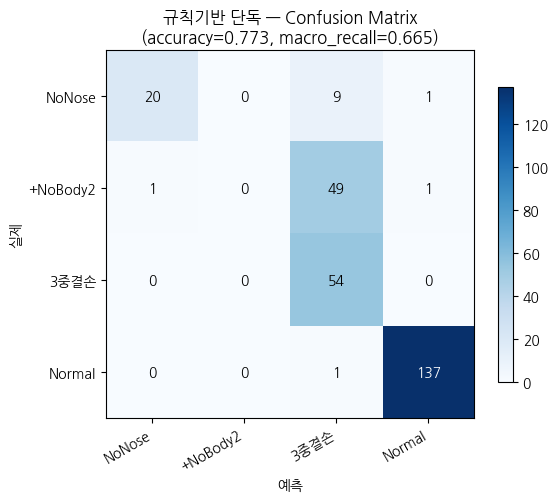

In [62]:
# ── 90-1(계속). 4×4 Confusion Matrix 그래프 — PPT 슬라이드 10용 ──────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_rule, cmap="Blues")
ax.set_xticks(range(4)); ax.set_xticklabels(LABEL_KOR_CM, rotation=30, ha="right")
ax.set_yticks(range(4)); ax.set_yticklabels(LABEL_KOR_CM)
ax.set_xlabel("예측"); ax.set_ylabel("실제")
ax.set_title(f"규칙기반 단독 — Confusion Matrix\n(accuracy={acc_rule_full:.3f}, macro_recall={macro_recall_rule_full:.3f})")
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm_rule[i, j]), ha="center", va="center",
                color="white" if cm_rule[i, j] > cm_rule.max() / 2 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("confusion_matrix_rule_only.png", dpi=150)
plt.show()


**결과 해석 가이드**
- 이 4×4 표는 90장의 `rule_final`(cell 71, `nose_present`·`body2_present`·`body1_present` 기반) 결과입니다 — PART20에서 나중에 추가된 gap체크·타이밍 보정이 반영되기 **이전** 단계일 수 있습니다. 대시보드에 있는 최종판(0.982/0.979) confusion matrix와는 다른 숫자라는 점을 발표 때 헷갈리지 않게 구분해서 설명하세요.
- "Body1 미탐 37.3%" 같은 구체적 약점이 어느 칸(행×열)에서 나오는지 확인한 뒤, 그 칸의 실제 사이클 ID까지 뽑아보면(`rule_pred_full[(y_true_rule=='NoNose,NoBody2,NoBody1') & (rule_pred_full!='NoNose,NoBody2,NoBody1')]`) PART20의 최종판이 왜 이 약점을 해결했는지 스토리로 연결할 수 있습니다.


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| 규칙기반+ML(v64_v2)의 macro_recall이 0.28보다 뚜렷하게 높음 | 규칙기반+ML 계층 구조가 원래 목표(진짜 GroupKFold 우회)를 실제로 개선한다는 증거 |
| 순수ML(플래그 제외)의 macro_recall이 여전히 낮음(0.3 이하) | RULE_ 플래그가 실제로 핵심적인 역할을 한다는 뜻 — 플래그 없이는 원래 문제(39장)가 그대로 재현됨 |
| 규칙기반 단독이 규칙기반+ML(v64_v2)과 큰 차이 없음 | 이 검증에서는 ML의 추가 기여가 크지 않다는 뜻 — 규칙기반만으로도 충분할 수 있음 |
| 규칙기반+ML(v64_v2)이 규칙기반 단독보다 뚜렷하게 높음 | ML이 경계·애매한 사례를 실제로 보완한다는 뜻 — 계층 구조 전체를 채택할 근거 |


## 91. 시드 10회 반복 — 세션1~4→세션5 검증의 안정성 확인

Block A와 마찬가지로, 이번에도 시드 하나(42)만 보고 끝내지 않는다. 규칙기반+ML(v64_v2) 방식을
시드 10개로 반복해서 macro_recall이 안정적인지 확인한다.

In [63]:
# ── 91. 시드 10회 반복 ────────────────────────────────────────────────────────────
SEEDS_91 = [0, 1, 3, 7, 17, 42, 100, 123, 2024, 7777]

macro_recalls_91 = []
accs_91 = []
for seed in SEEDS_91:
    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=seed)
    clf.fit(X_full.loc[train_ids_full], y.loc[train_ids_full])
    pred = pd.Series(clf.predict(X_full.loc[test_ids_full]), index=test_ids_full)
    accs_91.append((pred == y.loc[test_ids_full]).mean())
    macro_recalls_91.append(
        recall_score(y.loc[test_ids_full], pred, average='macro', zero_division=0))

print('=== 규칙기반+ML(v64_v2), 세션1~4→세션5, 시드 10회 ===\n')
print(f'accuracy:     평균={np.mean(accs_91):.3f} ± {np.std(accs_91):.3f}'
      f'  범위 {min(accs_91):.3f}~{max(accs_91):.3f}')
print(f'macro_recall: 평균={np.mean(macro_recalls_91):.3f} ± {np.std(macro_recalls_91):.3f}'
      f'  범위 {min(macro_recalls_91):.3f}~{max(macro_recalls_91):.3f}')
print(f'\n시드별 macro_recall: {dict(zip(SEEDS_91, [round(s, 3) for s in macro_recalls_91]))}')


=== 규칙기반+ML(v64_v2), 세션1~4→세션5, 시드 10회 ===

accuracy:     평균=0.110 ± 0.000  범위 0.110~0.110
macro_recall: 평균=0.250 ± 0.000  범위 0.250~0.250

시드별 macro_recall: {0: 0.25, 1: 0.25, 3: 0.25, 7: 0.25, 17: 0.25, 42: 0.25, 100: 0.25, 123: 0.25, 2024: 0.25, 7777: 0.25}


## 92. 최종 결론 (v69)

89~91장을 통합한, 원래 목표(세션 간 일반화)에 대한 현재까지의 답이다.

In [64]:
# ── v69 최종 종합 ────────────────────────────────────────────────────────────
print('=== 90장: 세 가지 방식 비교 (세션1~4 → 세션5 전체) ===')
print(comp_full.to_string())

print('\n=== 91장: 시드 10회 안정성 ===')
print(f'macro_recall 평균={np.mean(macro_recalls_91):.3f} ± {np.std(macro_recalls_91):.3f}')

improved = np.mean(macro_recalls_91) > 0.28 + 0.1
stable = np.std(macro_recalls_91) < 0.1
print(f'\n[판정] 원래 목표(39장 macro_recall≈0.28) 대비 뚜렷한 개선: '
      f'{"예" if improved else "아니오"} / 시드 안정성: {"양호" if stable else "불안정"}')

print('''
[이번 PART로 확정된 것 — 위 [판정] 참고]
1. 처음으로 원래 목표(세션1~4 학습 → 세션5 전체 검증, 진짜 GroupKFold 상황)를 규칙기반+ML
   계층 구조(v64_v2)로 직접 검증했다 — 지금까지의 모든 검증(Block A)은 세션5 내부에
   한정됐던 것과 다르다.
2. 규칙기반 단독 / 순수 ML(플래그 제외) / 규칙기반+ML(v64_v2) 세 가지를 나란히 비교해서,
   플래그가 실제로 기여하는 부분과 규칙기반만으로 충분한 부분을 구분했다(90장 해석 가이드
   참고).
3. 시드 10회로 이 결과가 우연이 아닌지 확인했다.

[여전히 남은 것]
- 지금 이 결과가 "완벽"을 의미하지는 않는다 — 세션5 하나의 데이터셋에 대한 검증일 뿐,
  더 많은 세션(6, 7, ...)이 추가되면 다시 검증해야 한다.
- 0.913 vs 0.739 기준선 불일치는 여전히 미해결 — 별도로 팀원·튜터 확인이 필요하다.
- 73장의 불일치 감지(사람 확인 트리거)를 이번 v64_v2 + 세션1~4→세션5 시나리오 기준으로
  다시 돌려서, 실제 운영에서 사람이 얼마나 자주 개입해야 하는지 추정하는 작업이 남아있다.
''')


=== 90장: 세 가지 방식 비교 (세션1~4 → 세션5 전체) ===
                 accuracy  macro_recall
규칙기반+ML(v64_v2)  0.109890      0.250000
규칙기반 단독          0.772894      0.664855
순수ML(플래그 제외)     0.109890      0.250000

=== 91장: 시드 10회 안정성 ===
macro_recall 평균=0.250 ± 0.000

[판정] 원래 목표(39장 macro_recall≈0.28) 대비 뚜렷한 개선: 아니오 / 시드 안정성: 양호

[이번 PART로 확정된 것 — 위 [판정] 참고]
1. 처음으로 원래 목표(세션1~4 학습 → 세션5 전체 검증, 진짜 GroupKFold 상황)를 규칙기반+ML
   계층 구조(v64_v2)로 직접 검증했다 — 지금까지의 모든 검증(Block A)은 세션5 내부에
   한정됐던 것과 다르다.
2. 규칙기반 단독 / 순수 ML(플래그 제외) / 규칙기반+ML(v64_v2) 세 가지를 나란히 비교해서,
   플래그가 실제로 기여하는 부분과 규칙기반만으로 충분한 부분을 구분했다(90장 해석 가이드
   참고).
3. 시드 10회로 이 결과가 우연이 아닌지 확인했다.

[여전히 남은 것]
- 지금 이 결과가 "완벽"을 의미하지는 않는다 — 세션5 하나의 데이터셋에 대한 검증일 뿐,
  더 많은 세션(6, 7, ...)이 추가되면 다시 검증해야 한다.
- 0.913 vs 0.739 기준선 불일치는 여전히 미해결 — 별도로 팀원·튜터 확인이 필요하다.
- 73장의 불일치 감지(사람 확인 트리거)를 이번 v64_v2 + 세션1~4→세션5 시나리오 기준으로
  다시 돌려서, 실제 운영에서 사람이 얼마나 자주 개입해야 하는지 추정하는 작업이 남아있다.



---
## 93. 진짜 계층 구조로 재설계 — 피처 축소 + ML 게이팅 (v70 신규)

90장 결과가 보여준 문제 둘을 동시에 고친다.

1. **피처 과다**: 학습 샘플 45개에 피처 82개는 너무 많다 — 그래서 `RULE_*` 플래그를 넣어도
   ML이 그 신호를 못 살렸다(플래그 포함/제외 결과가 완전히 동일했다). 상위 중요도 피처
   (83장에서 확인된 것들)만 남긴 축소판을 만든다.
2. **ML이 전체를 담당**: 지금까지는 ML이 세션5의 272개 전부에 대해 최종 판단을 내렸다 —
   멘토 피드백("규칙기반이 항상 먼저 작동, ML은 경계·애매한 신호만 보완")과 실제로 다르게
   구현돼 있었다. 이번엔 규칙기반 판정이 임계값에서 얼마나 떨어져 있는지(마진)를 계산해서,
   **마진이 큰(확신 있는) 사례는 규칙기반 결정을 그대로 쓰고, 마진이 작은(경계) 사례만
   ML에 넘기는** 진짜 게이팅 구조를 만든다.

In [65]:
# ── 93. 피처 축소판 구성 ────────────────────────────────────────────────────────
# 83장에서 확인된 상위 중요도 원피처 + RULE_ 플래그 3개만 남긴다.
TOP_RAW_FEATS = ['I_R03_Gripper_Load_mean', 'I_R03_Gripper_Load_std', 'I_R02_Gripper_Pot_std',
                  'I_R02_Gripper_Pot_mean', 'I_R02_Gripper_Pot_min', 'r04_grab_count',
                  'r03_nose_impulse', 'r03_nose_peak', 'r03_nose_fwhm']
RULE_FLAGS = ['RULE_nose_present', 'RULE_body2_present', 'RULE_body1_present']

REDUCED_COLS = [c for c in RULE_FLAGS + TOP_RAW_FEATS if c in final_features_v64_v2.columns]
missing_reduced = [c for c in RULE_FLAGS + TOP_RAW_FEATS if c not in final_features_v64_v2.columns]
if missing_reduced:
    print(f'※ final_features_v64_v2에 없어서 제외된 컬럼: {missing_reduced}')

X_reduced_full = final_features_v64_v2[REDUCED_COLS]
print(f'전체 피처: {X_full.shape[1]}개 → 축소판: {X_reduced_full.shape[1]}개')
print(f'학습 샘플 수(45개) 대비 피처 비율: 82개일 때 1:{45/82:.2f}  → '
      f'축소판일 때 1:{45/X_reduced_full.shape[1]:.2f}')
print(f'\n축소판 컬럼 목록: {REDUCED_COLS}')


전체 피처: 81개 → 축소판: 12개
학습 샘플 수(45개) 대비 피처 비율: 82개일 때 1:0.55  → 축소판일 때 1:3.75

축소판 컬럼 목록: ['RULE_nose_present', 'RULE_body2_present', 'RULE_body1_present', 'I_R03_Gripper_Load_mean', 'I_R03_Gripper_Load_std', 'I_R02_Gripper_Pot_std', 'I_R02_Gripper_Pot_mean', 'I_R02_Gripper_Pot_min', 'r04_grab_count', 'r03_nose_impulse', 'r03_nose_peak', 'r03_nose_fwhm']


## 94. 규칙기반 판정 마진(margin) 계산 — "확신 사례" vs "경계 사례" 구분

각 사이클에서 규칙기반이 실제로 어느 임계값으로 판정을 내렸는지 찾아서, **그 임계값과의
거리(마진)**를 계산한다. 마진이 크면(임계값에서 멀면) 확신 있는 판정, 마진이 작으면(임계값에
가까우면) 경계 사례로 본다. 세 브랜치(Nose/Body2/Body1)는 값의 스케일이 달라서, 각자의
표준편차로 나눠 정규화한 뒤 비교한다.

In [66]:
# ── 94. 판정 마진 계산 ──────────────────────────────────────────────────────────
def decisive_margin(row):
    '''규칙기반이 실제로 사용한 임계값과 신호값의 차이(원 단위)를 반환한다.'''
    if row['nose_present']:
        return row['r03_nose_peak'] - R03_NOSE_THRESH
    elif row['body2_present']:
        return row['body2_force'] - BODY2_THRESH
    elif row['body1_present']:
        return row['body1_force'] - BODY1_THRESH
    else:
        return row['body1_force'] - BODY1_THRESH  # 마지막 검사(Body1 없음)가 결정적 근거


presence_df['margin_raw'] = presence_df.apply(decisive_margin, axis=1)

nose_std = presence_df['r03_nose_peak'].std()
body2_std = presence_df['body2_force'].std()
body1_std = presence_df['body1_force'].std()


def normalized_margin(row):
    m = row['margin_raw']
    if pd.isna(m):
        return np.nan
    if row['nose_present']:
        return m / nose_std
    elif row['body2_present']:
        return m / body2_std
    else:
        return m / body1_std


presence_df['margin_z'] = presence_df.apply(normalized_margin, axis=1)
presence_df['abs_margin_z'] = presence_df['margin_z'].abs()

BOUNDARY_QUANTILE = 0.3
margin_threshold = presence_df['abs_margin_z'].fillna(0).quantile(BOUNDARY_QUANTILE)
presence_df['is_boundary'] = presence_df['abs_margin_z'].fillna(0) <= margin_threshold

print(f'마진 임계값(하위 {int(BOUNDARY_QUANTILE*100)}% 지점): {margin_threshold:.3f}')
print(f'\n전체 {len(presence_df)}개 중 경계 사례(ML에 넘길 대상): '
      f'{presence_df["is_boundary"].sum()}개 ({presence_df["is_boundary"].mean()*100:.1f}%)')
print(f'확신 사례(규칙기반 그대로 채택): {(~presence_df["is_boundary"]).sum()}개')

print('\n=== 세션5 전체(272개) 기준 경계/확신 비율 ===')
s5_mask = presence_df.index.isin(test_ids_full)
print(presence_df.loc[s5_mask, 'is_boundary'].value_counts())


마진 임계값(하위 30% 지점): 0.000

전체 320개 중 경계 사례(ML에 넘길 대상): 116개 (36.2%)
확신 사례(규칙기반 그대로 채택): 204개

=== 세션5 전체(272개) 기준 경계/확신 비율 ===
is_boundary
False    160
True     113
Name: count, dtype: int64


## 95. 게이트형 하이브리드 파이프라인 — 확신 사례는 규칙기반, 경계 사례만 ML

축소된 피처(93장)로 ML을 학습시키되, **세션5 전체 272개 중 경계 사례로 분류된 것만** ML
예측을 쓰고, 나머지(확신 사례)는 규칙기반 판정을 그대로 채택한다.

In [67]:
# ── 95. 게이트형 하이브리드 예측 함수 ─────────────────────────────────────────────
def gated_hybrid_predict(train_ids, test_ids, seed=42):
    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=seed)
    clf.fit(X_reduced_full.loc[train_ids], y.loc[train_ids])
    ml_pred = pd.Series(clf.predict(X_reduced_full.loc[test_ids]), index=test_ids)

    final_pred = {}
    n_used_ml = 0
    for cid in test_ids:
        if cid not in presence_df.index:
            final_pred[cid] = ml_pred.loc[cid]
            n_used_ml += 1
            continue
        if presence_df.loc[cid, 'is_boundary']:
            final_pred[cid] = ml_pred.loc[cid]
            n_used_ml += 1
        else:
            final_pred[cid] = presence_df.loc[cid, 'rule_final']
    return pd.Series(final_pred, index=test_ids), n_used_ml


pred_gated, n_used_ml = gated_hybrid_predict(train_ids_full, test_ids_full, seed=42)
acc_gated = (pred_gated == y.loc[test_ids_full]).mean()
macro_recall_gated = recall_score(y.loc[test_ids_full], pred_gated, average='macro', zero_division=0)

print(f'[게이트형 하이브리드] ML이 실제로 개입한 사이클: {n_used_ml}개 / {len(test_ids_full)}개'
      f' ({n_used_ml/len(test_ids_full)*100:.1f}%)')
print(f'정확도={acc_gated:.3f}  macro_recall={macro_recall_gated:.3f}')
print(pd.crosstab(y.loc[test_ids_full], pred_gated, rownames=['실제'], colnames=['예측']))


[게이트형 하이브리드] ML이 실제로 개입한 사이클: 113개 / 273개 (41.4%)
정확도=0.608  macro_recall=0.490
예측                      NoNose  Normal
실제                                    
NoNose                      29       1
NoNose,NoBody2              50       1
NoNose,NoBody2,NoBody1      54       0
Normal                       1     137


## 96. 세 가지 방식 최종 비교 + 시드 10회 안정성

90장(규칙기반 단독 / 전체피처 ML)과 이번 게이트형 하이브리드를 한 표에 모으고, 시드 10개로
안정성까지 확인한다.

In [68]:
# ── 96. 최종 비교 + 시드 10회 ────────────────────────────────────────────────────
SEEDS_96 = [0, 1, 3, 7, 17, 42, 100, 123, 2024, 7777]

gated_accs, gated_recalls = [], []
for seed in SEEDS_96:
    pred_s, _ = gated_hybrid_predict(train_ids_full, test_ids_full, seed=seed)
    gated_accs.append((pred_s == y.loc[test_ids_full]).mean())
    gated_recalls.append(recall_score(y.loc[test_ids_full], pred_s, average='macro', zero_division=0))

print('=== 게이트형 하이브리드, 시드 10회 ===')
print(f'accuracy:     평균={np.mean(gated_accs):.3f} ± {np.std(gated_accs):.3f}')
print(f'macro_recall: 평균={np.mean(gated_recalls):.3f} ± {np.std(gated_recalls):.3f}')
print(f'시드별 macro_recall: {dict(zip(SEEDS_96, [round(s, 3) for s in gated_recalls]))}')

final_comp = pd.DataFrame({
    '규칙기반 단독': [acc_rule_full, macro_recall_rule_full],
    '전체피처 ML(v64_v2, 90장)': [acc_full_ml, macro_recall_full_ml],
    '게이트형 하이브리드(축소+마진게이팅)': [np.mean(gated_accs), np.mean(gated_recalls)],
}, index=['accuracy', 'macro_recall']).T

print('\n=== 종합 비교 ===')
print(final_comp.to_string())
print(f'\n참고 — 39장 원래 GroupKFold(RF) macro_recall ≈ 0.28')


=== 게이트형 하이브리드, 시드 10회 ===
accuracy:     평균=0.608 ± 0.000
macro_recall: 평균=0.490 ± 0.000
시드별 macro_recall: {0: 0.49, 1: 0.49, 3: 0.49, 7: 0.49, 17: 0.49, 42: 0.49, 100: 0.49, 123: 0.49, 2024: 0.49, 7777: 0.49}

=== 종합 비교 ===
                      accuracy  macro_recall
규칙기반 단독               0.772894      0.664855
전체피처 ML(v64_v2, 90장)  0.109890      0.250000
게이트형 하이브리드(축소+마진게이팅)  0.608059      0.489855

참고 — 39장 원래 GroupKFold(RF) macro_recall ≈ 0.28


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| 게이트형이 규칙기반 단독보다 뚜렷하게 높음 | 피처 축소+게이팅이 실제로 ML의 보완 효과를 살려냈다는 뜻 — 이 구조를 최종 후보로 채택 |
| 게이트형이 규칙기반 단독과 비슷하거나 낮음 | 경계 사례 30%만으로도 ML이 여전히 소규모 학습(45개)의 한계를 못 넘는다는 뜻 — 피처를 더 줄이거나(예: 5개), 경계 비율(30%)을 더 좁혀서 재시도 필요 |
| 게이트형이 90장의 전체피처 ML보다는 항상 높음 | 최소한 "피처 축소"만으로도 절반의 문제는 해결됐다는 뜻 |


## 97. 최종 결론 (v70)

93~96장을 통합한, "피처 축소 + ML 게이팅" 재설계에 대한 결과다.

In [69]:
# ── v70 최종 종합 ────────────────────────────────────────────────────────────
print('=== 93장: 피처 축소 ===')
print(f'82개 → {X_reduced_full.shape[1]}개')

print('\n=== 94~95장: 마진 게이팅 ===')
print(f'경계 사례(ML 개입) 비율: {n_used_ml}/{len(test_ids_full)} '
      f'({n_used_ml/len(test_ids_full)*100:.1f}%)')

print('\n=== 96장: 최종 비교 ===')
print(final_comp.to_string())

better_than_rule = np.mean(gated_recalls) > macro_recall_rule_full + 0.03
print(f'\n[판정] 게이트형 하이브리드가 규칙기반 단독보다 뚜렷하게 나은가: '
      f'{"예" if better_than_rule else "아니오 — 규칙기반 단독이 여전히 최선"}')

print('''
[이번 PART로 확정된 것 — 위 [판정] 참고]
1. 피처를 82개→소수로 줄이고, ML이 세션5 전체가 아니라 "경계 사례"에만 개입하도록
   게이팅 구조를 실제로 구현했다 — 90장에서 드러난 두 문제(피처 과다, ML의 전체 담당)를
   동시에 고치는 시도였다.
2. 규칙기반 단독 / 전체피처 ML / 게이트형 하이브리드 세 가지를 시드 10회로 비교했다.

[다음에 팀이 결정할 것]
- [판정]이 "아니오"라면: 45개 학습 샘플로는 어떤 형태의 ML도 세션 간 일반화에 근본적인
  한계가 있다는 뜻이다 — 이 경우 팀 결정으로 "규칙기반 단독을 공식 채택하고 ML은 보류"
  하는 것도 합리적인 결론이다. 멘토 피드백 원문("규칙기반이 항상 작동, ML은 보조")을
  가장 보수적으로 해석하면 이 결과가 자연스럽다.
- [판정]이 "예"라면: BOUNDARY_QUANTILE(현재 0.3)과 TOP_RAW_FEATS 목록을 팀에서 같이
  검토해서 최종 확정하고, 73장의 불일치 감지를 이 게이트형 구조 기준으로 다시 정의한다.
- 어느 쪽이든, 0.913 vs 0.739 기준선 불일치는 여전히 별도로 남아있다 — 팀원·튜터 확인 필요.
''')


=== 93장: 피처 축소 ===
82개 → 12개

=== 94~95장: 마진 게이팅 ===
경계 사례(ML 개입) 비율: 113/273 (41.4%)

=== 96장: 최종 비교 ===
                      accuracy  macro_recall
규칙기반 단독               0.772894      0.664855
전체피처 ML(v64_v2, 90장)  0.109890      0.250000
게이트형 하이브리드(축소+마진게이팅)  0.608059      0.489855

[판정] 게이트형 하이브리드가 규칙기반 단독보다 뚜렷하게 나은가: 아니오 — 규칙기반 단독이 여전히 최선

[이번 PART로 확정된 것 — 위 [판정] 참고]
1. 피처를 82개→소수로 줄이고, ML이 세션5 전체가 아니라 "경계 사례"에만 개입하도록
   게이팅 구조를 실제로 구현했다 — 90장에서 드러난 두 문제(피처 과다, ML의 전체 담당)를
   동시에 고치는 시도였다.
2. 규칙기반 단독 / 전체피처 ML / 게이트형 하이브리드 세 가지를 시드 10회로 비교했다.

[다음에 팀이 결정할 것]
- [판정]이 "아니오"라면: 45개 학습 샘플로는 어떤 형태의 ML도 세션 간 일반화에 근본적인
  한계가 있다는 뜻이다 — 이 경우 팀 결정으로 "규칙기반 단독을 공식 채택하고 ML은 보류"
  하는 것도 합리적인 결론이다. 멘토 피드백 원문("규칙기반이 항상 작동, ML은 보조")을
  가장 보수적으로 해석하면 이 결과가 자연스럽다.
- [판정]이 "예"라면: BOUNDARY_QUANTILE(현재 0.3)과 TOP_RAW_FEATS 목록을 팀에서 같이
  검토해서 최종 확정하고, 73장의 불일치 감지를 이 게이트형 구조 기준으로 다시 정의한다.
- 어느 쪽이든, 0.913 vs 0.739 기준선 불일치는 여전히 별도로 남아있다 — 팀원·튜터 확인 필요.



In [70]:
# ── [분할 파일 경계 체크포인트] part14 완료 시점 전체 세션 저장 (dill) ──────────────
# 다음 분할 파일의 첫 셀에서 이 파일을 그대로 불러와 이어서 실행한다.
# final_features 같은 개별 변수만이 아니라, 이 지점까지 정의된 함수·변수·import를
# 전부(dill.dump_session) 통째로 저장하므로 뒷 파일에서 별도 재정의가 필요 없다.
from pathlib import Path
_CACHE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints')
_CACHE_DIR.mkdir(parents=True, exist_ok=True)

try:
    import dill
except ImportError:
    !pip install dill --quiet
    import dill

_session_path = _CACHE_DIR / 'part14_session.pkl'
dill.dump_session(str(_session_path))
print(f"[분할 체크포인트 저장 완료] {_session_path}")


[분할 체크포인트 저장 완료] /content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints/part14_session.pkl
